In [1]:
# pip install yfinance pandas matplotlib PyWavelets numpy statsmodels

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import pywt                         
import numpy as np
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
import matplotlib.dates as mdates

# Esto es necesario para asegurar que las fechas se manejen correctamente tras la descarga
import warnings
warnings.filterwarnings('ignore')

# Colores fijos por ticker (según leyenda del proyecto)
color_map = {
    'YPF': 'tab:blue',
    'GGAL': 'tab:orange',
    'BMA': 'tab:green',
    'SUPV': 'tab:red',
    'LOMA': 'tab:purple',
    'CEPU': 'tab:brown',
    'PAM': 'tab:pink',
    'TGS': 'tab:gray',
}


In [3]:
tickers = ['YPF', 'GGAL', 'BMA', 'SUPV', 'LOMA', 'CEPU', 'PAM', 'TGS']

start = '2008-01-01'
end = '2025-01-01'

raw = yf.download(
    tickers,
    start=start,
    end=end,
    auto_adjust=False
)

data = raw['Close']
aperturas = raw['Open']
volumen = raw['Volume']

[*********************100%***********************]  8 of 8 completed


In [4]:
gaps_overnight = {}

for ticker in tickers:
    # Aislamos las series de apertura y cierre para cada ticker
    open_ticker = aperturas[ticker].copy()
    close_ticker = data[ticker].copy()

    # Quitamos la timezone del índice de fechas
    open_ticker.index = open_ticker.index.tz_localize(None)
    close_ticker.index = close_ticker.index.tz_localize(None)

    # Variación % entre el cierre del día anterior y la apertura de hoy
    gap_overnight = open_ticker / close_ticker.shift(1) - 1
    gap_overnight.name = ticker

    gaps_overnight[ticker] = gap_overnight

# Armamos un único DataFrame con el gap overnight de todos los tickers
# (cada columna es un ticker, alineados por fecha)
gaps_overnight_df = pd.DataFrame(gaps_overnight)

print(f'{gaps_overnight_df.shape[0]} filas x {gaps_overnight_df.shape[1]} columnas')

print(gaps_overnight_df.head())

4279 filas x 8 columnas
                 YPF      GGAL       BMA  SUPV  LOMA  CEPU  PAM       TGS
Date                                                                     
2008-01-02       NaN       NaN       NaN   NaN   NaN   NaN  NaN       NaN
2008-01-03 -0.000457  0.000000 -0.004583   NaN   NaN   NaN  NaN  0.005034
2008-01-04  0.005944 -0.004054 -0.018803   NaN   NaN   NaN  NaN  0.017544
2008-01-07 -0.023655  0.008403  0.001273   NaN   NaN   NaN  NaN  0.022807
2008-01-08  0.008813  0.004190  0.016316   NaN   NaN   NaN  NaN  0.017241


In [5]:
umbral = 0.01  # 1%

resultados_gaps = {}
dfs_gaps = {}  # por si después querés inspeccionar el detalle de cada ticker

for ticker in tickers:
    open_ticker = aperturas[ticker].copy()
    close_ticker = data[ticker].copy()

    open_ticker.index = open_ticker.index.tz_localize(None)
    close_ticker.index = close_ticker.index.tz_localize(None)

    gap_overnight = open_ticker / close_ticker.shift(1) - 1
    gap_overnight.name = 'gap_overnight'

    # Armamos el DataFrame prolijo con open, close_anterior y gap_overnight
    df_gaps = pd.DataFrame({
        'open': open_ticker,
        'close_anterior': close_ticker.shift(1),
        'gap_overnight': gap_overnight
    }).dropna()  # eliminamos la primera fila (NaN por el shift)

    dfs_gaps[ticker] = df_gaps

    total_dias = len(df_gaps)
    gaps_positivos = (df_gaps['gap_overnight'] > 0).sum()
    gaps_negativos = (df_gaps['gap_overnight'] < 0).sum()
    gaps_grandes = (df_gaps['gap_overnight'].abs() >= umbral).sum()
    gaps_grandes_positivos = (df_gaps['gap_overnight'] >= umbral).sum()
    gaps_grandes_negativos = (df_gaps['gap_overnight'] <= -umbral).sum()

    resultados_gaps[ticker] = {
        'total_dias': total_dias,
        'gaps_positivos': gaps_positivos,
        'gaps_negativos': gaps_negativos,
        f'gaps_mayores_{umbral:.0%}': gaps_grandes,
        f'gaps_positivos_mayores_{umbral:.0%}': gaps_grandes_positivos,
        f'gaps_negativos_menores_-{umbral:.0%}': gaps_grandes_negativos,
        'porcentaje_gaps_grandes': gaps_grandes / total_dias
    }

# Tabla resumen: una fila por ticker
resumen_gaps_df = pd.DataFrame(resultados_gaps).T

resumen_gaps_df

,total_dias,gaps_positivos,gaps_negativos,gaps_mayores_1%,gaps_positivos_mayores_1%,gaps_negativos_menores_-1%,porcentaje_gaps_grandes
YPF,4278.0,2201.0,1851.0,1450.0,837.0,613.0,0.338943
GGAL,4278.0,2208.0,1819.0,1535.0,874.0,661.0,0.358813
BMA,4278.0,2205.0,1894.0,1306.0,705.0,601.0,0.305283
SUPV,2168.0,1021.0,901.0,804.0,423.0,381.0,0.370849
LOMA,1801.0,912.0,715.0,510.0,297.0,213.0,0.283176
CEPU,1738.0,866.0,668.0,573.0,328.0,245.0,0.329689
PAM,3831.0,1915.0,1662.0,911.0,510.0,401.0,0.237797
TGS,4278.0,2061.0,1708.0,1648.0,926.0,722.0,0.385227


In [6]:
top_gaps_por_ticker = {}

for ticker in tickers:
    df_gaps = dfs_gaps[ticker]  # el DataFrame que armamos en el bloque anterior

    df_gaps['gap_pct'] = df_gaps['gap_overnight'] * 100

    top5 = df_gaps.sort_values(
        'gap_overnight',
        key=abs,
        ascending=False
    ).head(5)

    top_gaps_por_ticker[ticker] = top5

    print(f'--- Top 5 gaps - {ticker} ---')
    print(top5[['open', 'close_anterior', 'gap_pct']])
    print()

--- Top 5 gaps - YPF ---
                 open  close_anterior    gap_pct
Date                                            
2009-06-15  23.299999       34.130001 -31.731619
2019-08-12  11.500000       16.680000 -31.055157
2023-11-20  13.550000       10.730000  26.281461
2009-03-17  19.910000       17.000000  17.117646
2012-06-15  12.120000       10.450000  15.980862

--- Top 5 gaps - GGAL ---
                 open  close_anterior    gap_pct
Date                                            
2019-08-12  19.309999       38.169998 -49.410531
2008-12-01   1.460000        1.900000 -23.157892
2023-11-20  14.790000       12.500000  18.320000
2015-10-26  25.000000       21.299999  17.370896
2020-03-16   7.720000        9.210000 -16.178070

--- Top 5 gaps - BMA ---
             open  close_anterior    gap_pct
Date                                        
2019-08-12  44.16       76.480003 -42.259417
2008-10-24   6.85        8.800000 -22.159094
2015-10-26  55.00       45.680000  20.402801
2008-12-01 

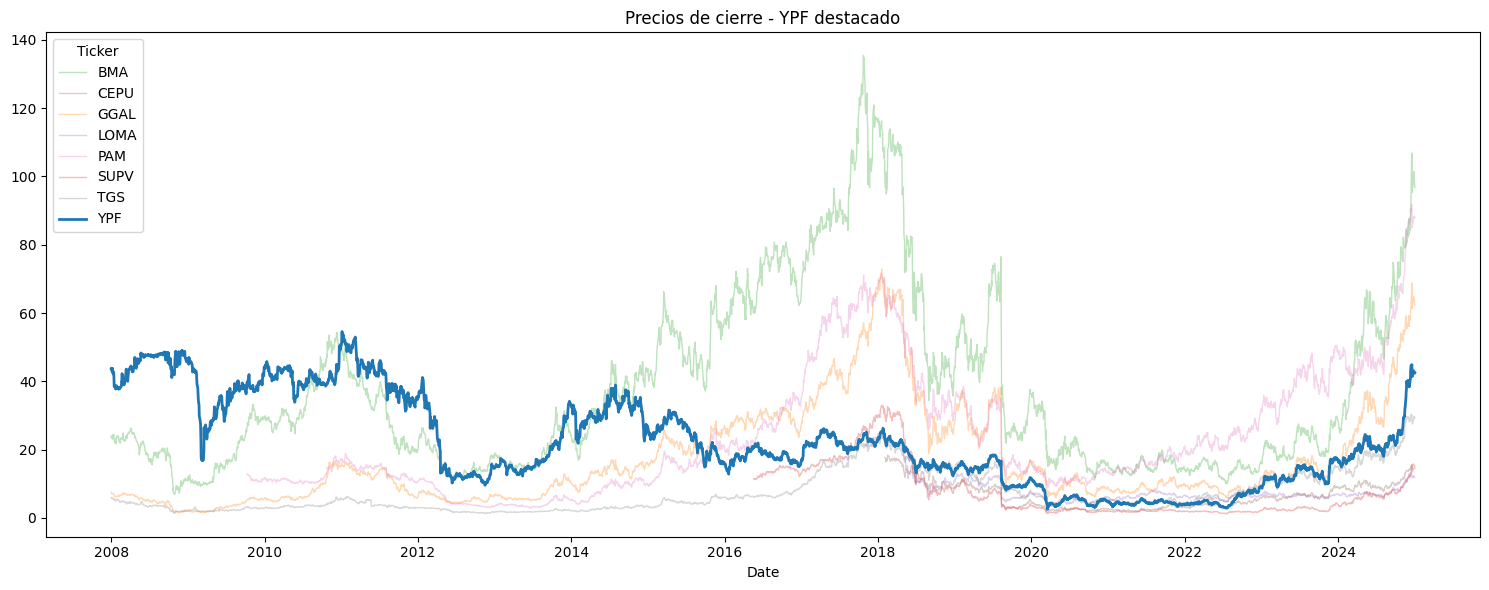

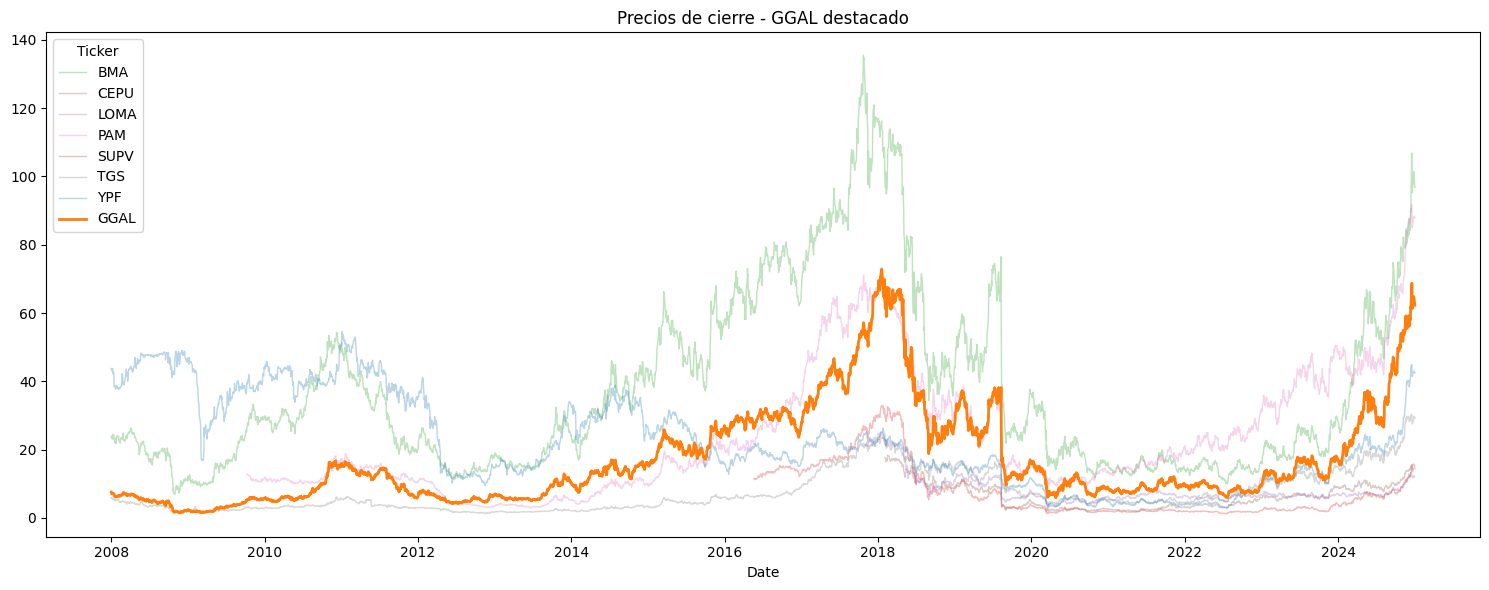

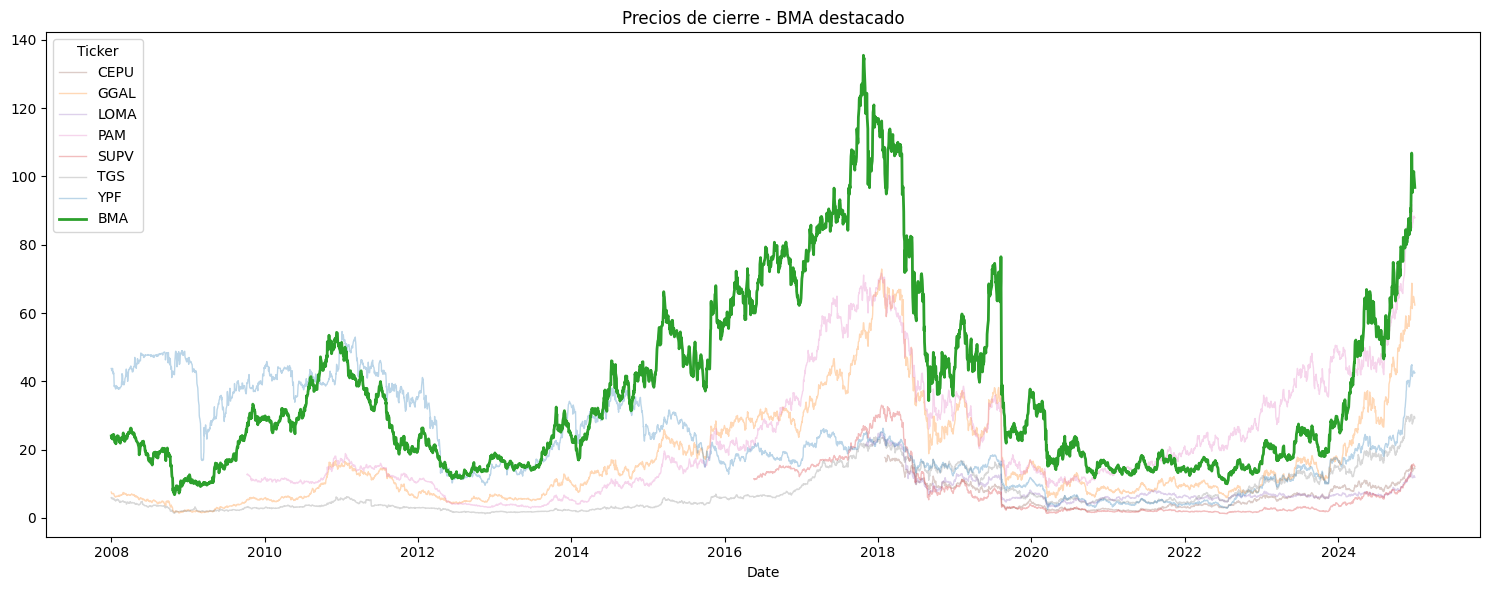

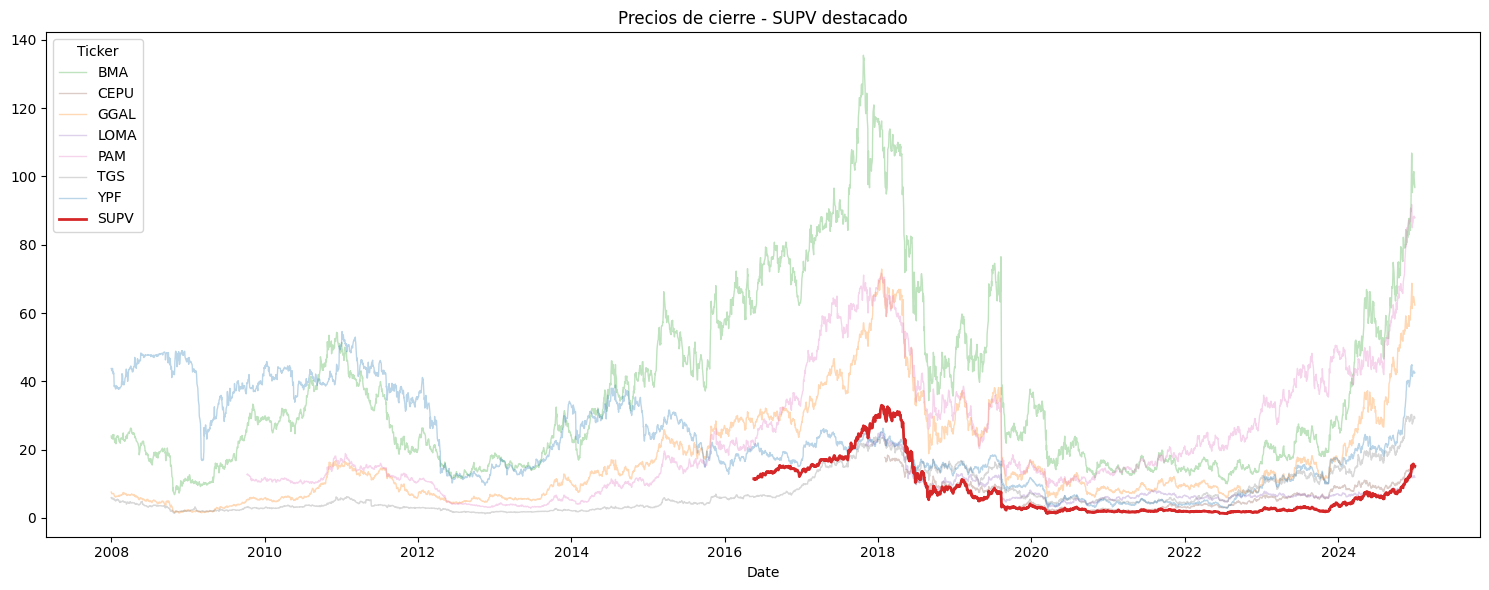

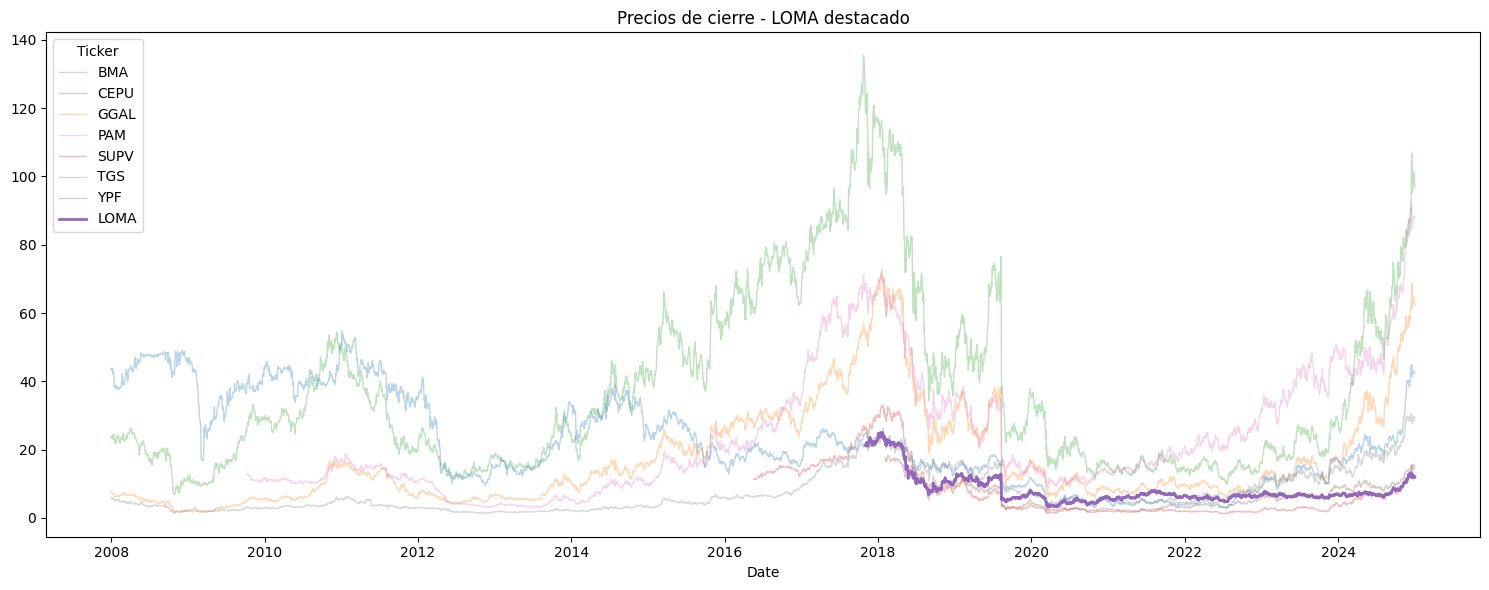

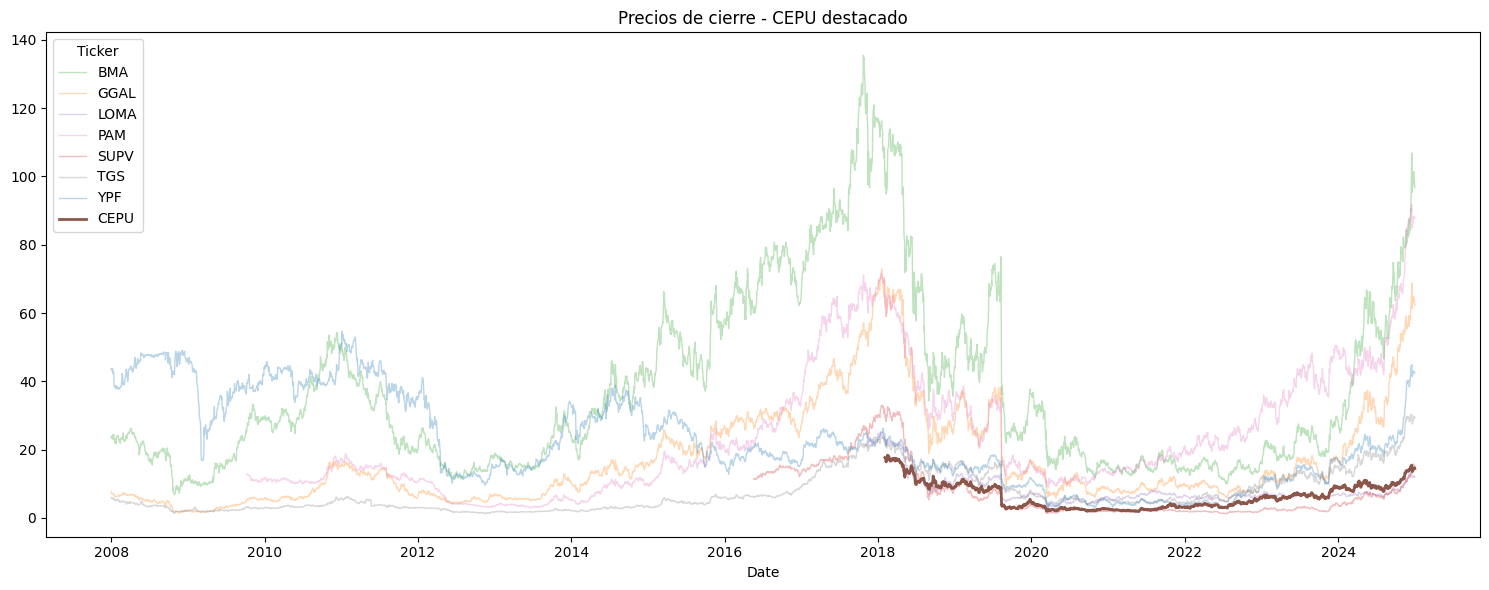

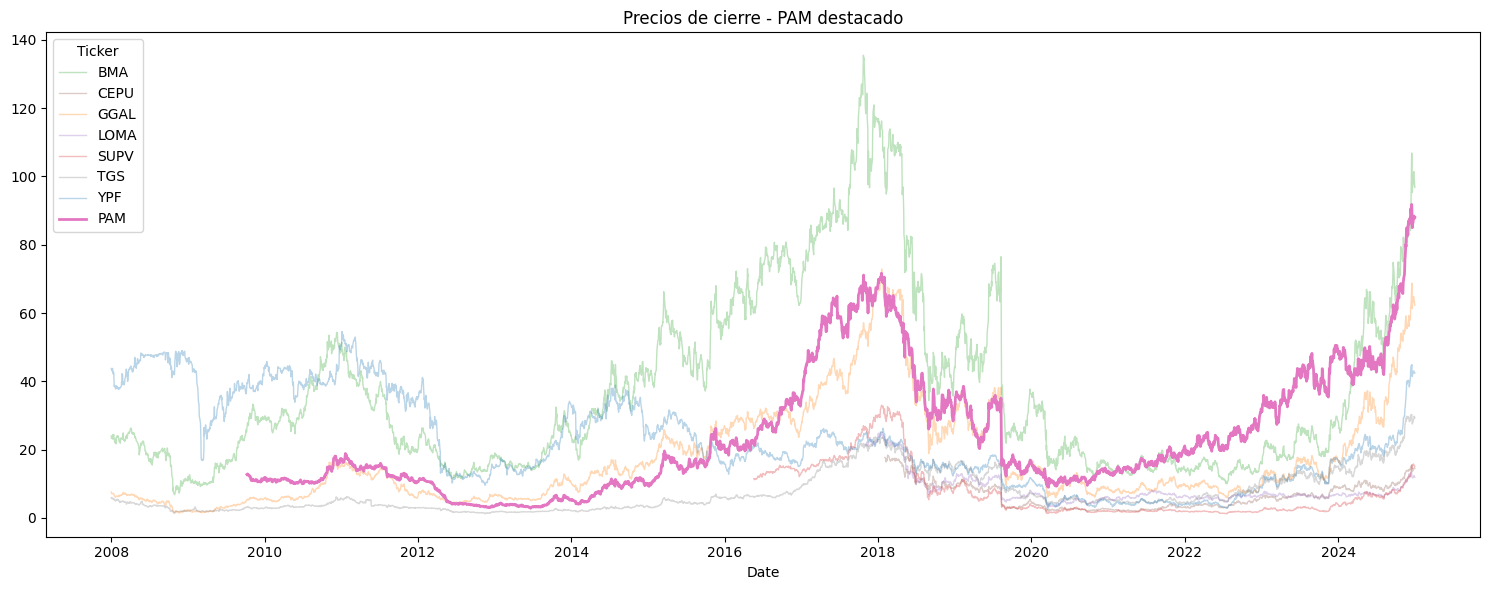

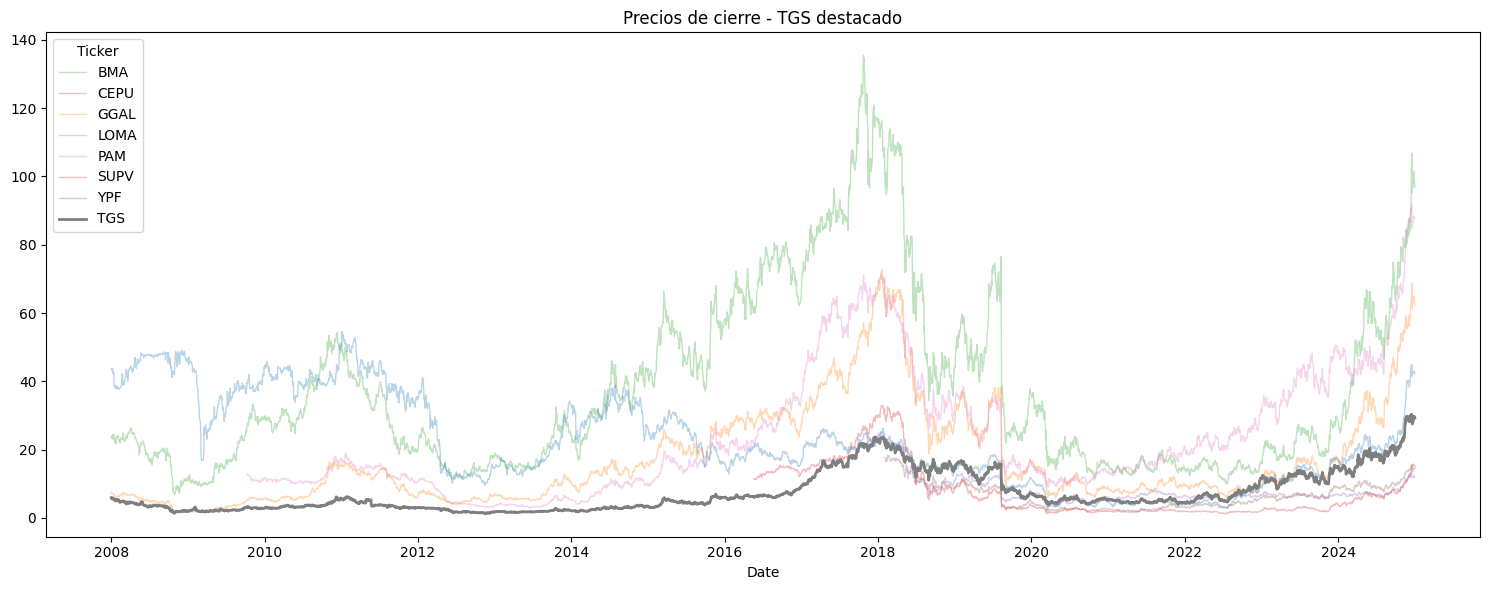

In [7]:
for ticker_destacado in tickers:
    fig, ax = plt.subplots(figsize=(15, 6))

    # Graficamos primero todas las acciones "de fondo" con su color propio y baja opacidad
    for col in data.columns:
        if col != ticker_destacado:
            ax.plot(data.index, data[col], color=color_map[col], alpha=0.3, linewidth=1, label=col)

    # Graficamos el ticker destacado al final (queda por encima) con su color propio
    ax.plot(data.index, data[ticker_destacado], color=color_map[ticker_destacado], alpha=1.0, linewidth=2, label=ticker_destacado)

    ax.set_title(f'Precios de cierre - {ticker_destacado} destacado')
    ax.set_xlabel('Date')
    ax.legend(title='Ticker')
    plt.tight_layout()
    plt.show()


## Filtro de Media Movil (MA30 MA90)

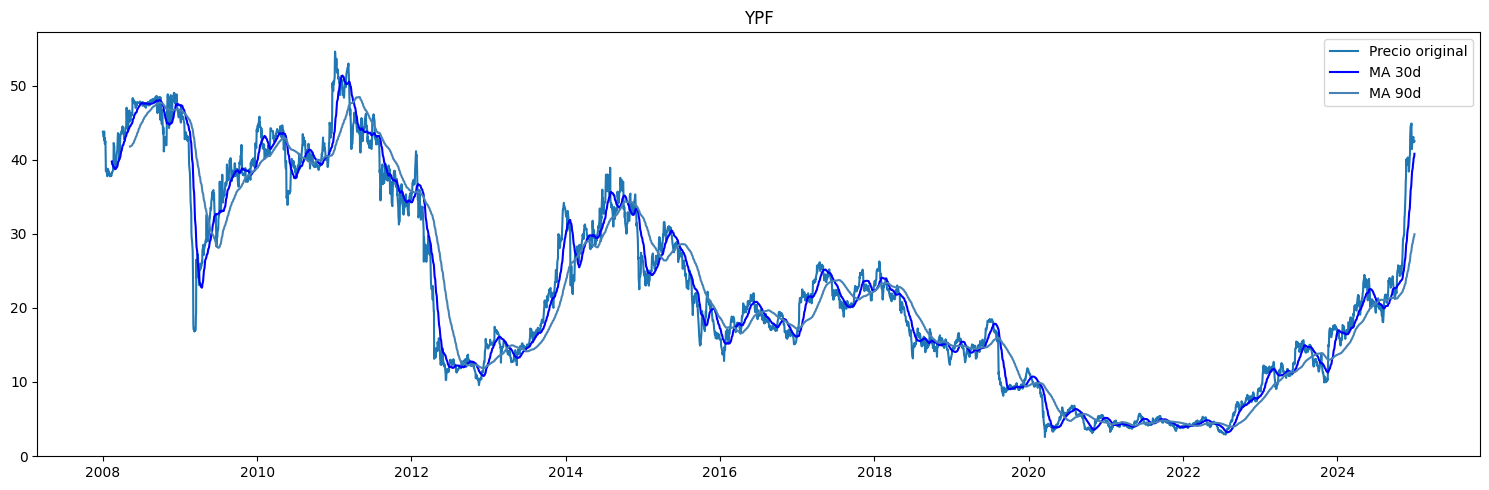

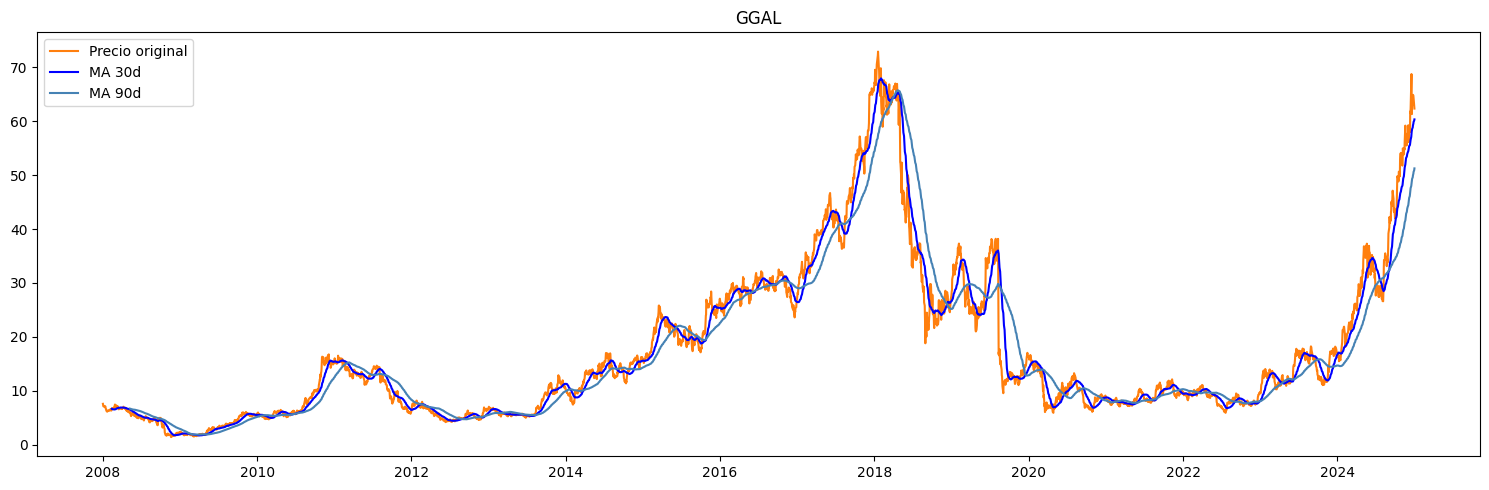

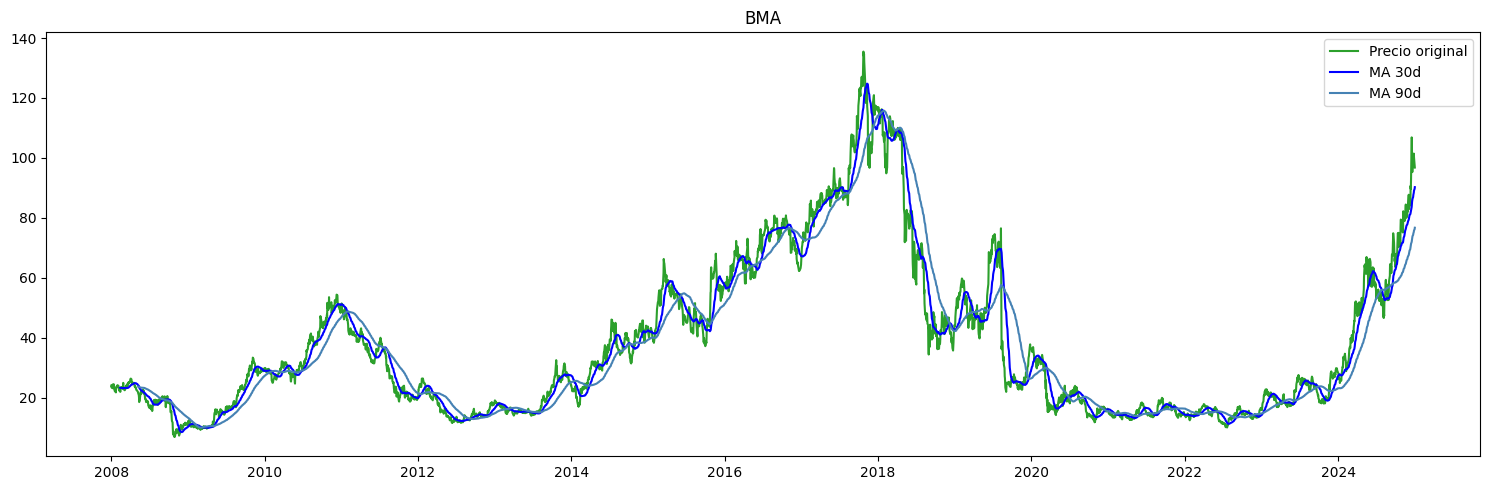

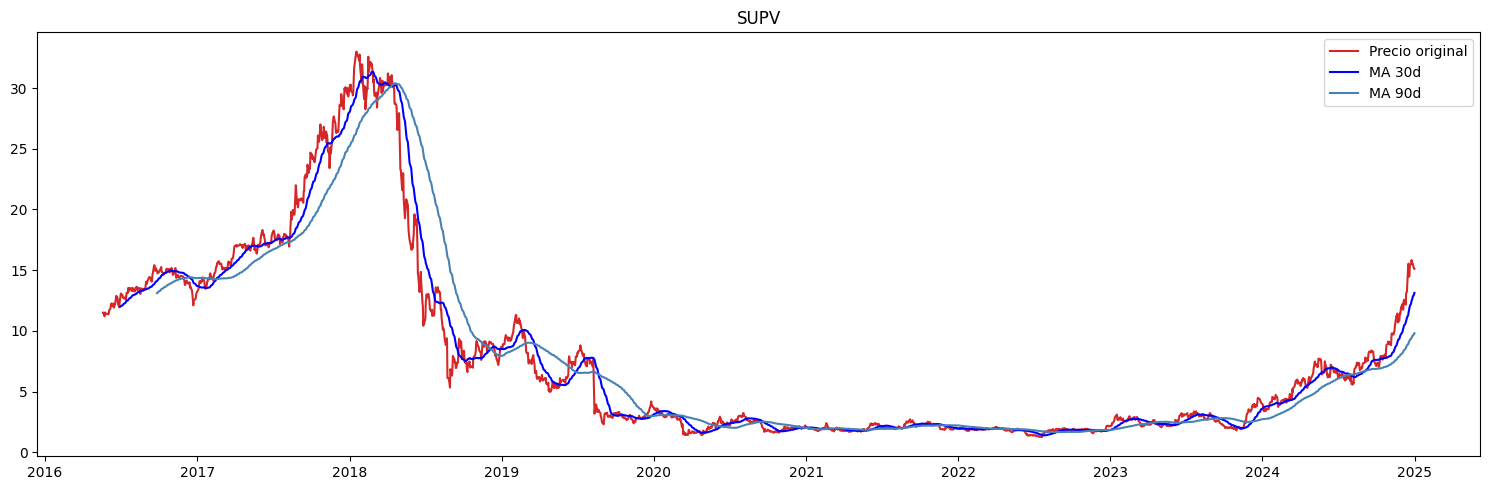

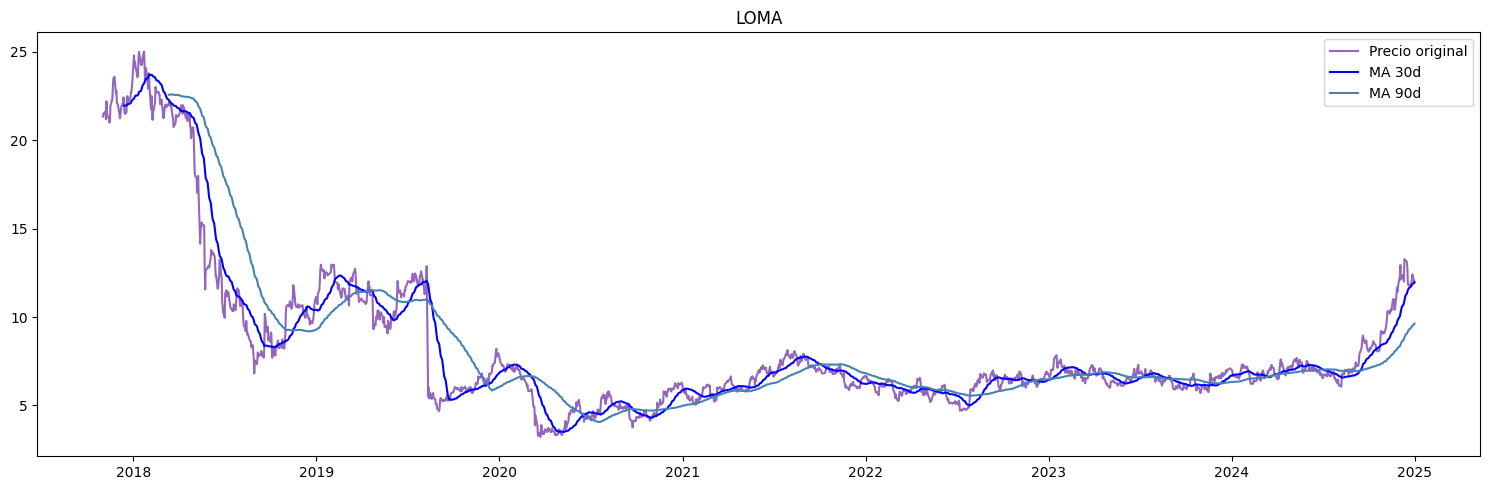

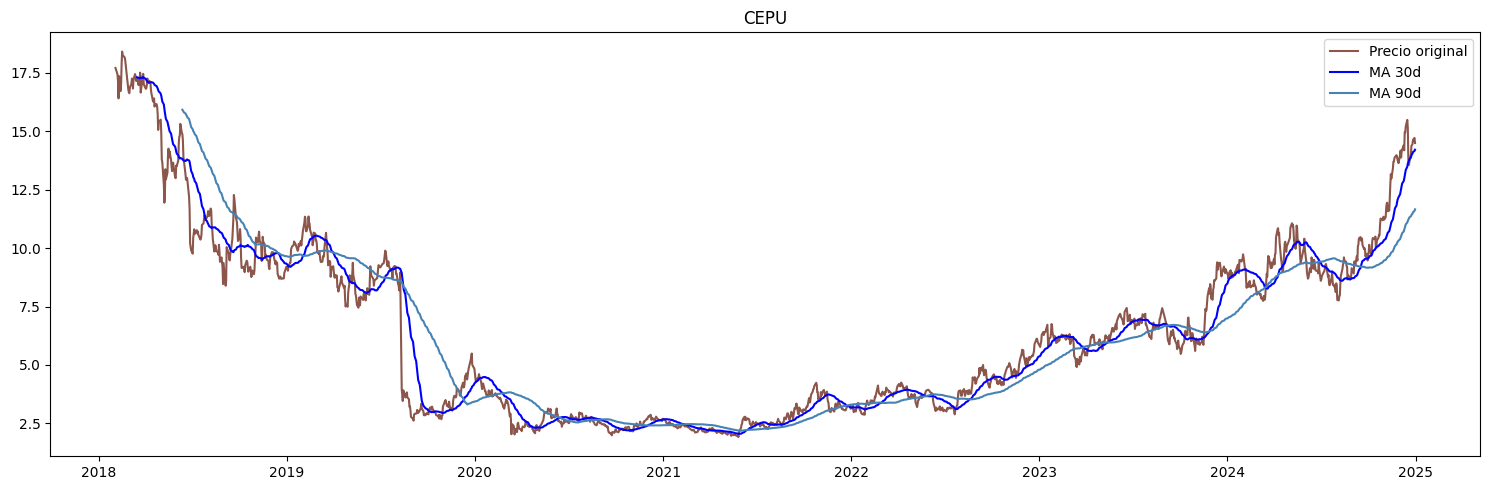

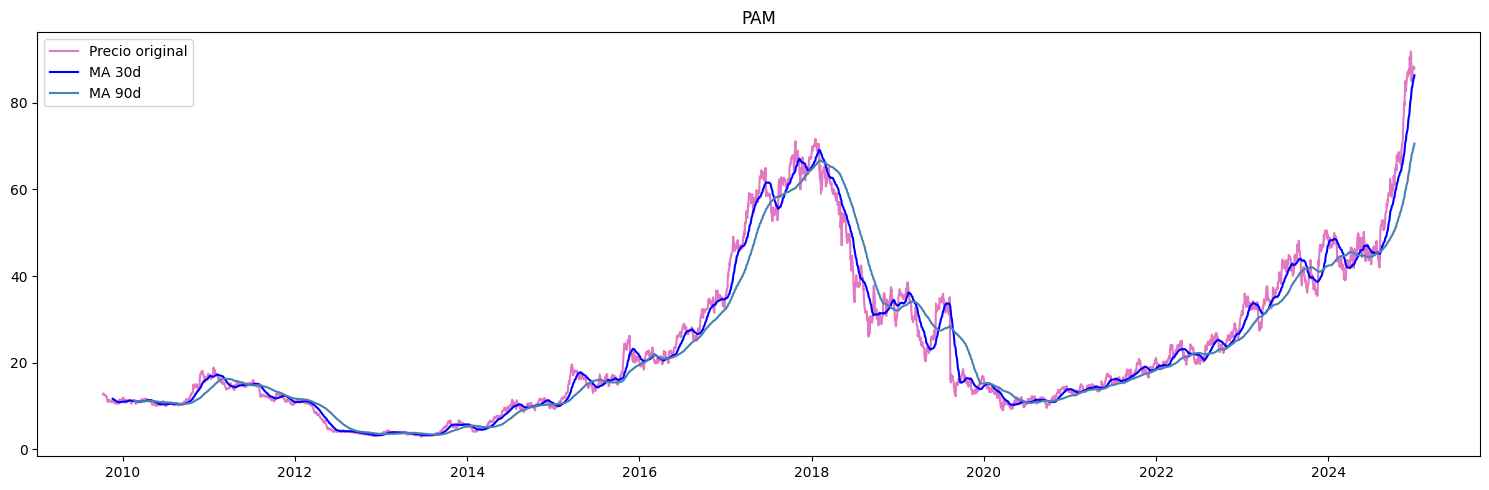

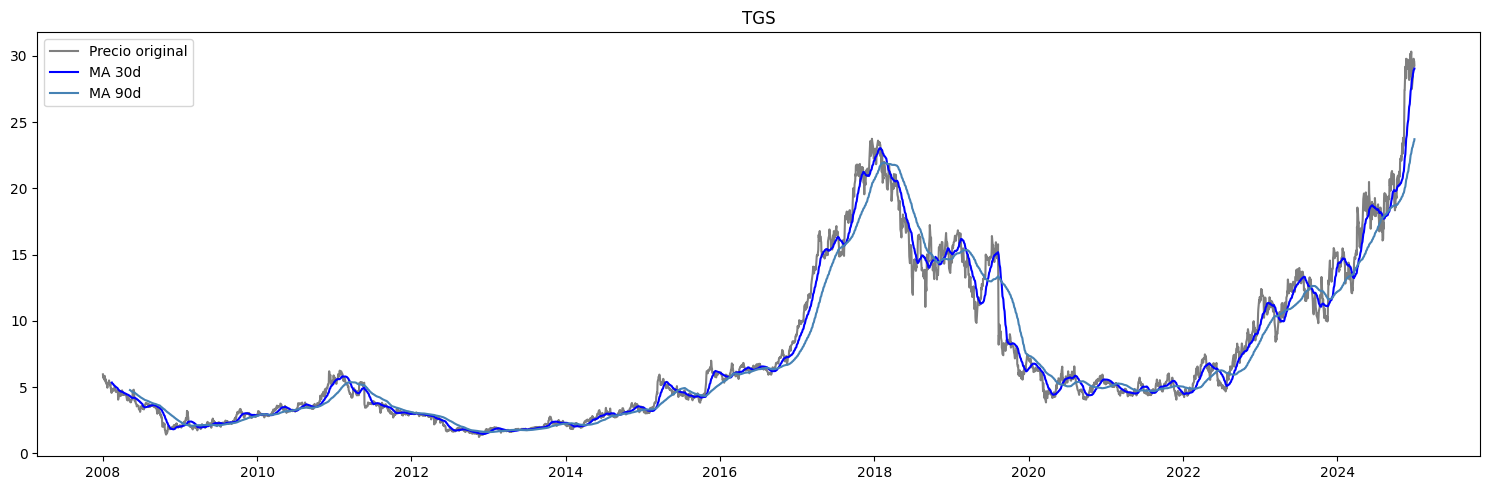

In [8]:
ventanas = [30, 90]  # 1 mes y 3 meses

for ticker in tickers:
    fig, ax = plt.subplots(figsize=(15, 5))

    # Precio original
    ax.plot(data.index, data[ticker], color=color_map[ticker], alpha=1, label='Precio original')

    # Calculamos y graficamos cada media móvil
    for ventana in ventanas:
        ma = data[ticker].rolling(window=ventana).mean()
        if ventana == 30:
            color = 'blue'
        elif ventana == 90:
            color = 'steelblue'
        else:
            color = None
        ax.plot(data.index, ma, color=color, label=f'MA {ventana}d')

    ax.set_title(ticker)
    ax.legend()

    plt.tight_layout()
    plt.show()

Notamos que la MA90 tiende a ser una función más suave que la MA30, esto es porque se mueve más lento.

Notar: Cuando más agrandamos el gap de la MA, más suave se vuelve la curva y menor es el ruido pero a costa de un mayor retraso en reaccionar a cambios reales de tendencia.

## Transformada de Fourier (FFT)

Veamos que pasa si aplicamos la Transformada de Fourier al precio de nuestras acciones.

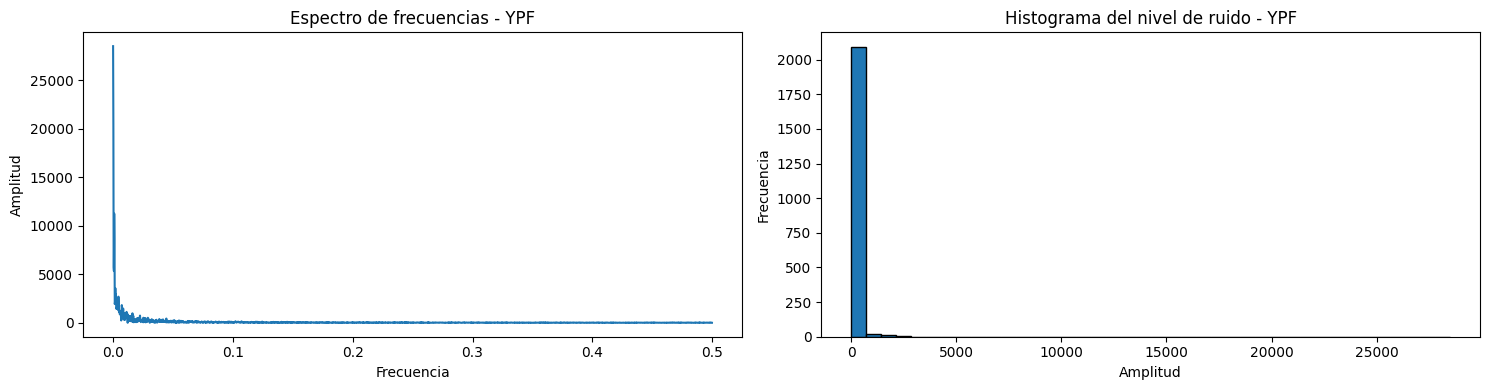

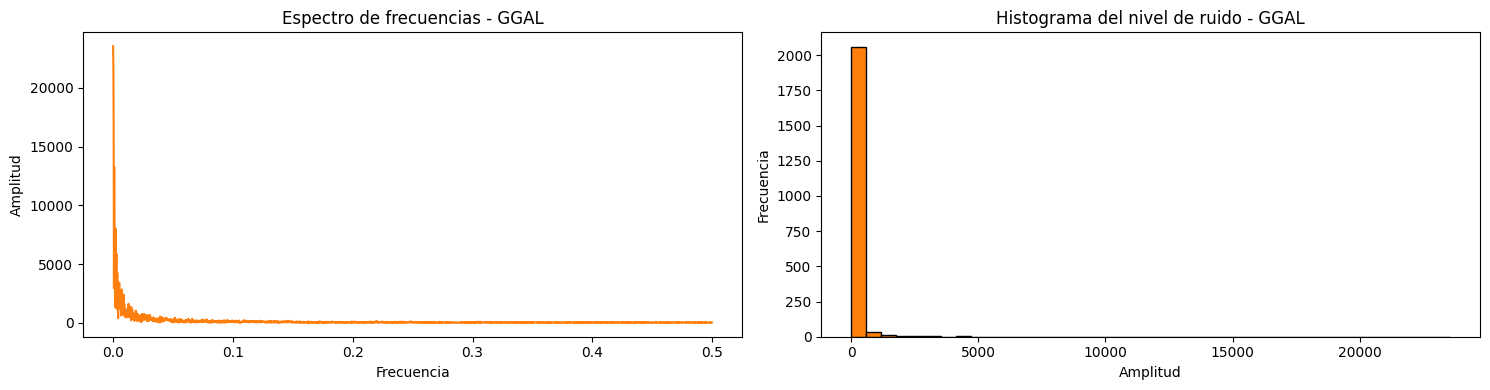

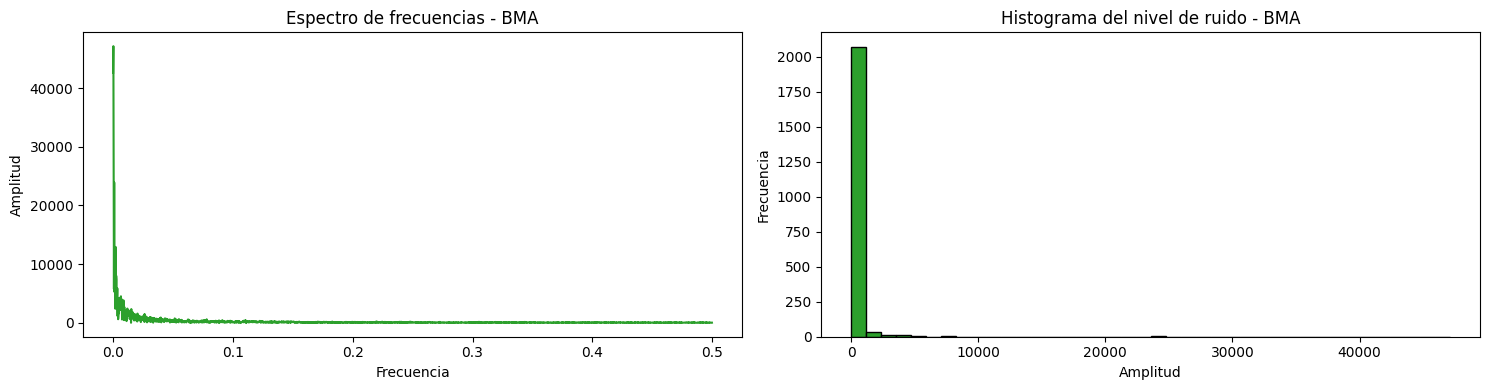

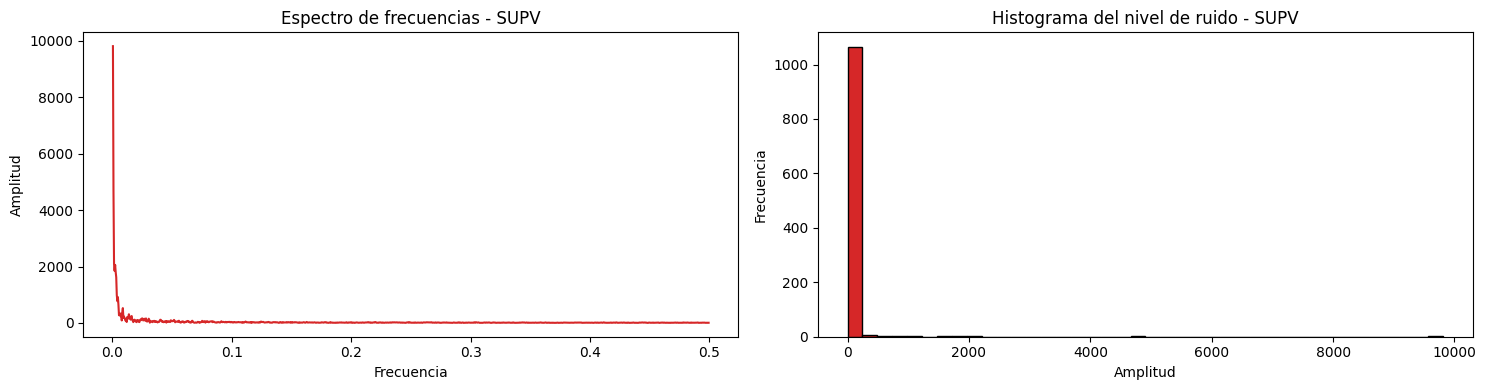

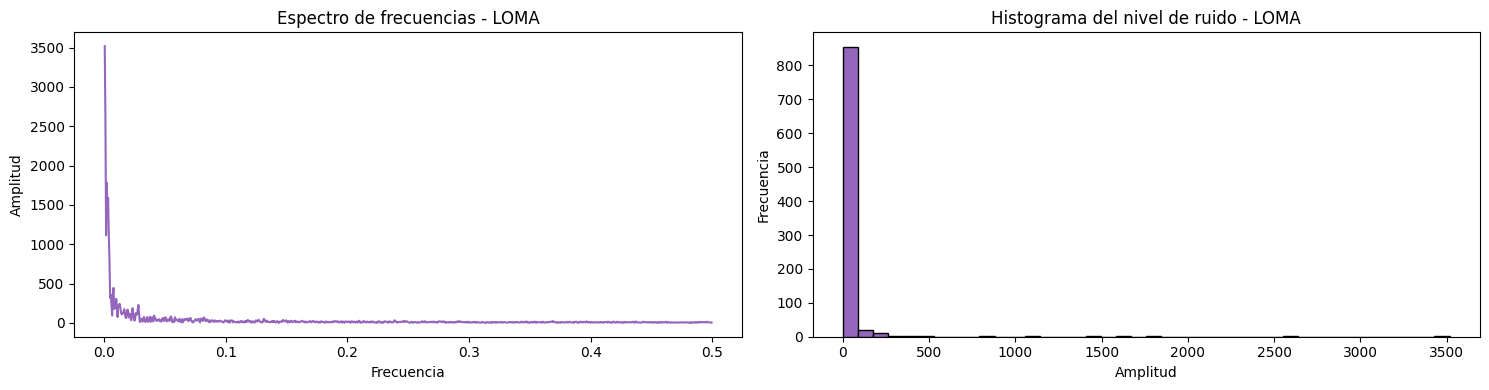

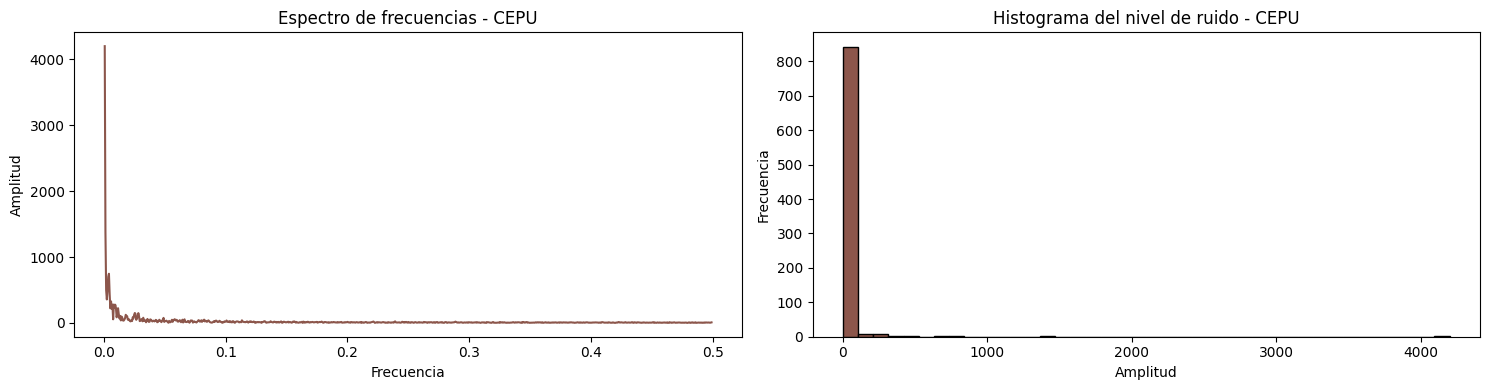

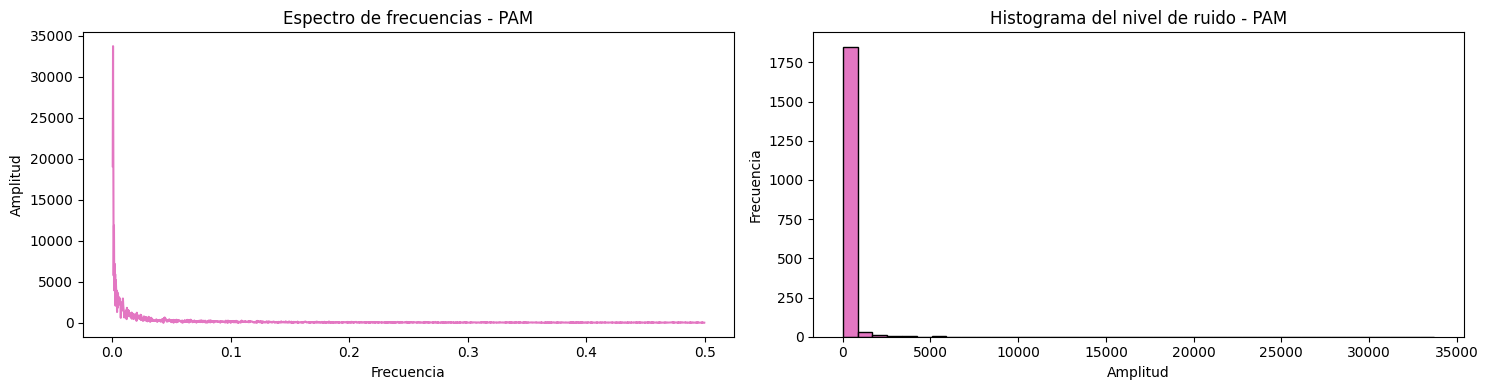

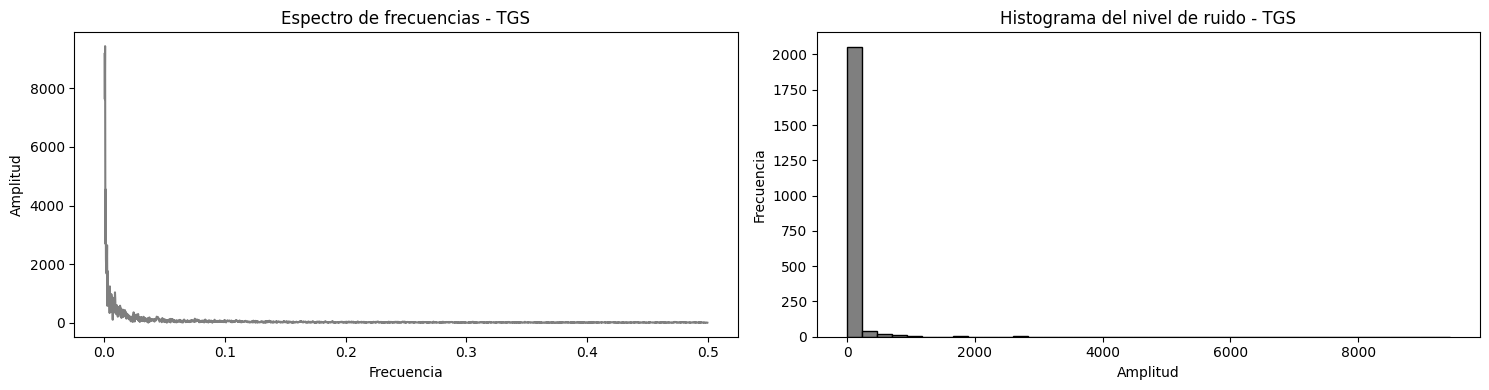

In [9]:
resultados_fft = {}  

for ticker in tickers:
    precios = data[ticker].dropna().values

    # Aplicamos FFT
    fft = np.fft.fft(precios)
    frecuencias = np.fft.fftfreq(len(precios))

    # Magnitud de las componentes espectrales (excluimos la frecuencia 0)
    nivel_ruido = np.abs(fft[1:len(fft)//2])

    resultados_fft[ticker] = {
        'fft': fft,
        'frecuencias': frecuencias,
        'nivel_ruido': nivel_ruido
    }

    # Graficamos el espectro de frecuencias y el histograma del nivel de ruido
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))

    axes[0].plot(
        frecuencias[1:len(frecuencias)//2],
        nivel_ruido,
        color=color_map[ticker]
    )
    axes[0].set_title(f'Espectro de frecuencias - {ticker}')
    axes[0].set_xlabel('Frecuencia')
    axes[0].set_ylabel('Amplitud')

    axes[1].hist(nivel_ruido, bins=40, color=color_map[ticker], edgecolor='black')
    axes[1].set_title(f'Histograma del nivel de ruido - {ticker}')
    axes[1].set_xlabel('Amplitud')
    axes[1].set_ylabel('Frecuencia')

    plt.tight_layout()
    plt.show()

Horrible. Viendo este grafico, nuestra primera intuicion es que los precios de las acciones **no parecen ser estacionarios**. 

Confirmemoslo


---

## Son nuestras acciones estacionarias? 

### Diagnóstico combinado ADF + KPSS

Recordemos 

| ADF p-value      | KPSS p-value      | Diagnóstico       |
|-------------------|---------------------|--------------------|
| p < 0.05             | p ≥ 0.05                | **Estacionaria**     |
| p < 0.05             | p < 0.05                | **Indefinida**        |
| p ≥ 0.05             | p ≥ 0.05                | **Indefinida**        |
| p ≥ 0.05             | p < 0.05                | **No estacionaria**   |

In [10]:
def test_estacionariedad(serie, nombre='serie', regression_kpss='c'):
    adf_p = adfuller(serie, autolag='AIC')[1]

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')  # KPSS suele tirar warning por interpolación de p-value
        kpss_p = kpss(serie, regression=regression_kpss, nlags='auto')[1]

    print(f'{nombre}:')
    print(f'  ADF p-value:  {adf_p:.4f}')
    print(f'  KPSS p-value: {kpss_p:.4f}')
    print()

    return adf_p, kpss_p


resultados_estacionariedad = {}

for ticker in tickers:
    precios = data[ticker].dropna()
    adf_p, kpss_p = test_estacionariedad(precios, nombre=f'Precio {ticker}')
    resultados_estacionariedad[ticker] = {'adf_p': adf_p, 'kpss_p': kpss_p}

Precio YPF:
  ADF p-value:  0.3361
  KPSS p-value: 0.0100

Precio GGAL:
  ADF p-value:  0.8021
  KPSS p-value: 0.0100

Precio BMA:
  ADF p-value:  0.6655
  KPSS p-value: 0.0100

Precio SUPV:
  ADF p-value:  0.5915
  KPSS p-value: 0.0100

Precio LOMA:
  ADF p-value:  0.0461
  KPSS p-value: 0.0100

Precio CEPU:
  ADF p-value:  0.3392
  KPSS p-value: 0.0100

Precio PAM:
  ADF p-value:  0.9915
  KPSS p-value: 0.0100

Precio TGS:
  ADF p-value:  0.9926
  KPSS p-value: 0.0100



In [11]:
def diagnostico(adf_p, kpss_p, alpha=0.05):
    adf_estacionaria = adf_p < alpha
    kpss_estacionaria = kpss_p >= alpha

    if adf_estacionaria and kpss_estacionaria:
        return 'Estacionaria'
    elif not adf_estacionaria and not kpss_estacionaria:
        return 'No estacionaria'
    elif not adf_estacionaria and kpss_estacionaria:
        return 'Indefinida'
    else:
        return 'Indefinida'


for ticker in tickers:
    adf_p = resultados_estacionariedad[ticker]['adf_p']
    kpss_p = resultados_estacionariedad[ticker]['kpss_p']
    resultados_estacionariedad[ticker]['diagnostico'] = diagnostico(adf_p, kpss_p)

resumen_estacionariedad_df = pd.DataFrame(resultados_estacionariedad).T
resumen_estacionariedad_df

,adf_p,kpss_p,diagnostico
YPF,0.336127,0.01,No estacionaria
GGAL,0.802117,0.01,No estacionaria
BMA,0.665543,0.01,No estacionaria
SUPV,0.591539,0.01,No estacionaria
LOMA,0.046126,0.01,Indefinida
CEPU,0.339238,0.01,No estacionaria
PAM,0.991507,0.01,No estacionaria
TGS,0.99263,0.01,No estacionaria


Luego, salvo por LOMA, que es indefinida, las series son **no estacionarias** 

La FFT asume que la señal es estacionaria, entonces estamos implementando una transformada incorrecta. 

Debemos implementar otra transformada que pueda usarse con series no estacionarias.

## Algoritmo Piramidal de Mallat (para GGAL)

Esta transformada no necesita que las series sea estacionarias.

Aplicamos wavedec, que ejecuta el algoritmo piramidal: descompone la señal en un componente de aproximación (tendencia gruesa) y varios componentes de detalle (fluctuaciones en distintas escalas temporales).

La metodologia utilizada por Mallat es la siguiente:
1. Toma la señal actual (al principio, el precio original).
2. La pasa por un filtro pasa-bajos → obtiene la aproximación de ese paso (versión suavizada).
3. La pasa por un filtro pasa-altos → obtiene el detalle de ese paso (lo que se "perdió" al suavizar, es decir, las fluctuaciones de esa escala).
4. Hace downsampling (se queda con la mitad de los puntos) en ambos resultados.
5. Guarda el detalle, y repite el proceso tomando la aproximación como nueva "señal actual" para el siguiente nivel.

In [12]:
wavelet = 'db4'

resultados_wavelet = {}

for ticker in tickers:
    precios_ticker = data[ticker].dropna()
    fechas_ticker = precios_ticker.index
    precios_vals = precios_ticker.values

    # Nivel máximo de descomposición permitido por el largo de la serie
    nivel_max = pywt.dwt_max_level(len(precios_vals), pywt.Wavelet(wavelet).dec_len)

    # Elegimos un nivel razonable (no hace falta ir al máximo)
    nivel = min(6, nivel_max)

    # wavedec aplica el algoritmo piramidal de Mallat
    coeffs = pywt.wavedec(precios_vals, wavelet, level=nivel)

    cA = coeffs[0]
    cDs = coeffs[1:]

    resultados_wavelet[ticker] = {
        'fechas': fechas_ticker,
        'precios_vals': precios_vals,
        'nivel_max': nivel_max,
        'nivel': nivel,
        'coeffs': coeffs,
        'cA': cA,
        'cDs': cDs
    }

    print(f'--- {ticker} ---')
    print(f'Nivel máximo de descomposición posible: {nivel_max}')
    print(f'Nivel usado: {nivel}')
    print(f'Cantidad de niveles de detalle: {len(cDs)}')
    for i, cD in enumerate(cDs):
        print(f'  Detalle nivel {len(cDs)-i}: {len(cD)} coeficientes')
    print()

--- YPF ---
Nivel máximo de descomposición posible: 9
Nivel usado: 6
Cantidad de niveles de detalle: 6
  Detalle nivel 6: 73 coeficientes
  Detalle nivel 5: 140 coeficientes
  Detalle nivel 4: 274 coeficientes
  Detalle nivel 3: 541 coeficientes
  Detalle nivel 2: 1075 coeficientes
  Detalle nivel 1: 2143 coeficientes

--- GGAL ---
Nivel máximo de descomposición posible: 9
Nivel usado: 6
Cantidad de niveles de detalle: 6
  Detalle nivel 6: 73 coeficientes
  Detalle nivel 5: 140 coeficientes
  Detalle nivel 4: 274 coeficientes
  Detalle nivel 3: 541 coeficientes
  Detalle nivel 2: 1075 coeficientes
  Detalle nivel 1: 2143 coeficientes

--- BMA ---
Nivel máximo de descomposición posible: 9
Nivel usado: 6
Cantidad de niveles de detalle: 6
  Detalle nivel 6: 73 coeficientes
  Detalle nivel 5: 140 coeficientes
  Detalle nivel 4: 274 coeficientes
  Detalle nivel 3: 541 coeficientes
  Detalle nivel 2: 1075 coeficientes
  Detalle nivel 1: 2143 coeficientes

--- SUPV ---
Nivel máximo de descomp

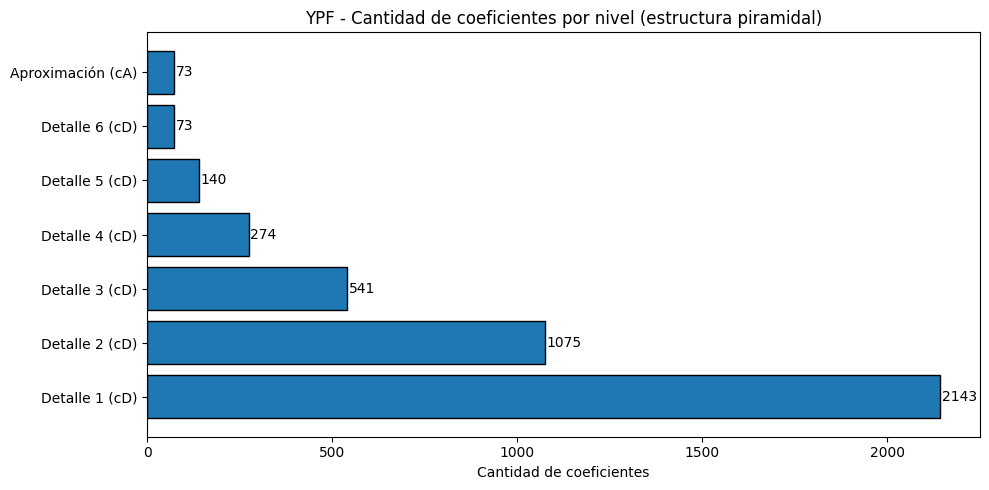

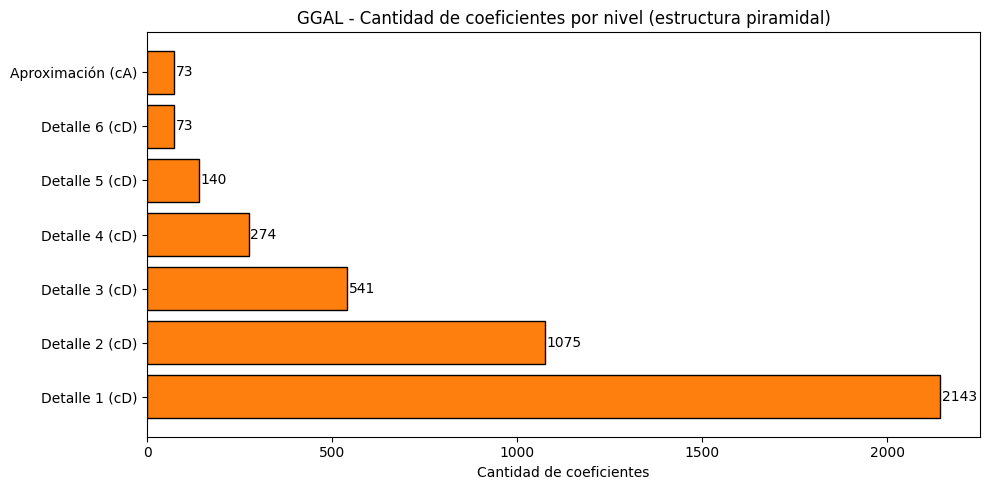

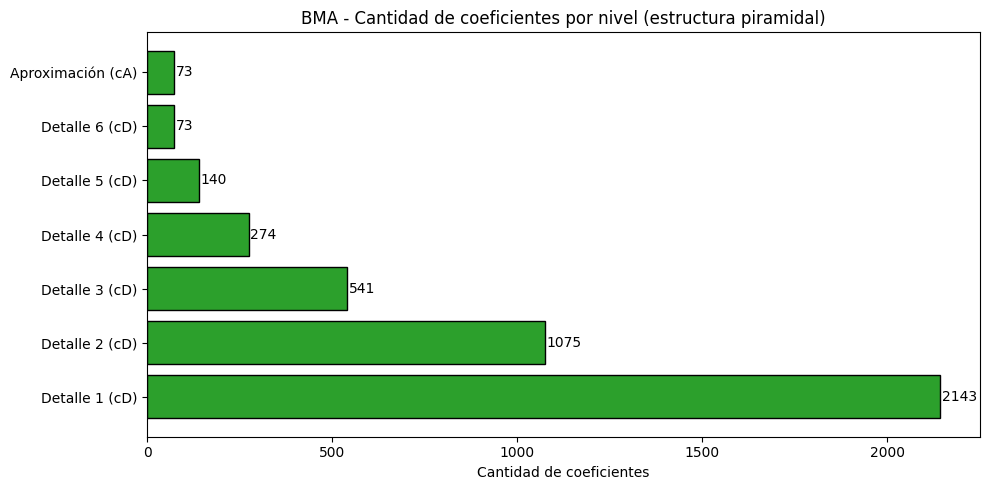

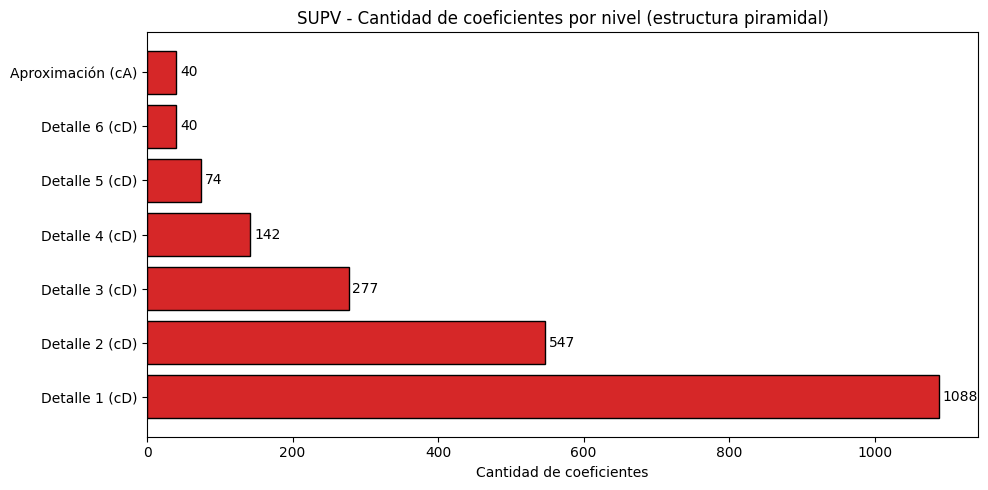

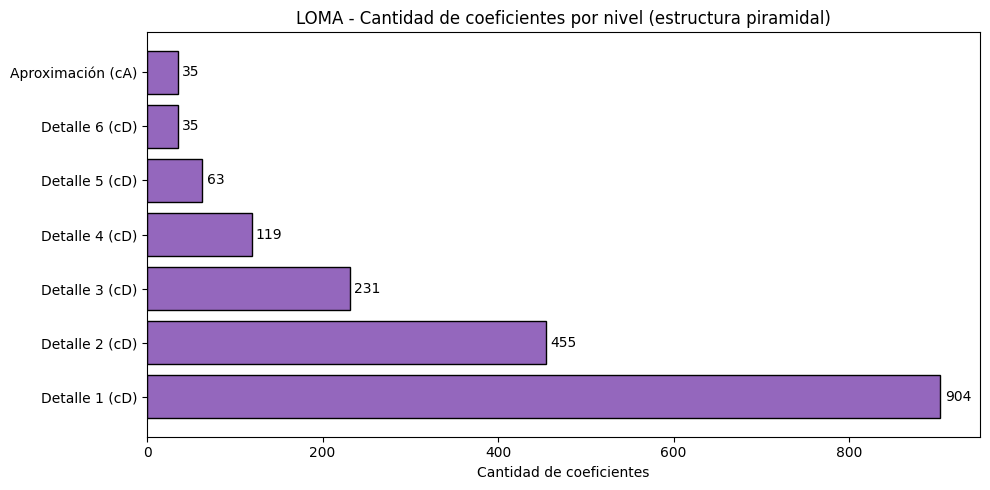

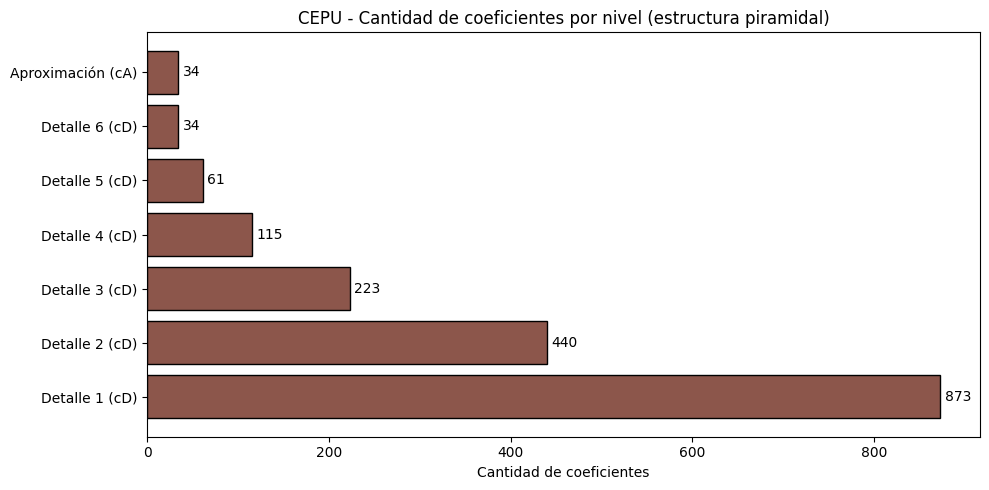

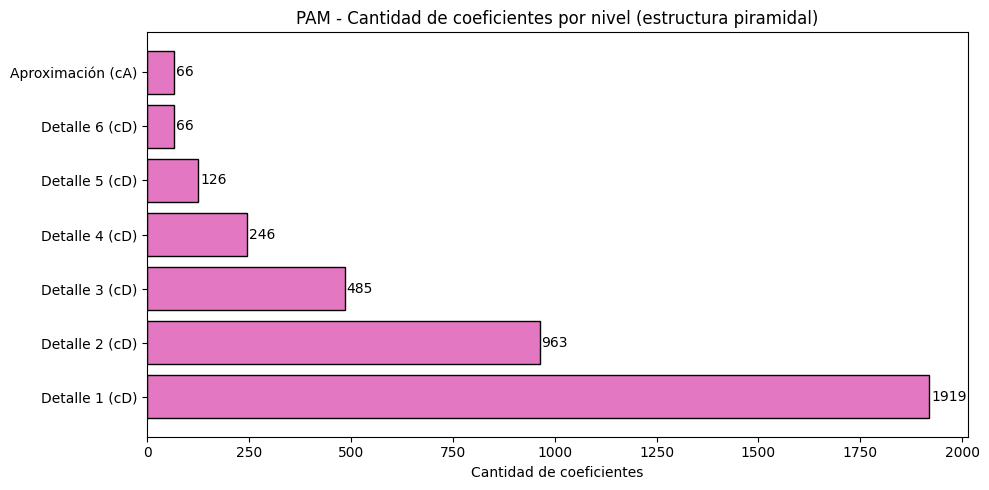

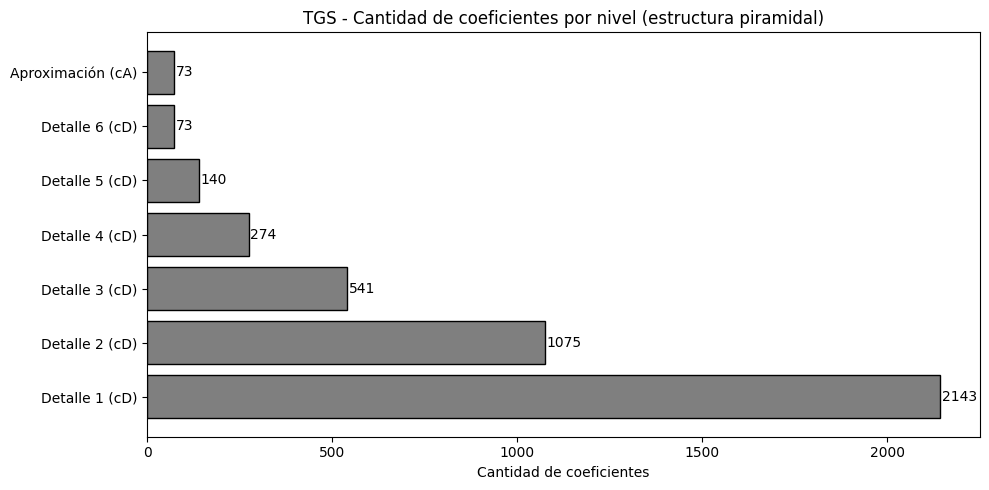

In [13]:
# Cantidad de coeficientes por nivel (pirámide) para TODOS los tickers

for ticker in tickers:
    cA = resultados_wavelet[ticker]['cA']
    cDs = resultados_wavelet[ticker]['cDs']

    etiquetas = ['Aproximación (cA)'] + [f'Detalle {len(cDs)-i} (cD)' for i in range(len(cDs))]
    tamaños = [len(cA)] + [len(cD) for cD in cDs]

    plt.figure(figsize=(10, 5))
    barras = plt.barh(etiquetas, tamaños, color=color_map[ticker], edgecolor='black')
    plt.gca().invert_yaxis()  # aproximación arriba, detalles finos abajo

    for barra, tam in zip(barras, tamaños):
        plt.text(tam + 5, barra.get_y() + barra.get_height()/2, str(tam), va='center')

    plt.title(f'{ticker} - Cantidad de coeficientes por nivel (estructura piramidal)')
    plt.xlabel('Cantidad de coeficientes')
    plt.tight_layout()
    plt.show()

Podemos ver que hay algunas acciones que difieren en cantidad de coeficientes respecto a otros. Ejemplo GGAL tiene un cD1 = 2143 mientras que SUPV tiene cD1 = 1088.

Esto se debe al total de datos historicos que tenemos de nuestras acciones.
- Tenemos 17 años de datos historicos de GGAL (4279 dias)
- Tenemos 10 años de datos historicos de SUPV (2169 dias)

Entonces el Detalle 1 (cD1) se calcula asi:
- Donwsampling GGAL: 4279 / 2 -> 2143 
- Downsampling SUPV: 2169 / 2 -> 1088


Detalle 2 (cD2) es la mitad del resultado de la division, y asi hasta llegar a cD6

In [14]:
for ticker in tickers:
    print(f"{ticker}: nivel_max={resultados_wavelet[ticker]['nivel_max']}, "
          f"nivel usado={resultados_wavelet[ticker]['nivel']}, "
          f"cantidad de datos={len(resultados_wavelet[ticker]['precios_vals'])}")

YPF: nivel_max=9, nivel usado=6, cantidad de datos=4279
GGAL: nivel_max=9, nivel usado=6, cantidad de datos=4279
BMA: nivel_max=9, nivel usado=6, cantidad de datos=4279
SUPV: nivel_max=8, nivel usado=6, cantidad de datos=2169
LOMA: nivel_max=8, nivel usado=6, cantidad de datos=1802
CEPU: nivel_max=7, nivel usado=6, cantidad de datos=1739
PAM: nivel_max=9, nivel usado=6, cantidad de datos=3832
TGS: nivel_max=9, nivel usado=6, cantidad de datos=4279


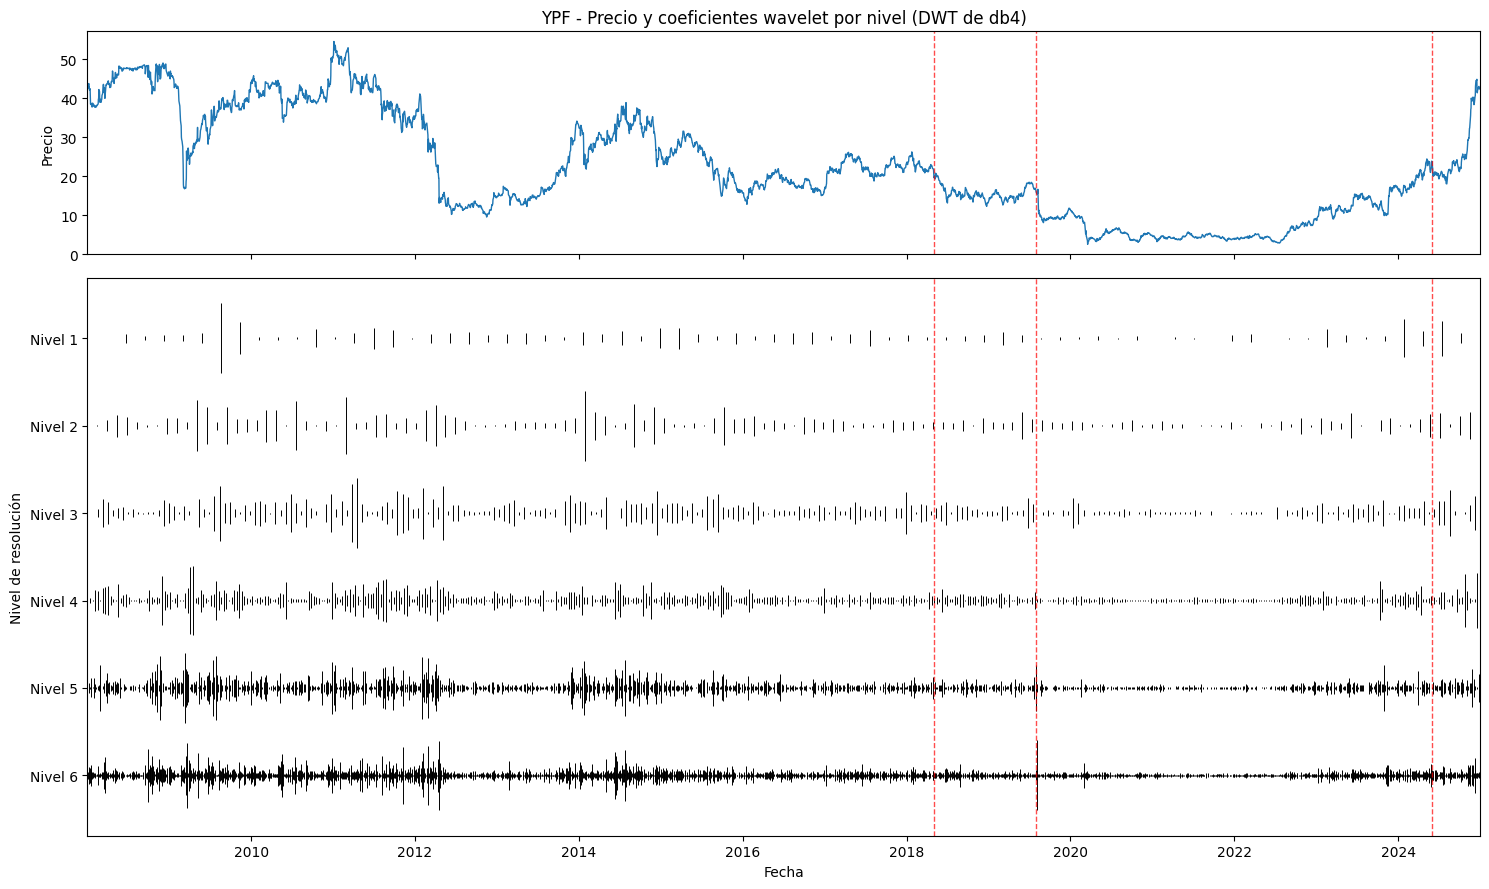

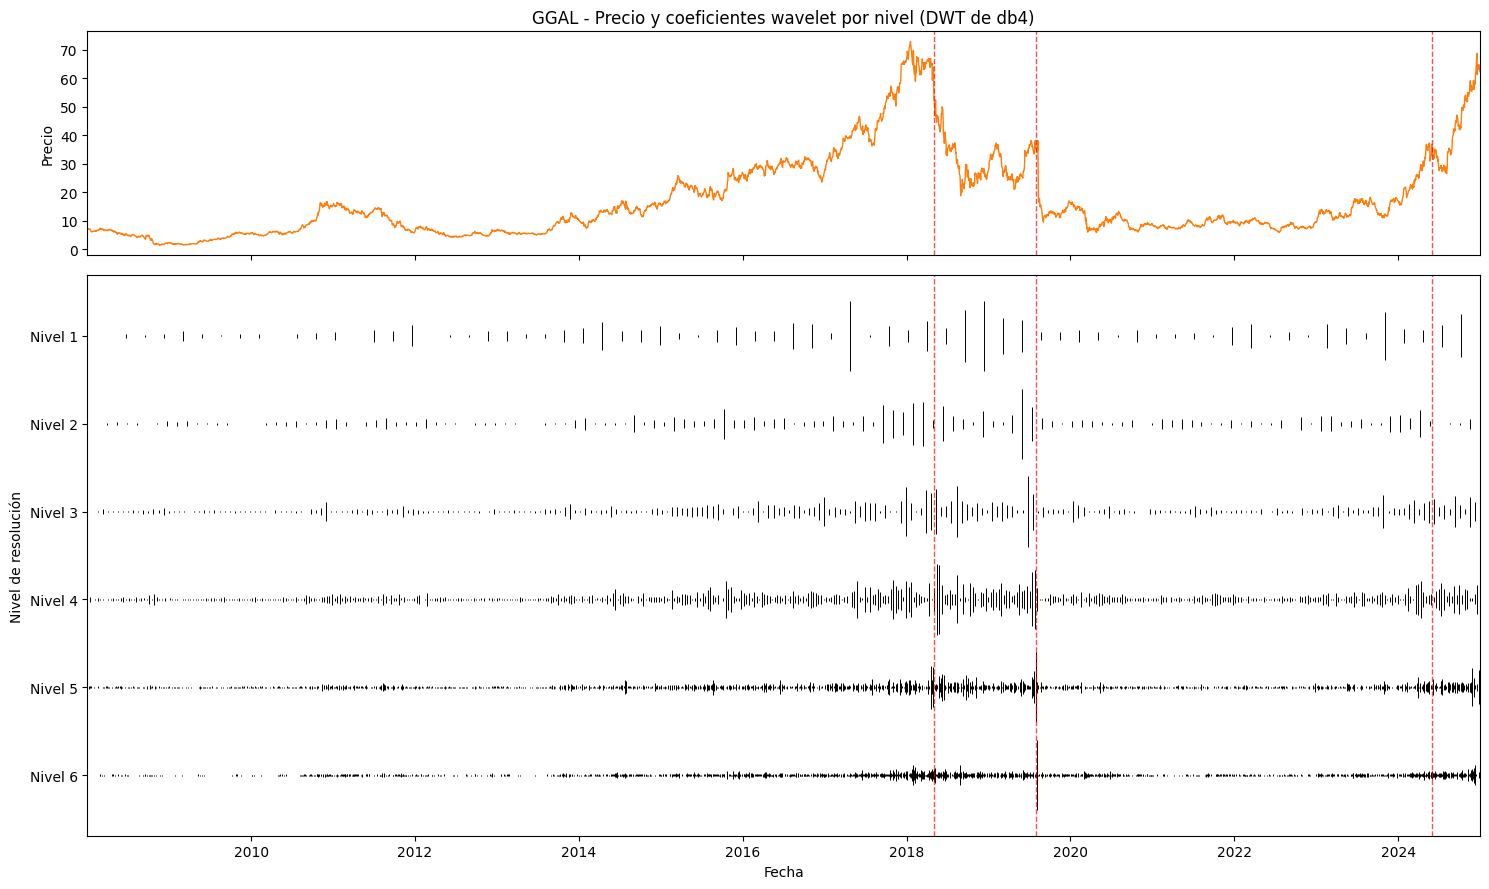

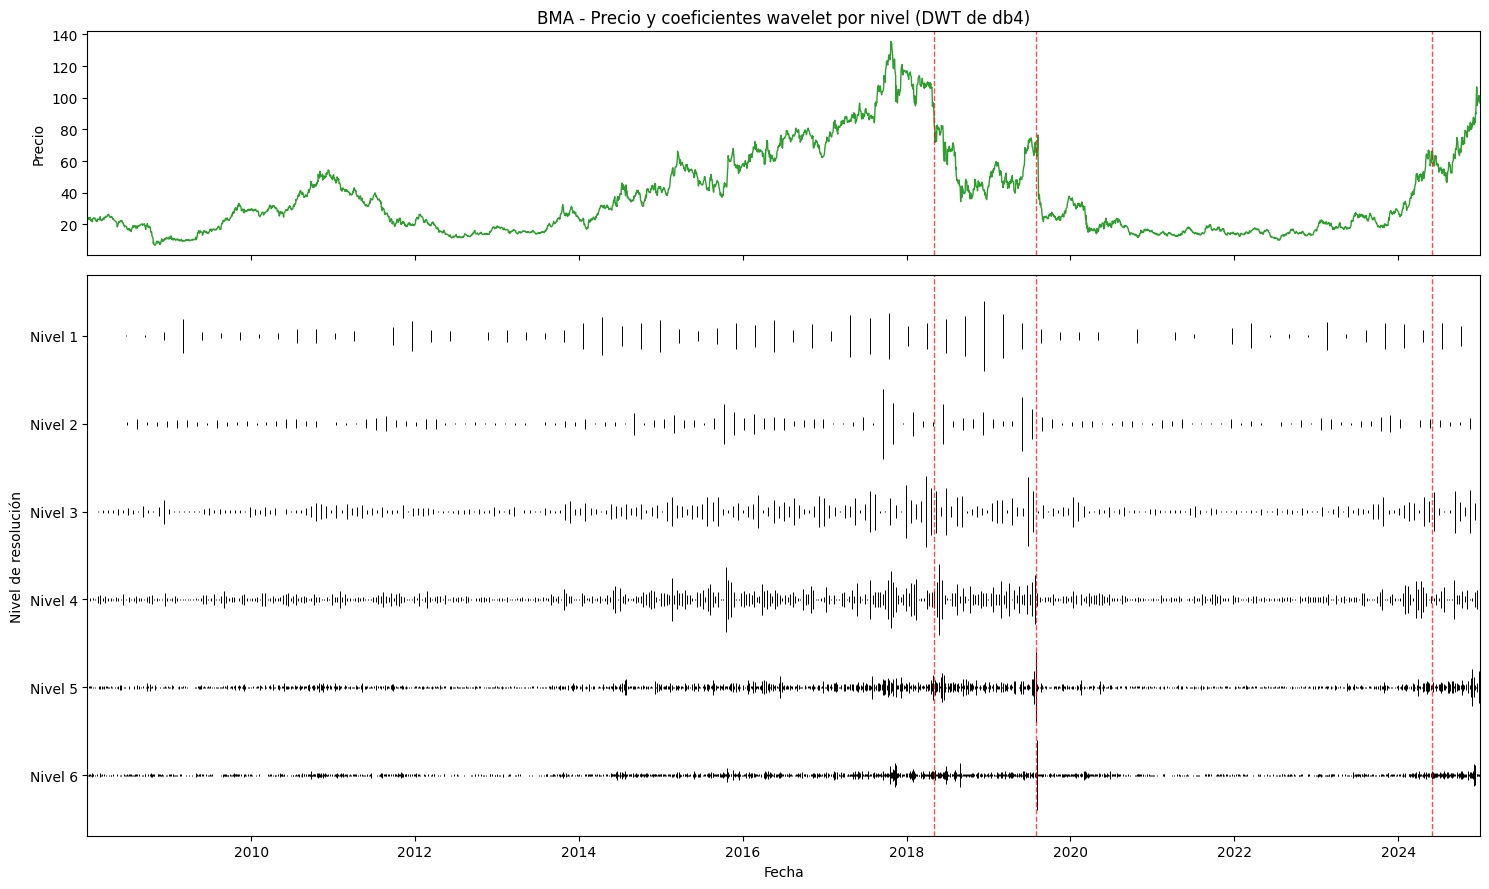

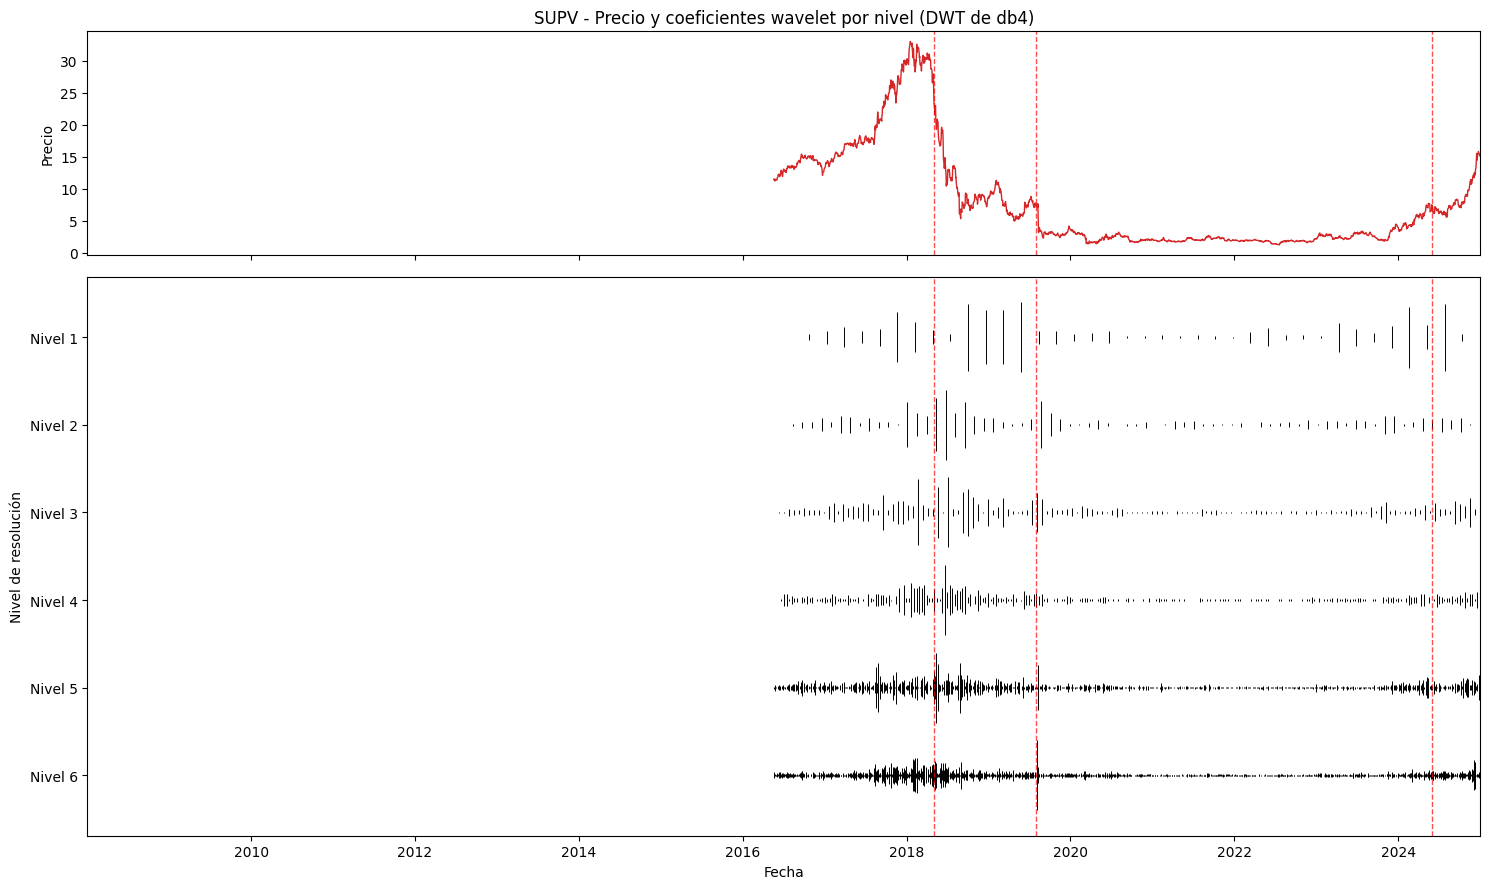

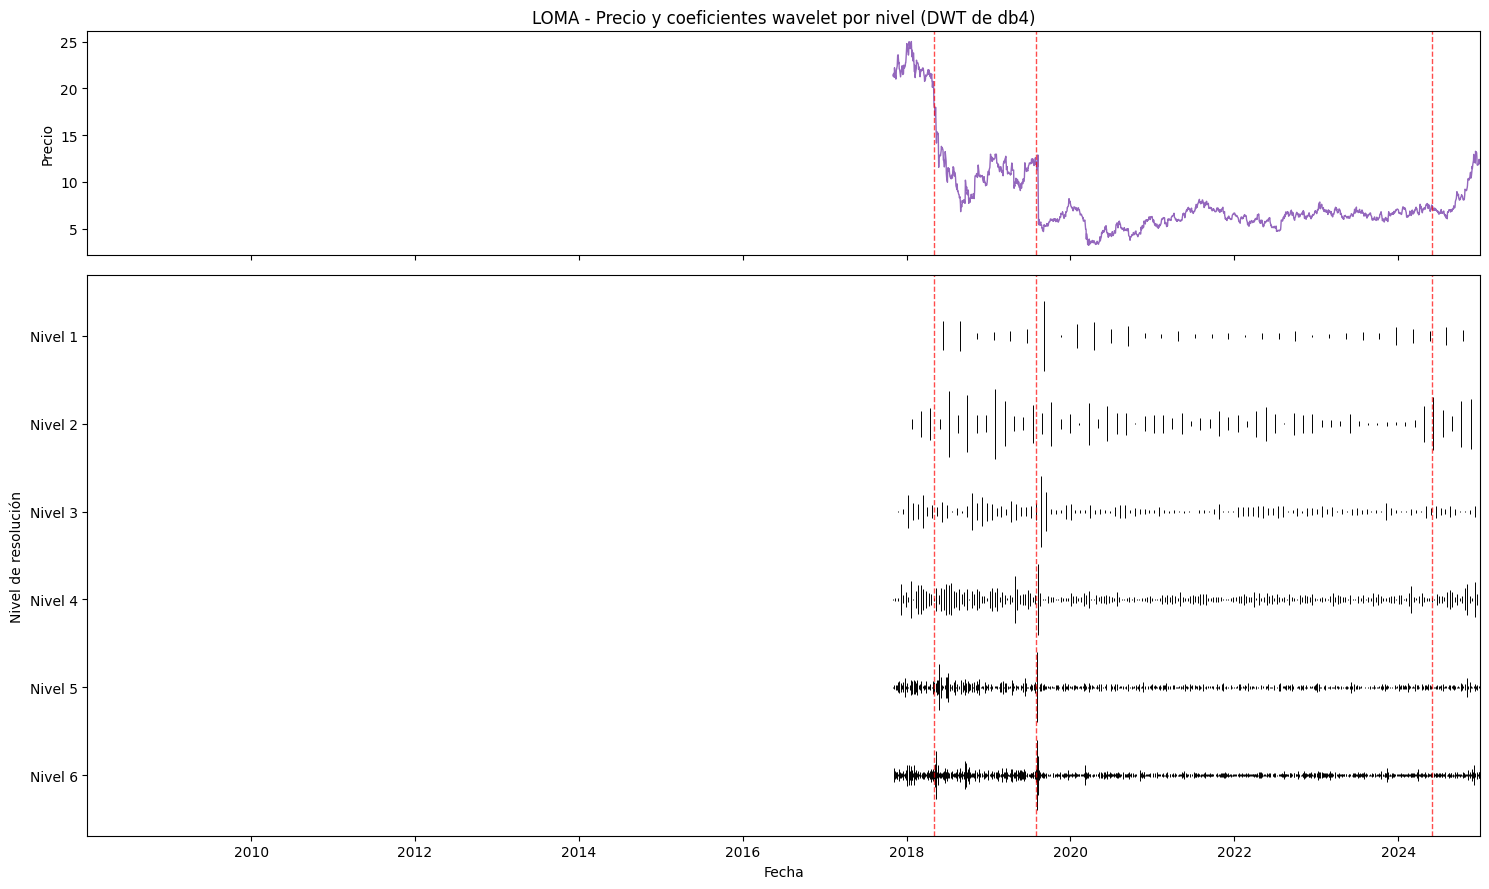

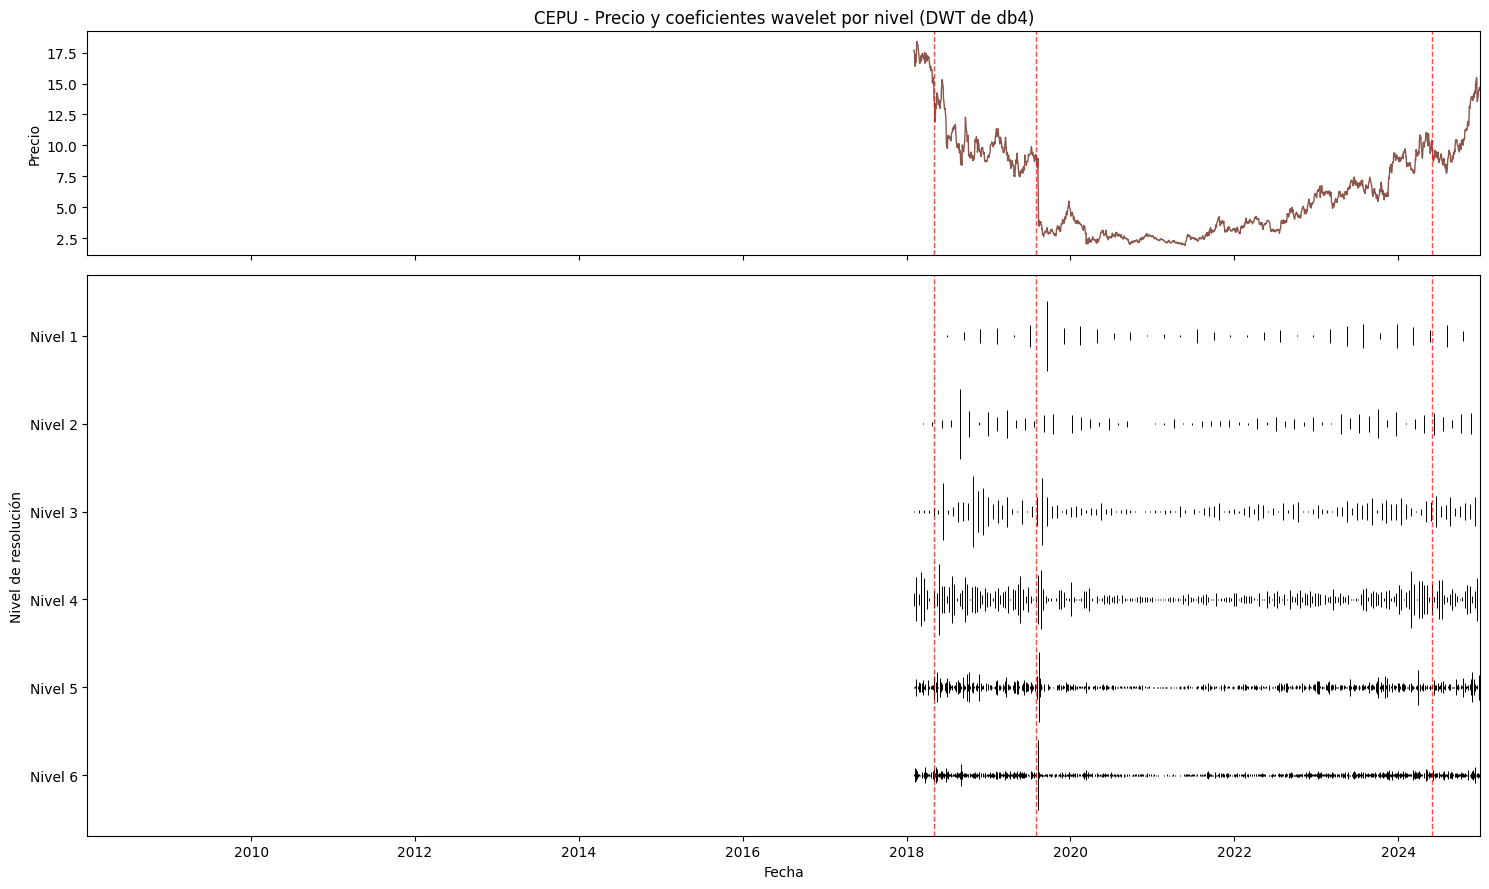

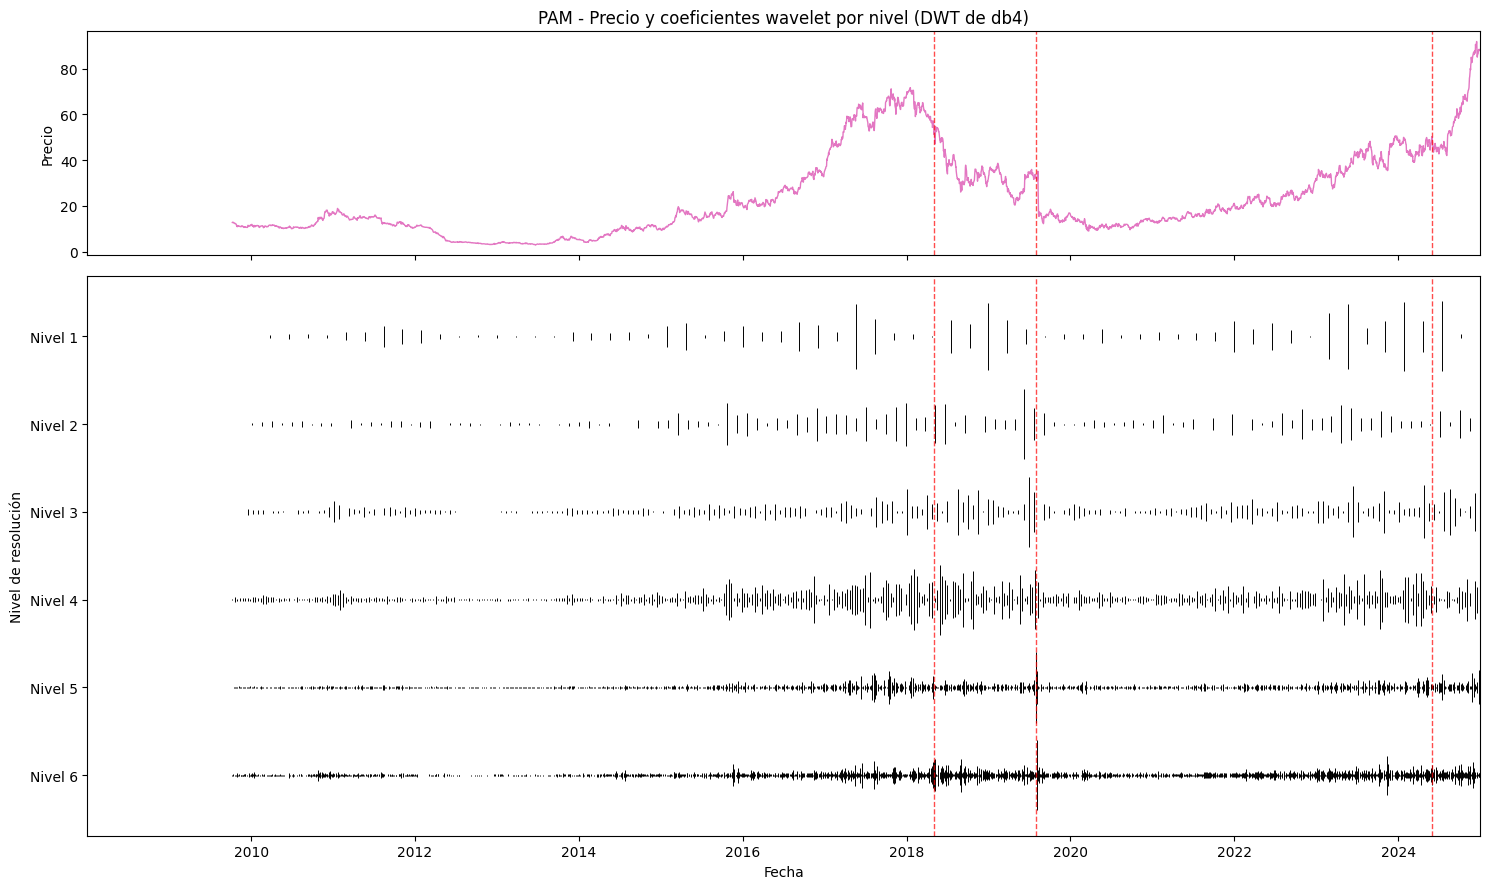

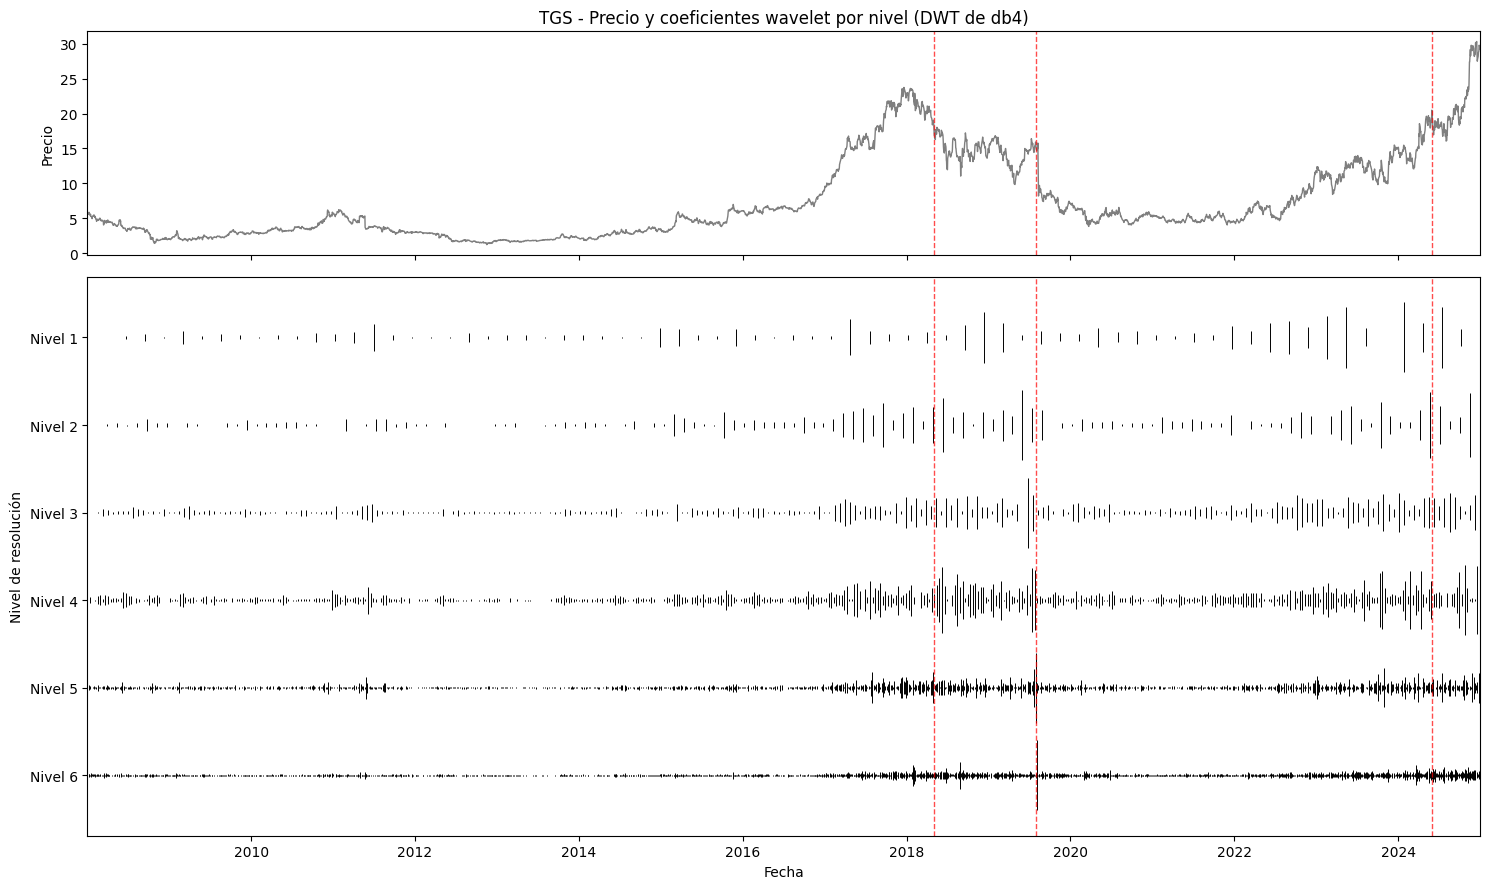

In [15]:
fechas_clave = pd.to_datetime(['2018-05-01', '2019-08-01', '2024-06-01'])

# Rango de fechas fijo, común a todos los tickers (el más amplio posible)
fecha_min_global = min(resultados_wavelet[t]['fechas'][0] for t in tickers)
fecha_max_global = max(resultados_wavelet[t]['fechas'][-1] for t in tickers)

for ticker in tickers:
    fechas_ticker = resultados_wavelet[ticker]['fechas']
    precios_vals = resultados_wavelet[ticker]['precios_vals']
    cDs = resultados_wavelet[ticker]['cDs']
    nivel = resultados_wavelet[ticker]['nivel']

    fig, (ax_precio, ax_scalo) = plt.subplots(
        2, 1, figsize=(15, 9),
        sharex=True,
        gridspec_kw={'height_ratios': [1, 2.5]}
    )

    # Panel superior: precio
    ax_precio.plot(fechas_ticker, precios_vals, color=color_map[ticker], linewidth=1)
    ax_precio.set_ylabel('Precio')
    ax_precio.set_title(f'{ticker} - Precio y coeficientes wavelet por nivel (DWT de {wavelet})')

    # Panel inferior: scalogram
    n_niveles = len(cDs)
    fecha_inicio = fechas_ticker[0]
    fecha_fin = fechas_ticker[-1]

    for i, cD in enumerate(cDs):
        fila_y = n_niveles - i

        posiciones_relativas = np.arange(len(cD)) / len(cD)
        posiciones_fecha = fecha_inicio + posiciones_relativas * (fecha_fin - fecha_inicio)

        magnitudes = np.abs(cD) / (np.abs(cD).max() + 1e-9)

        ax_scalo.vlines(posiciones_fecha, fila_y - magnitudes * 0.4, fila_y + magnitudes * 0.4,
                         color='black', linewidth=0.7)

    ax_scalo.set_yticks(range(1, n_niveles + 1))
    ax_scalo.set_yticklabels([f'Nivel {n_niveles - i}' for i in range(n_niveles)])
    ax_scalo.set_xlabel('Fecha')
    ax_scalo.set_ylabel('Nivel de resolución')

    ax_scalo.xaxis.set_major_locator(mdates.YearLocator(2))
    ax_scalo.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    # Fijamos el mismo rango de fechas en todos los gráficos
    ax_scalo.set_xlim(fecha_min_global, fecha_max_global)

    # Líneas verticales punteadas en las fechas clave
    for f in fechas_clave:
        ax_precio.axvline(x=f, color='red', linestyle='--', linewidth=1, alpha=0.7)
        ax_scalo.axvline(x=f, color='red', linestyle='--', linewidth=1, alpha=0.7)

    plt.tight_layout()
    plt.show()

El Escalograma logra identificar en qué momento y a qué escala ocurre un momento "importante" en la acción (mas concentracion y mas barritas).

Vemos 3 concentraciones importantes:
- **Mediados 2018:** Crisis cambiaria Argentina de 2018 (devaluacion abrupta del peso con Macri).
- **Mediadios 2019:** Incertidumbre política (Formula Fernandez-Fernandez gana las PASO).
- **Mediados 2024:** Fuerte revalorización del sector privado (Asume Milei la presidencia).

Reconstruimos cada componente por separado

In [16]:
def reconstruir_componente(coeffs, idx, wavelet, largo_original):
    coeffs_zero = [np.zeros_like(c) for c in coeffs]
    coeffs_zero[idx] = coeffs[idx]
    return pywt.waverec(coeffs_zero, wavelet)[:largo_original]


for ticker in tickers:
    coeffs = resultados_wavelet[ticker]['coeffs']
    cDs = resultados_wavelet[ticker]['cDs']
    precios_vals = resultados_wavelet[ticker]['precios_vals']

    # Componente de aproximación (tendencia de fondo, escala más gruesa)
    aproximacion = reconstruir_componente(coeffs, 0, wavelet, len(precios_vals))

    # Componentes de detalle (fluctuaciones en cada escala temporal)
    detalles = [reconstruir_componente(coeffs, i+1, wavelet, len(precios_vals)) for i in range(len(cDs))]

    resultados_wavelet[ticker]['aproximacion'] = aproximacion
    resultados_wavelet[ticker]['detalles'] = detalles

Precio original vs componente de aproximación

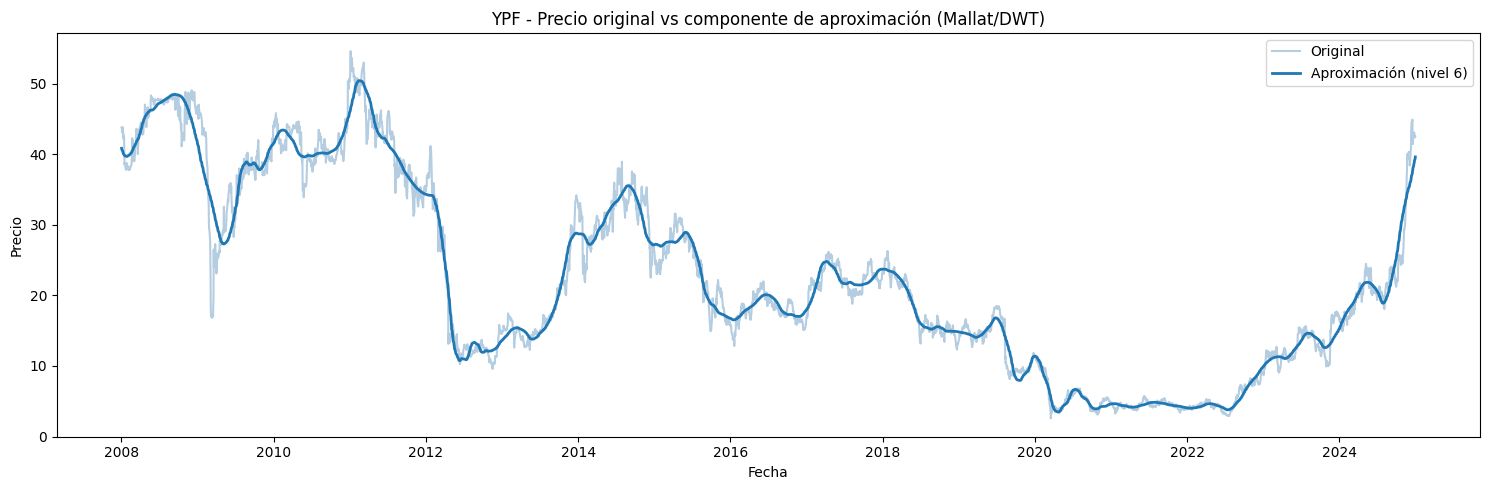

YPF - R² (varianza explicada): 0.9774



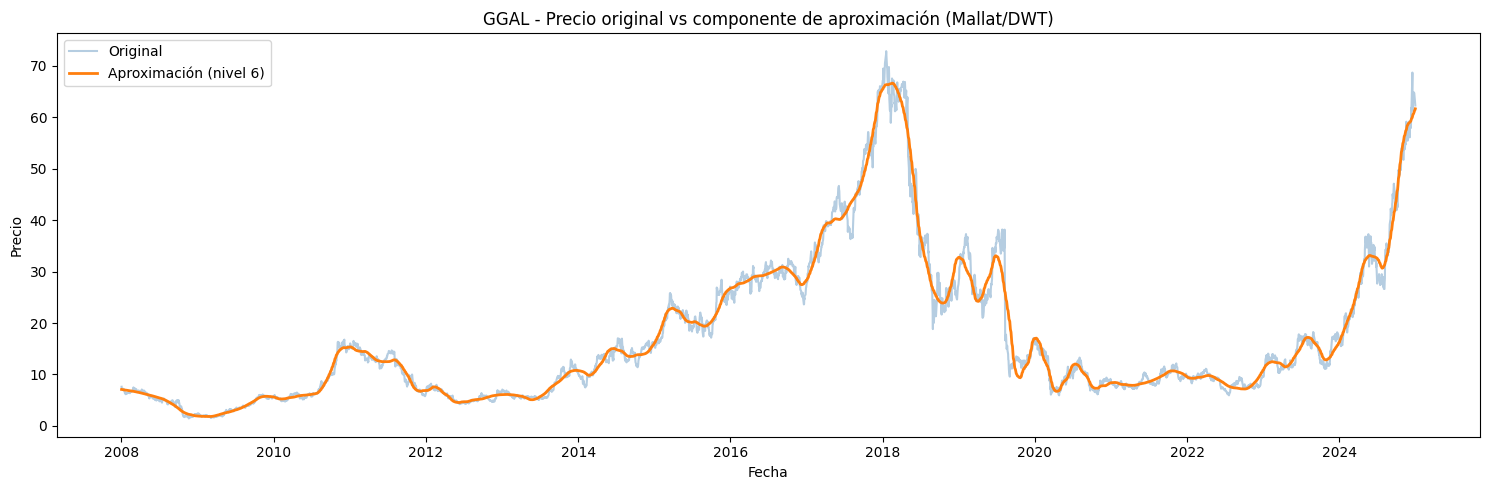

GGAL - R² (varianza explicada): 0.9847



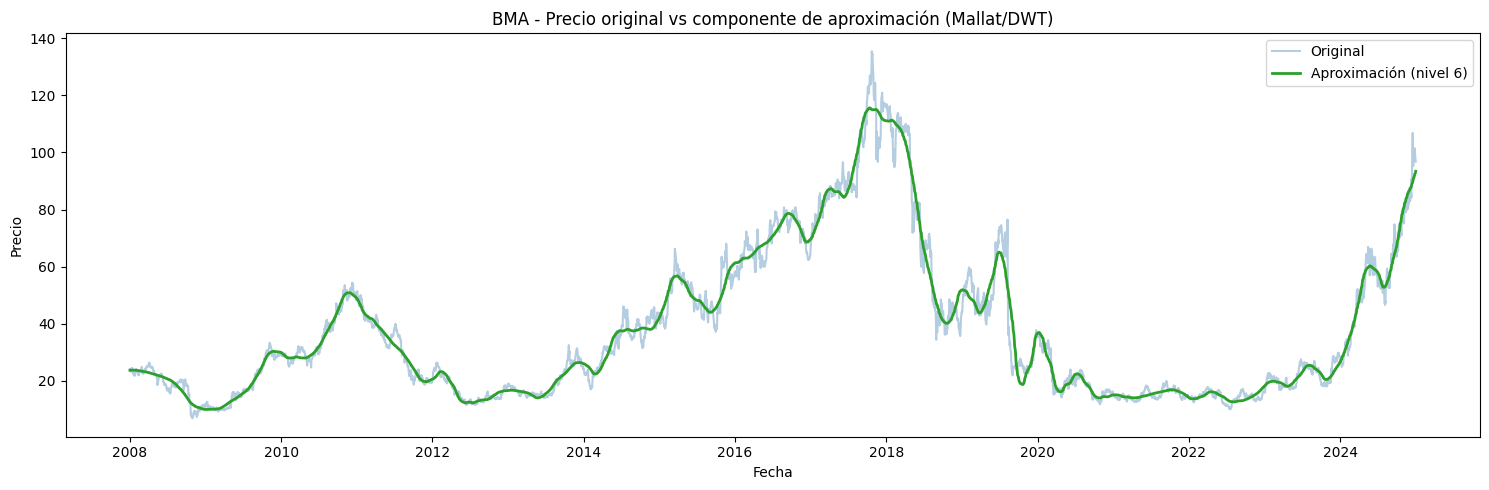

BMA - R² (varianza explicada): 0.9804



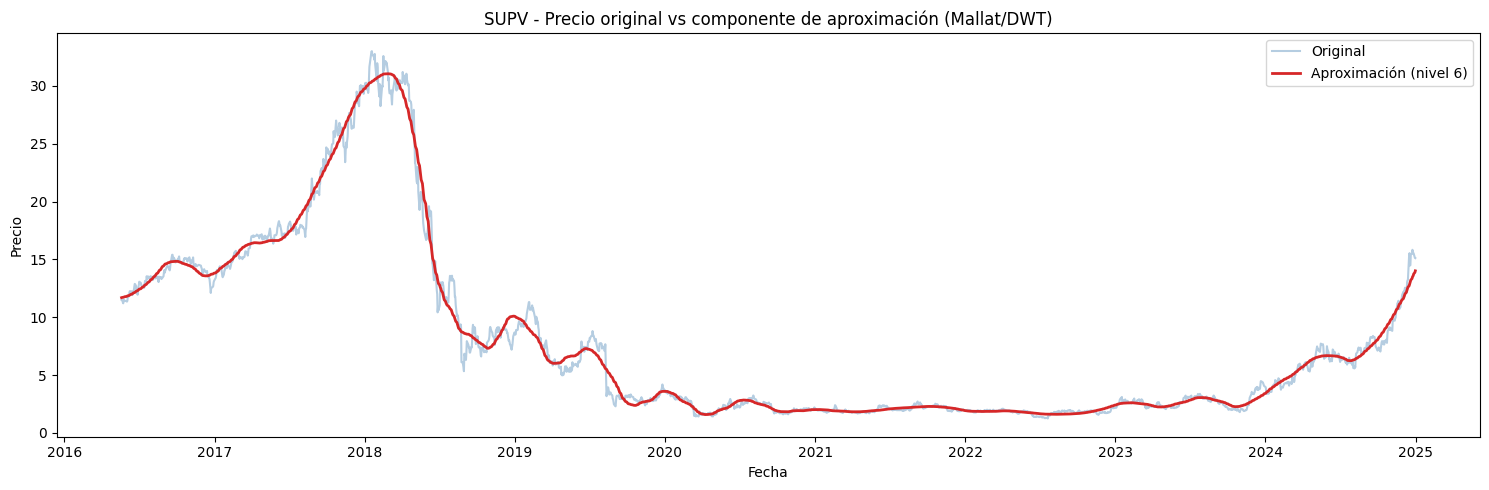

SUPV - R² (varianza explicada): 0.9908



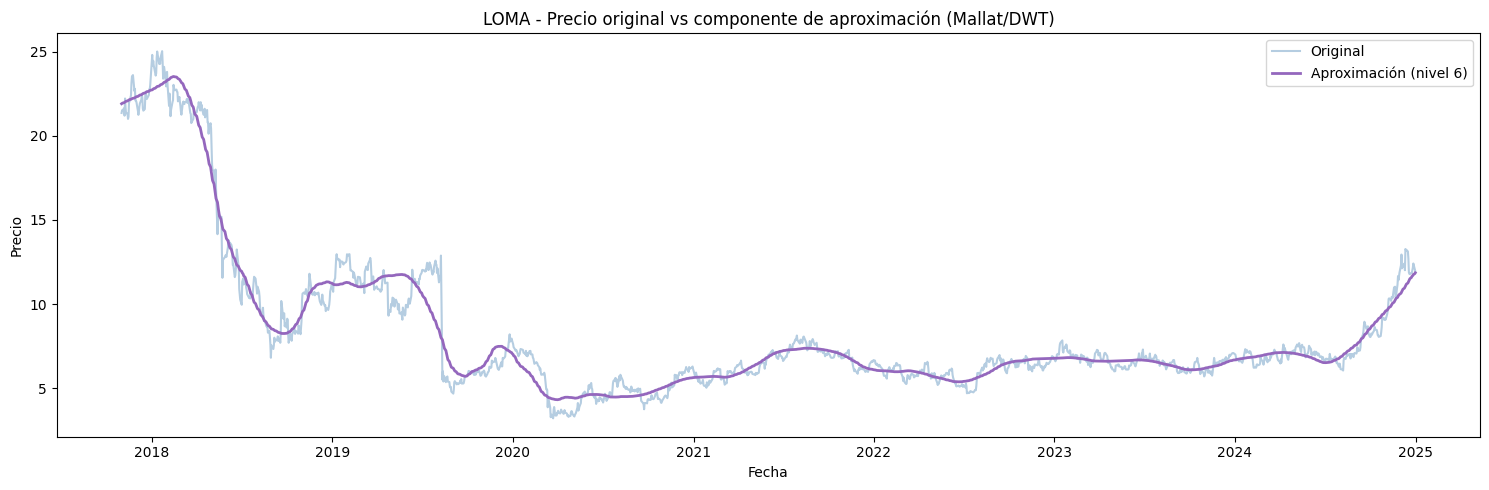

LOMA - R² (varianza explicada): 0.9697



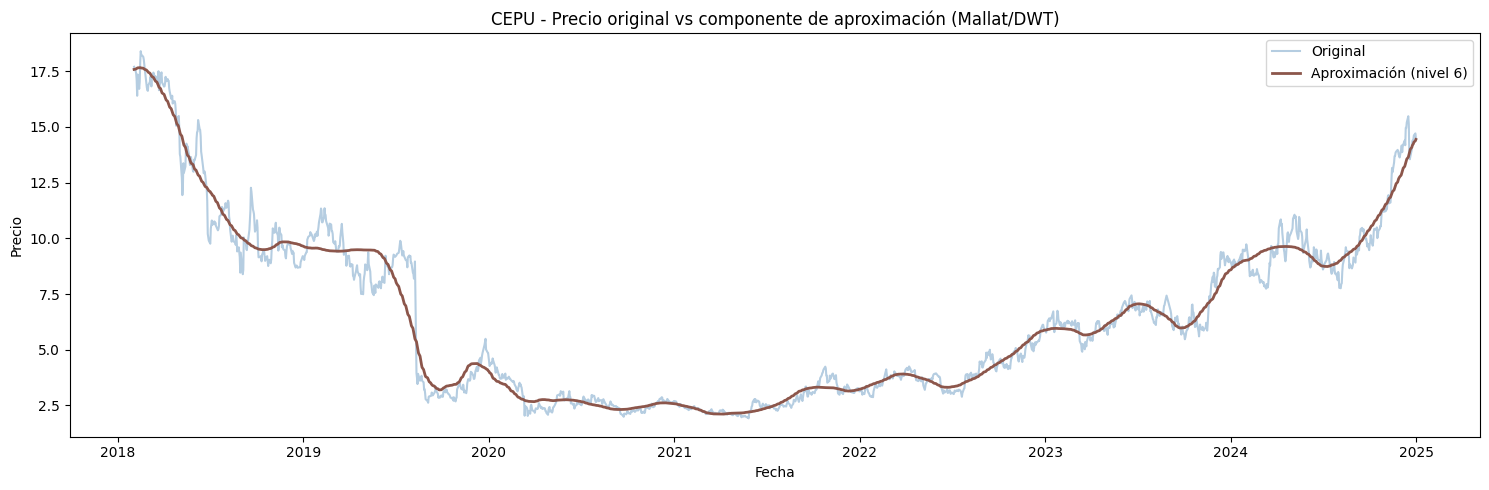

CEPU - R² (varianza explicada): 0.9714



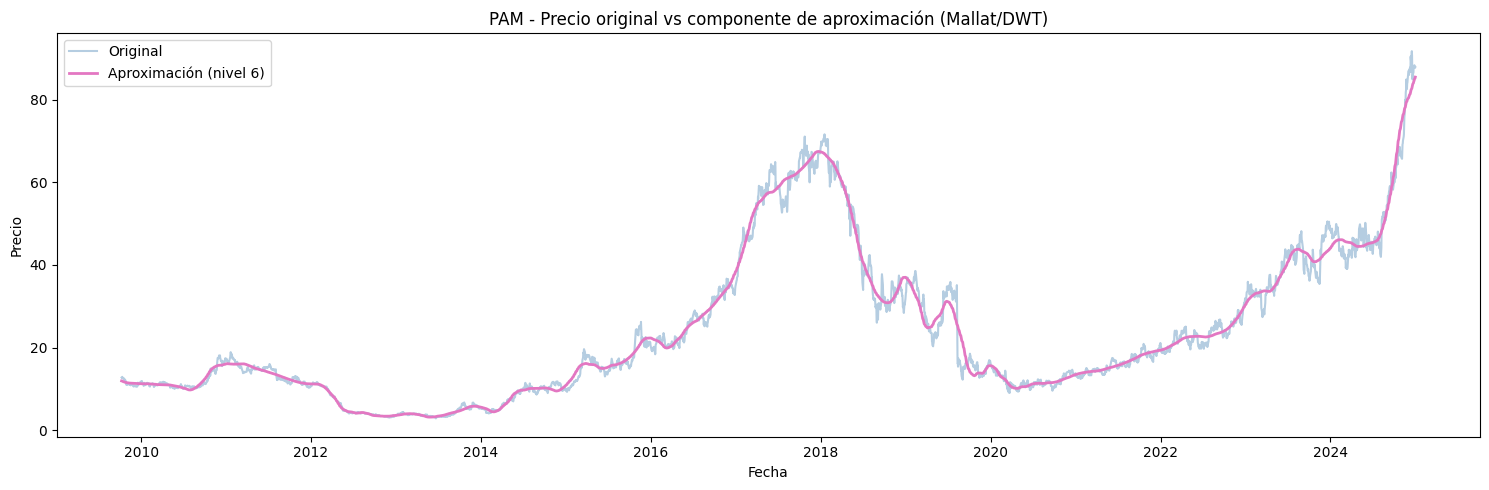

PAM - R² (varianza explicada): 0.9872



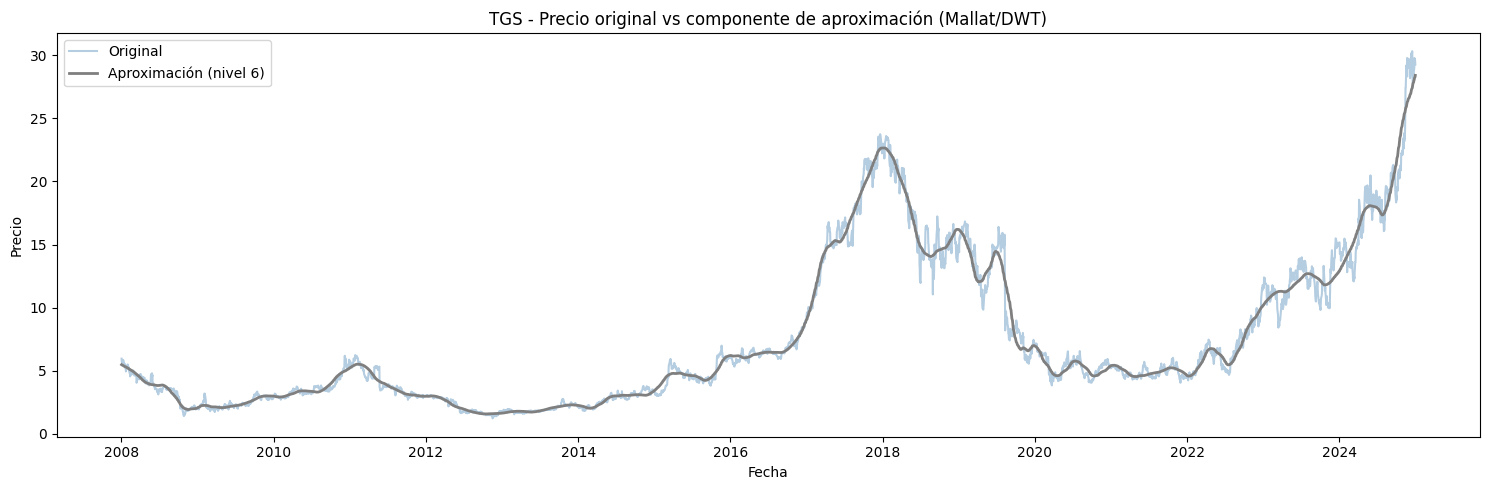

TGS - R² (varianza explicada): 0.9850



In [17]:
for ticker in tickers:
    fechas_ticker = resultados_wavelet[ticker]['fechas']
    precios_vals = resultados_wavelet[ticker]['precios_vals']
    aproximacion = resultados_wavelet[ticker]['aproximacion']
    nivel = resultados_wavelet[ticker]['nivel']

    plt.figure(figsize=(15, 5))
    plt.plot(fechas_ticker, precios_vals, color='steelblue', alpha=0.4, label='Original')
    plt.plot(fechas_ticker, aproximacion, color=color_map[ticker], linewidth=2, label=f'Aproximación (nivel {nivel})')
    plt.title(f'{ticker} - Precio original vs componente de aproximación (Mallat/DWT)')
    plt.xlabel('Fecha')
    plt.ylabel('Precio')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Error R²
    error = precios_vals - aproximacion
    r2 = 1 - (np.sum(error**2) / np.sum((precios_vals - precios_vals.mean())**2))
    resultados_wavelet[ticker]['r2_aproximacion'] = r2
    print(f'{ticker} - R² (varianza explicada): {r2:.4f}')
    print()

Descomposición completa por niveles

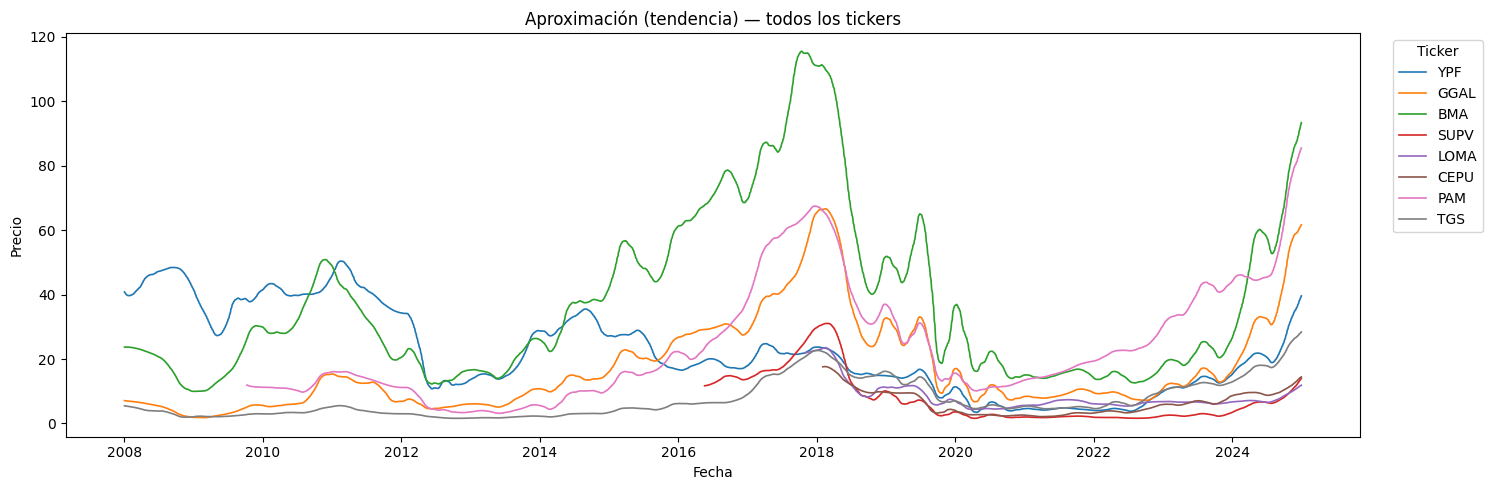

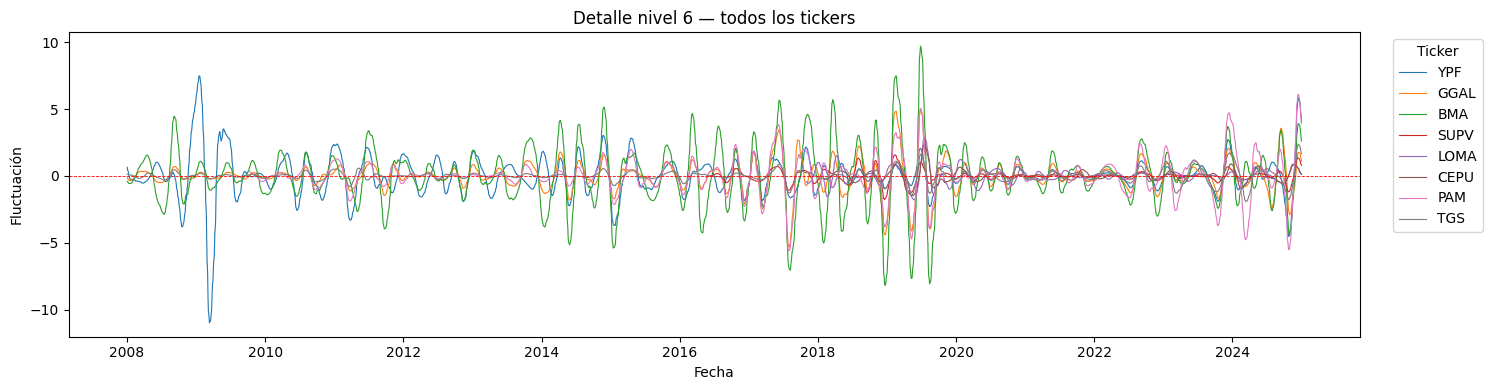

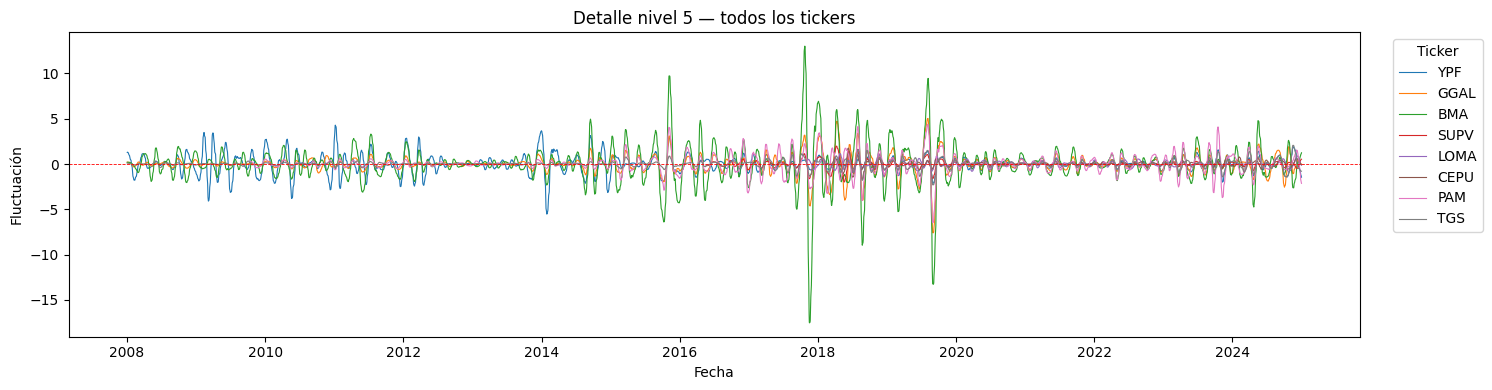

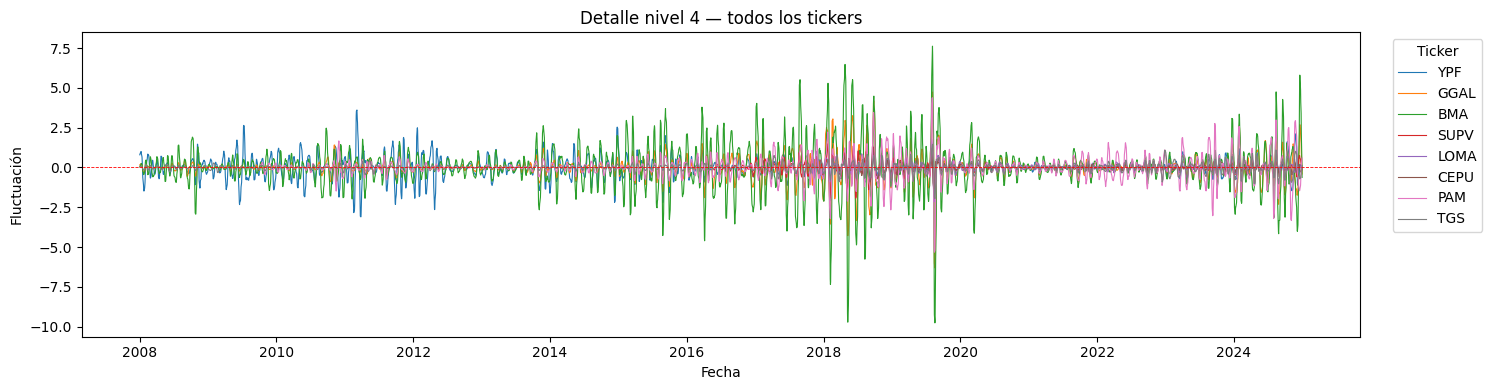

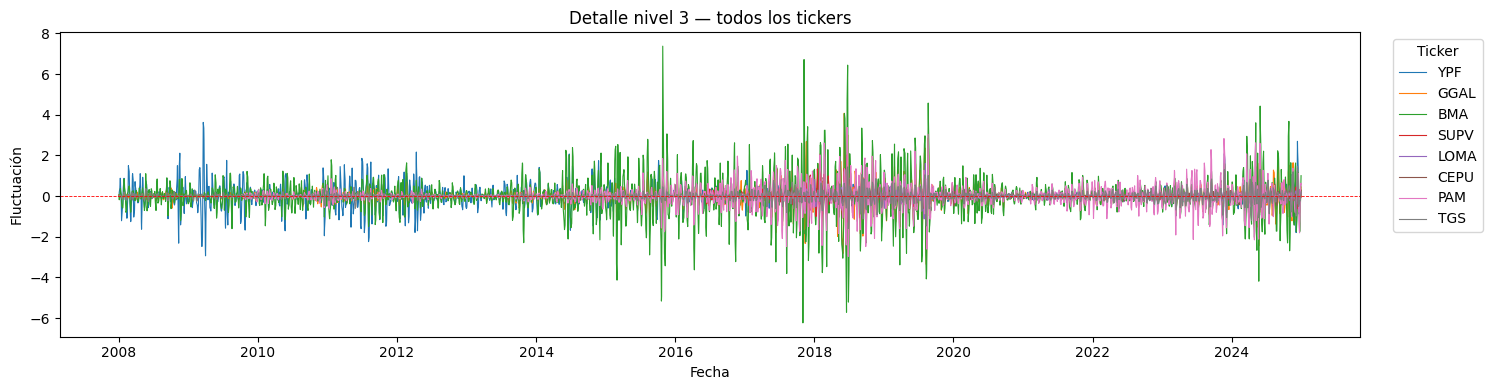

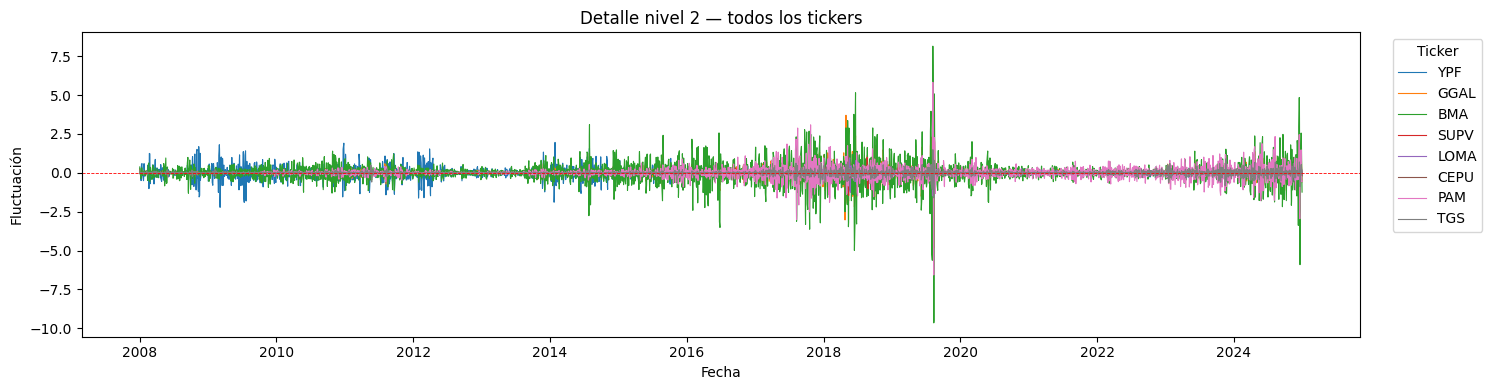

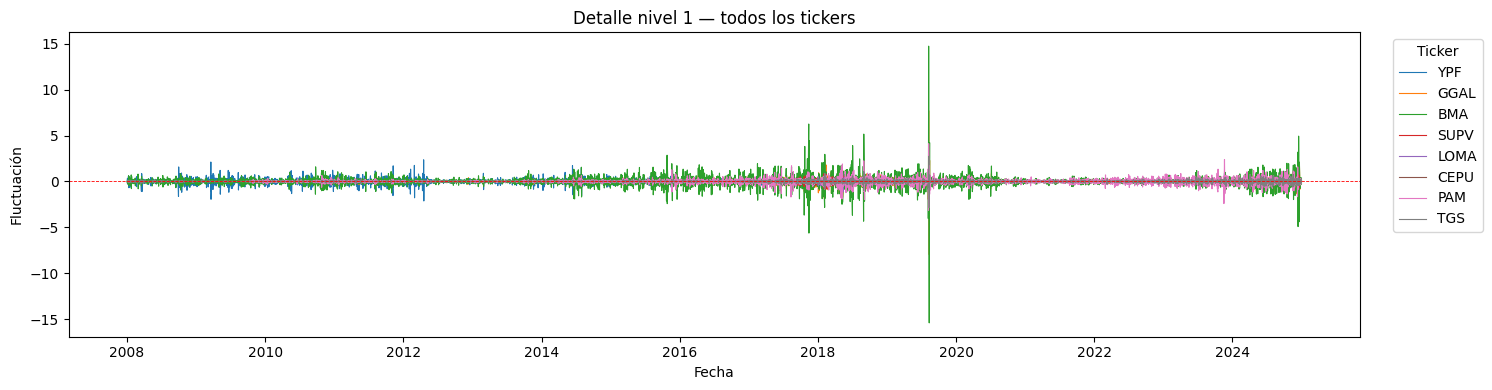

In [18]:
# Determinamos la cantidad máxima de niveles de detalle entre todos los tickers
max_n_detalles = max(len(resultados_wavelet[t]['detalles']) for t in tickers)

# Gráfico 1: Todas las aproximaciones juntas
plt.figure(figsize=(15, 5))
for ticker in tickers:
    fechas_ticker = resultados_wavelet[ticker]['fechas']
    aproximacion = resultados_wavelet[ticker]['aproximacion']
    plt.plot(fechas_ticker, aproximacion, label=ticker, linewidth=1.2, color=color_map[ticker])

plt.title('Aproximación (tendencia) — todos los tickers')
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.legend(title='Ticker', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Gráficos 2 en adelante: cada nivel de detalle, con todos los tickers 
for nivel_detalle in range(max_n_detalles, 0, -1):  
    plt.figure(figsize=(15, 4))

    for ticker in tickers:
        detalles = resultados_wavelet[ticker]['detalles']
        n_detalles_ticker = len(detalles)

        i = n_detalles_ticker - nivel_detalle
        if 0 <= i < n_detalles_ticker:
            fechas_ticker = resultados_wavelet[ticker]['fechas']
            plt.plot(fechas_ticker, detalles[i], label=ticker, linewidth=0.8, color=color_map[ticker])

    plt.axhline(y=0, color='red', linestyle='--', linewidth=0.6)
    plt.title(f'Detalle nivel {nivel_detalle} — todos los tickers')
    plt.xlabel('Fecha')
    plt.ylabel('Fluctuación')
    plt.legend(title='Ticker', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

## Estrategia de trading basada en Mallat

Viendo que la aproximación (cA) de Mallat logra capturar bastante bien la tendencia de las acciones, surge una pregunta natural: ¿podemos usar esa aproximación para identificar momentos de compra y venta?

La idea es simple:
- **Comprar** cuando el componente de tendencia muestra momentum alcista.
- **Vender** cuando ese momentum se pierde.

Para que la señal sea válida en la práctica, no podemos calcular la descomposición sobre toda la serie de una vez, ya que eso implicaría usar información futura. Por eso construimos una versión *rolling* de Mallat, que en cada punto solo utiliza los datos disponibles hasta ese momento.

Con esa serie suavizada, calculamos el momentum reciente y lo convertimos en una posición concreta (long/flat), simulando cómo hubiera performado la estrategia.

Calculemos primero nuestro Mallat rolling:

Empezamos recalculando la aproximación de Mallat desde cero cada día usando solo los datos hasta ese momento, y guardamos únicamente el último punto de cada reconstrucción.

In [ ]:
# Aproximación Mallat ROLLING (sin mirar futuro) 

# nivel = 4 -> Llegamos hasta el 4to nivel de la piramide de Mallat
# ventana_min = 50 -> cant de dias minima de info necesaria antes de calcular la aproximacion de Mallat

def mallat_filtrado_rolling(precios_vals, wavelet='db4', nivel=4, ventana_min=60):

    filtrado = []
    for i in range(len(precios_vals)):
        if i < ventana_min:
            filtrado.append(np.nan)
        else:
            segmento = precios_vals[:i+1]
            nivel_max_segmento = pywt.dwt_max_level(len(segmento), pywt.Wavelet(wavelet).dec_len)
            nivel_usado = min(nivel, nivel_max_segmento)
            
            coeffs = pywt.wavedec(segmento, wavelet, level=nivel_usado)
            coeffs_zero = [np.zeros_like(c) for c in coeffs]
            coeffs_zero[0] = coeffs[0]  # solo la aproximación
            reconstruido = pywt.waverec(coeffs_zero, wavelet)
            filtrado.append(reconstruido[-1])
    
    return np.array(filtrado)

Convertimos esa tendencia calculada en una estrategia de trading. Queremos identificar las señales de compra y venta basandonos en la tendencia/momentum de la acción sin tener información futura.

In [46]:
# ventana_momentum = 20 -> hacia donde va tendiendo la accion los ultimos 20 dias.
# umbral_momentum = 0.03 -> momentum: alcista (1) si > 3%; bajista (-1) si < 3%
# posicion = 1 si long/comprado (solo si es alcista)
# posicion = 0 si no

def calcular_estrategia_mallat(ticker, wavelet='db4', nivel=4, ventana_momentum=20, umbral_momentum=0.03, ventana_min=60):
    precios = data[ticker].dropna()
    fechas = precios.index
    precios_vals = precios.values
    
    filtrado = mallat_filtrado_rolling(precios_vals, wavelet=wavelet, nivel=nivel, ventana_min=ventana_min)
    
    mask = pd.notna(filtrado)
    fechas, precios_vals, filtrado = fechas[mask], precios_vals[mask], filtrado[mask]
    
    filtrado_s = pd.Series(filtrado, index=fechas)
    momentum = filtrado_s.pct_change(ventana_momentum)
    
    regimen = pd.Series(index=fechas, dtype=float)
    regimen[momentum > umbral_momentum] = 1
    regimen[momentum < -umbral_momentum] = -1
    regimen = regimen.ffill().fillna(0)
    
    posicion = (regimen == 1).astype(int)
    
    retornos_reales = pd.Series(precios_vals, index=fechas).pct_change()
    retorno_estrategia = posicion.shift(1) * retornos_reales  # señal de ayer, retorno de hoy
    
    return pd.DataFrame({
        'precio': precios_vals,
        'filtrado': filtrado,
        'regimen': regimen,
        'posicion': posicion,
        'retorno_bh': retornos_reales,
        'retorno_estrategia': retorno_estrategia
    }, index=fechas).dropna()


resultados_estrategia = {}

Ahora comparemos cada acción usando las dos estrategias:
- **Buy and Hold:** Estrategia tradicional
- **Mallat rolling:** Estrategia de compra y venta siguiendo señales identificadas por Mallat

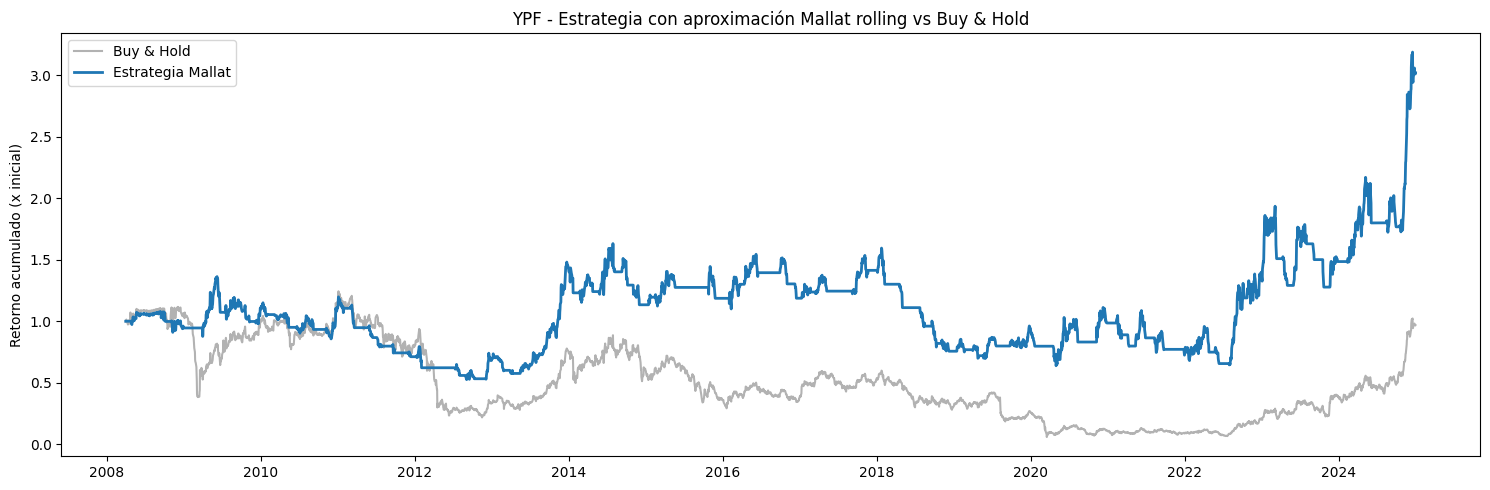

YPF - Retorno total Buy & Hold: 0.97x
YPF - Retorno total Estrategia: 3.02x



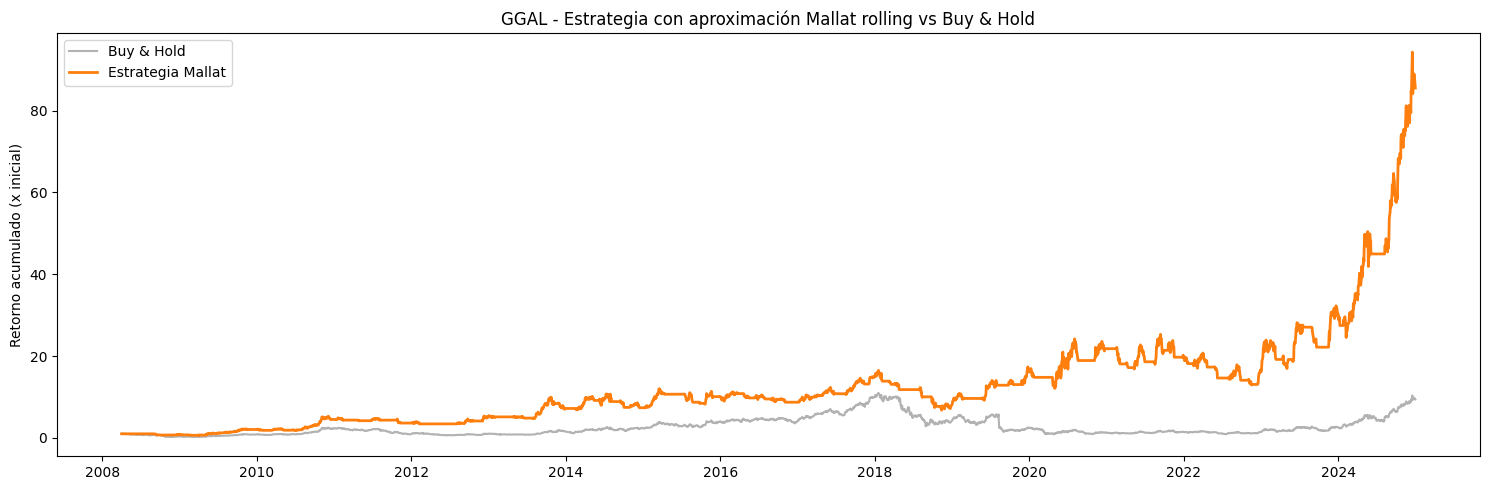

GGAL - Retorno total Buy & Hold: 9.41x
GGAL - Retorno total Estrategia: 85.52x



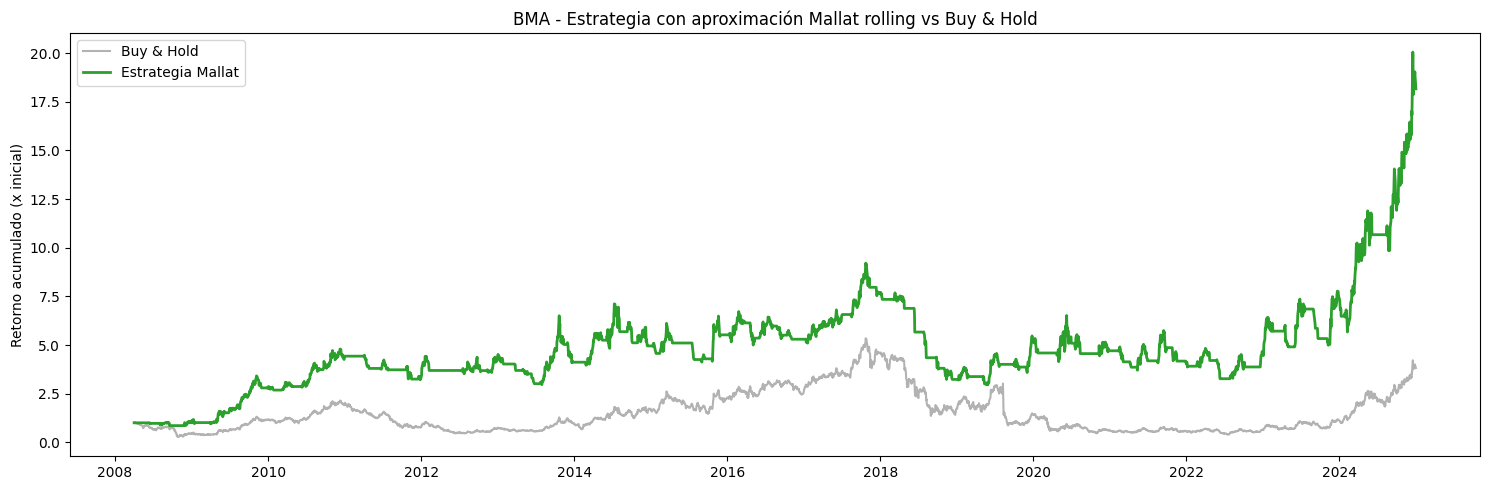

BMA - Retorno total Buy & Hold: 3.82x
BMA - Retorno total Estrategia: 18.17x



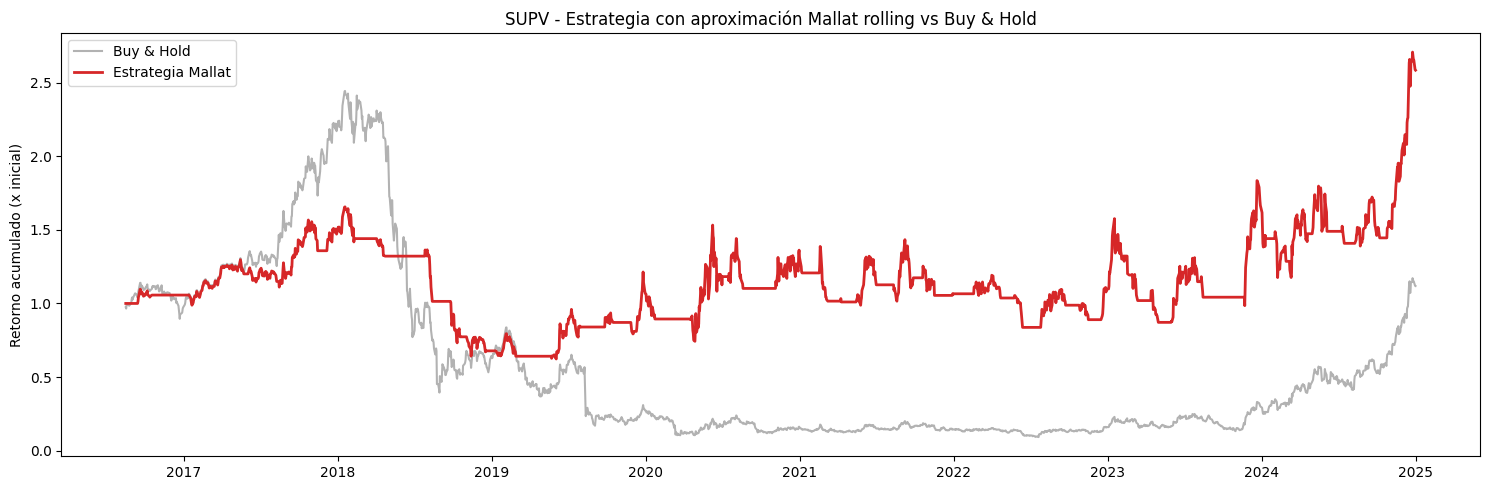

SUPV - Retorno total Buy & Hold: 1.12x
SUPV - Retorno total Estrategia: 2.58x



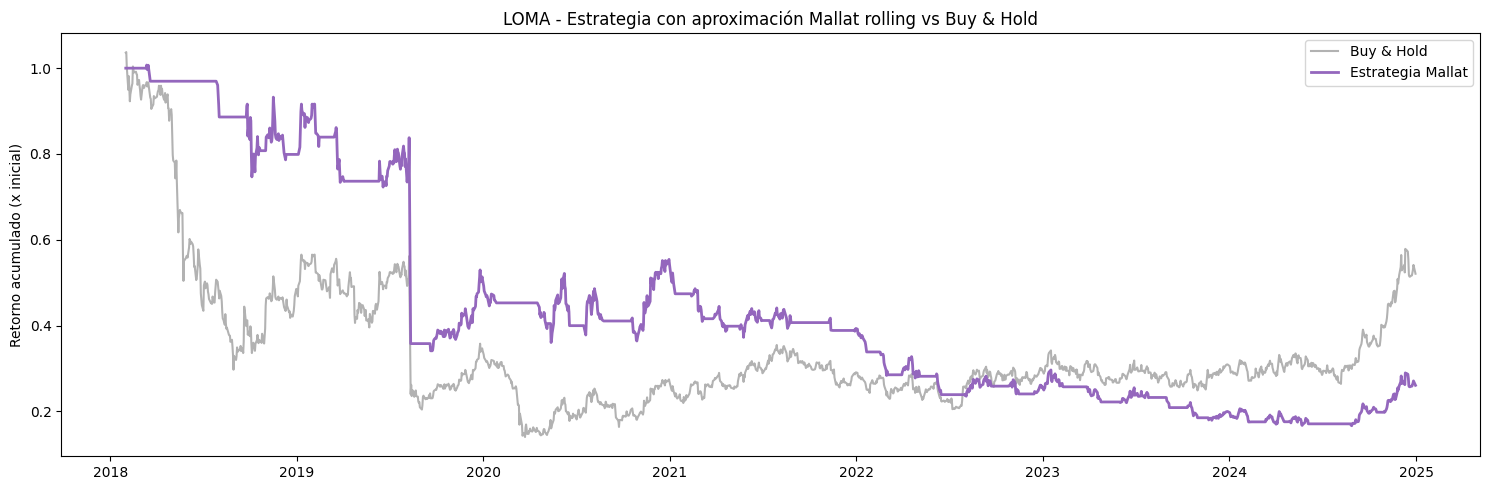

LOMA - Retorno total Buy & Hold: 0.52x
LOMA - Retorno total Estrategia: 0.26x



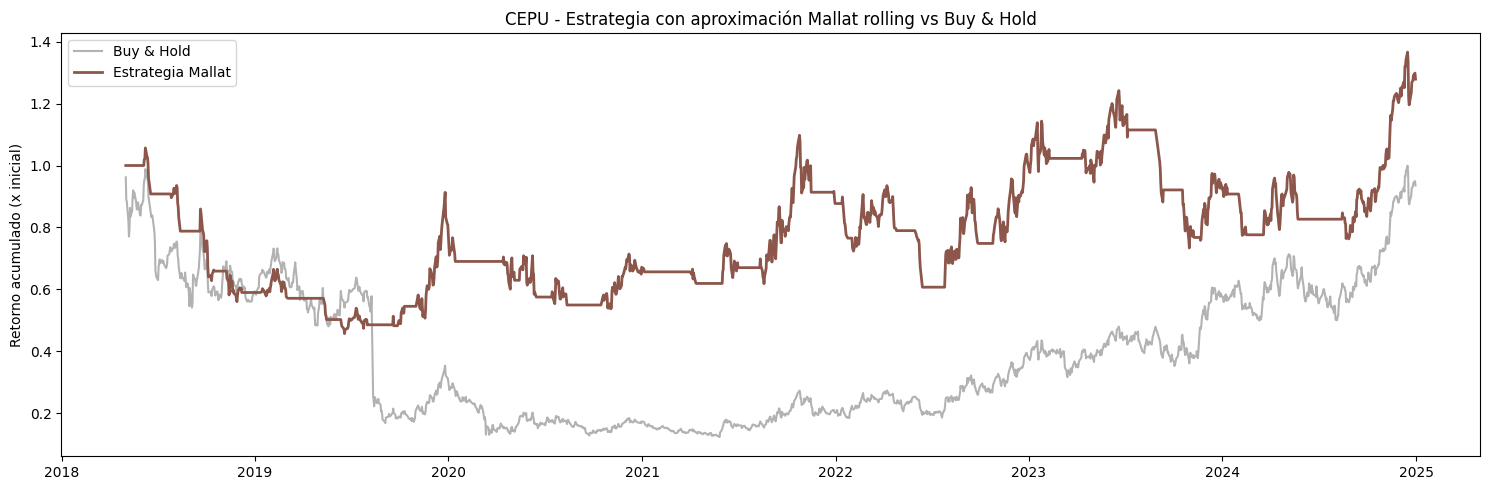

CEPU - Retorno total Buy & Hold: 0.94x
CEPU - Retorno total Estrategia: 1.28x



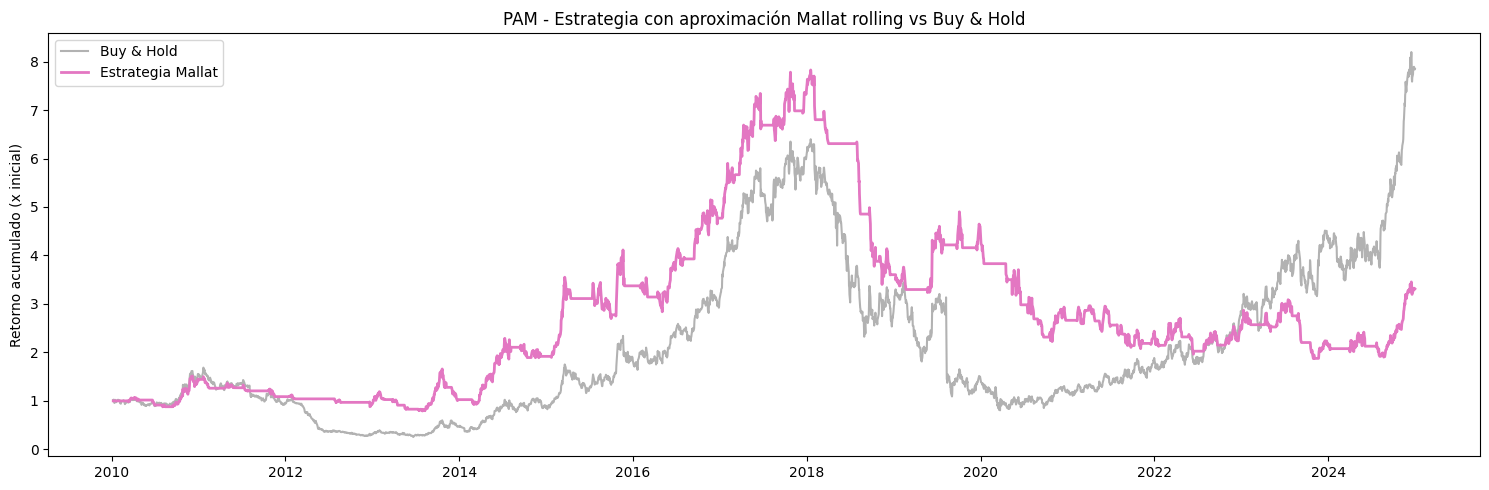

PAM - Retorno total Buy & Hold: 7.85x
PAM - Retorno total Estrategia: 3.31x



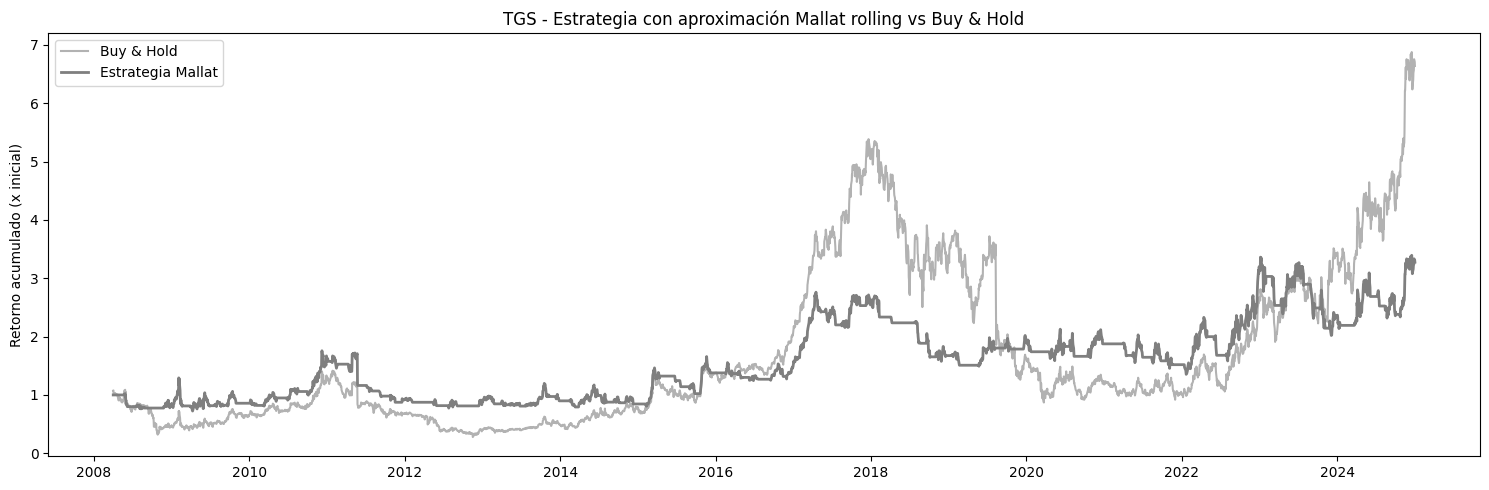

TGS - Retorno total Buy & Hold: 6.64x
TGS - Retorno total Estrategia: 3.28x



In [48]:
# Mallat Rolling vs B&H para todas nuestras acciones

for ticker in tickers:
    resultado = calcular_estrategia_mallat(ticker)
    resultados_estrategia[ticker] = resultado

    acumulado_bh = (1 + resultado['retorno_bh']).cumprod()
    acumulado_estrategia = (1 + resultado['retorno_estrategia']).cumprod()

    plt.figure(figsize=(15, 5))
    plt.plot(resultado.index, acumulado_bh, label='Buy & Hold', color='gray', alpha=0.6)
    plt.plot(resultado.index, acumulado_estrategia, label='Estrategia Mallat', color=color_map[ticker], linewidth=2)
    plt.title(f'{ticker} - Estrategia con aproximación Mallat rolling vs Buy & Hold')
    plt.ylabel('Retorno acumulado (x inicial)')
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"{ticker} - Retorno total Buy & Hold: {acumulado_bh.iloc[-1]:.2f}x")
    print(f"{ticker} - Retorno total Estrategia: {acumulado_estrategia.iloc[-1]:.2f}x")
    print()

Visualicemos los momentos de compra y venta identificados por nuestra estrategia.

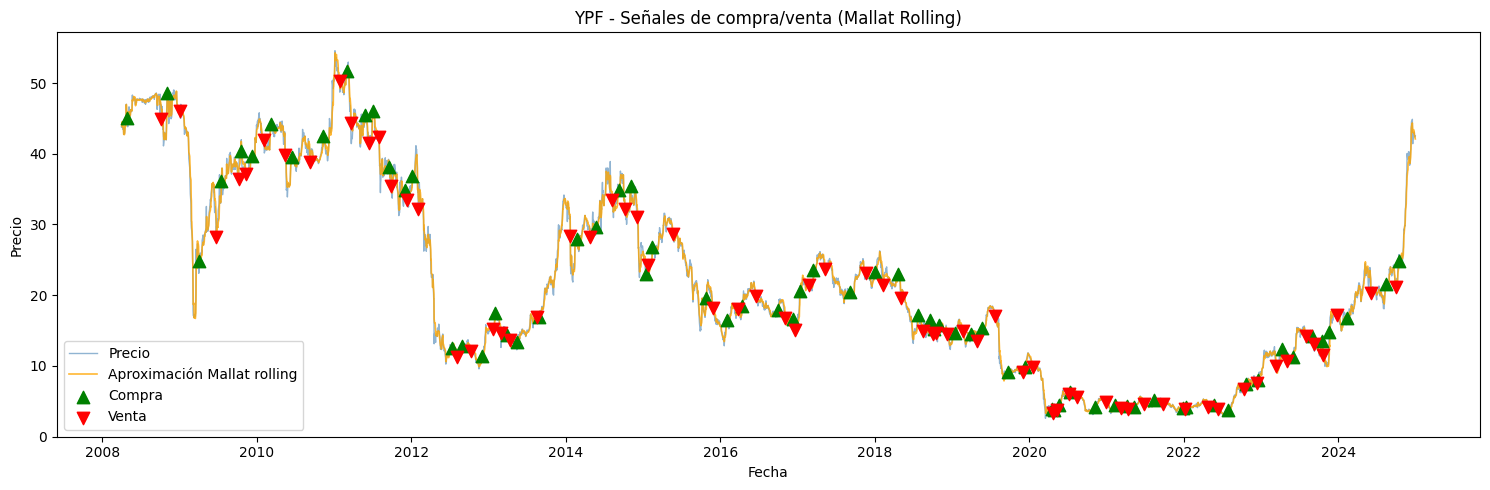

YPF: 70 señales de compra, 69 señales de venta


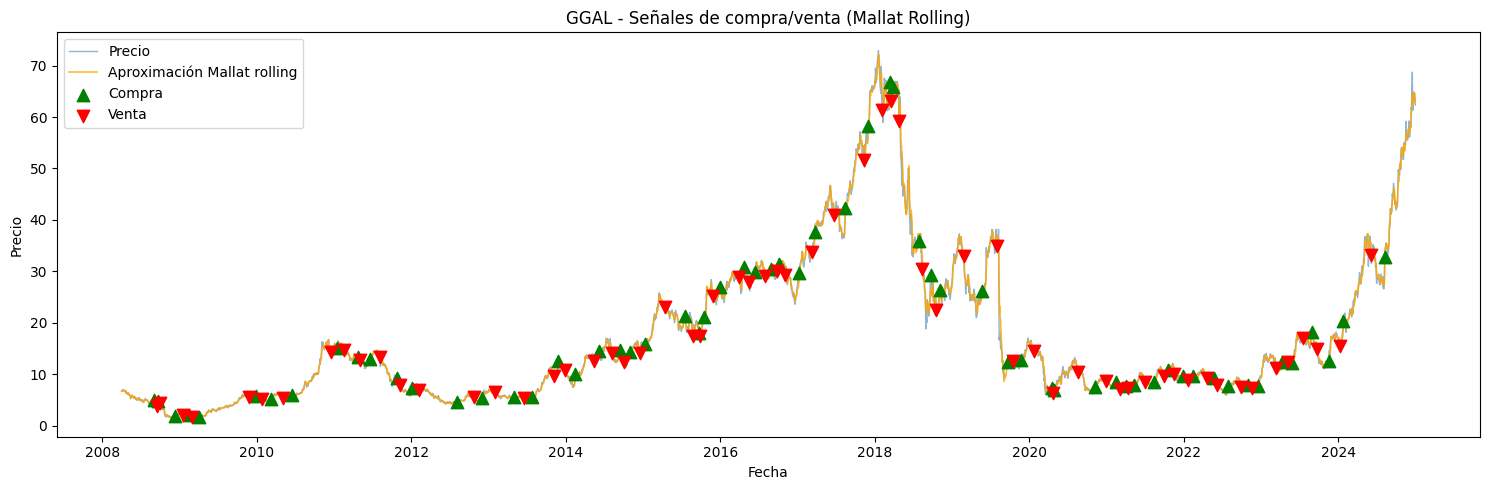

GGAL: 63 señales de compra, 62 señales de venta


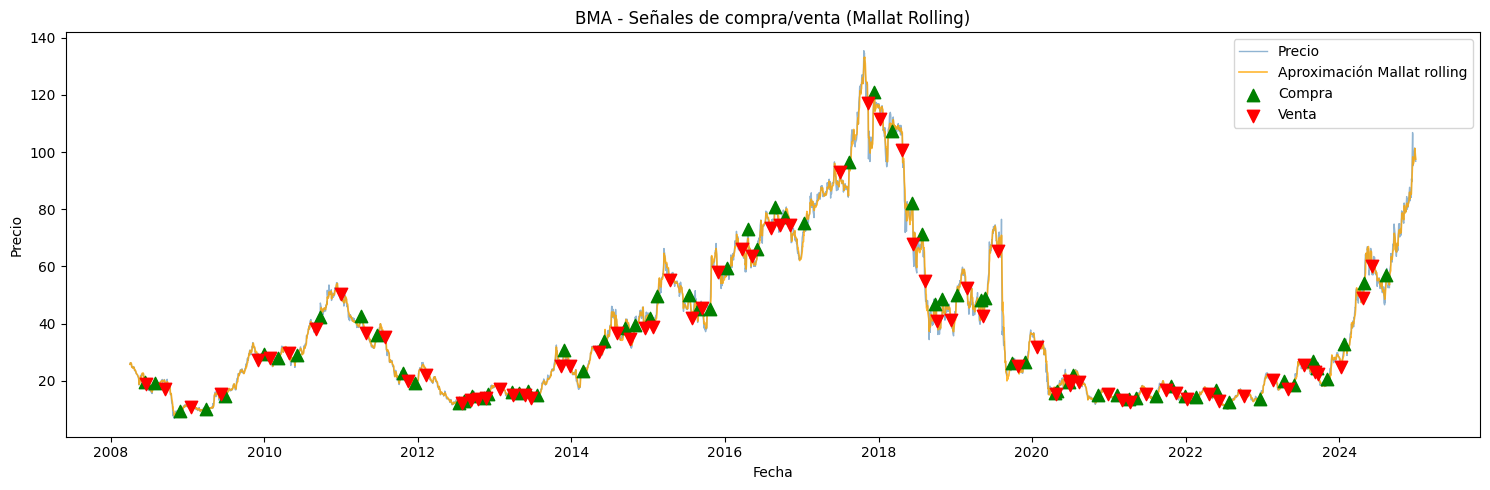

BMA: 73 señales de compra, 72 señales de venta


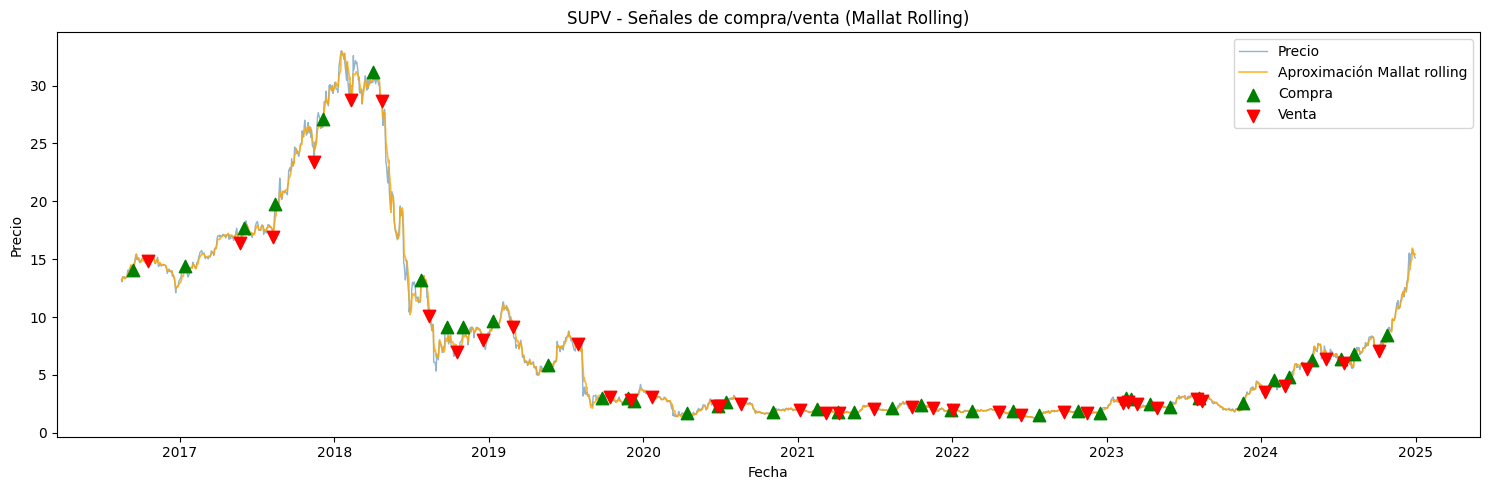

SUPV: 41 señales de compra, 40 señales de venta


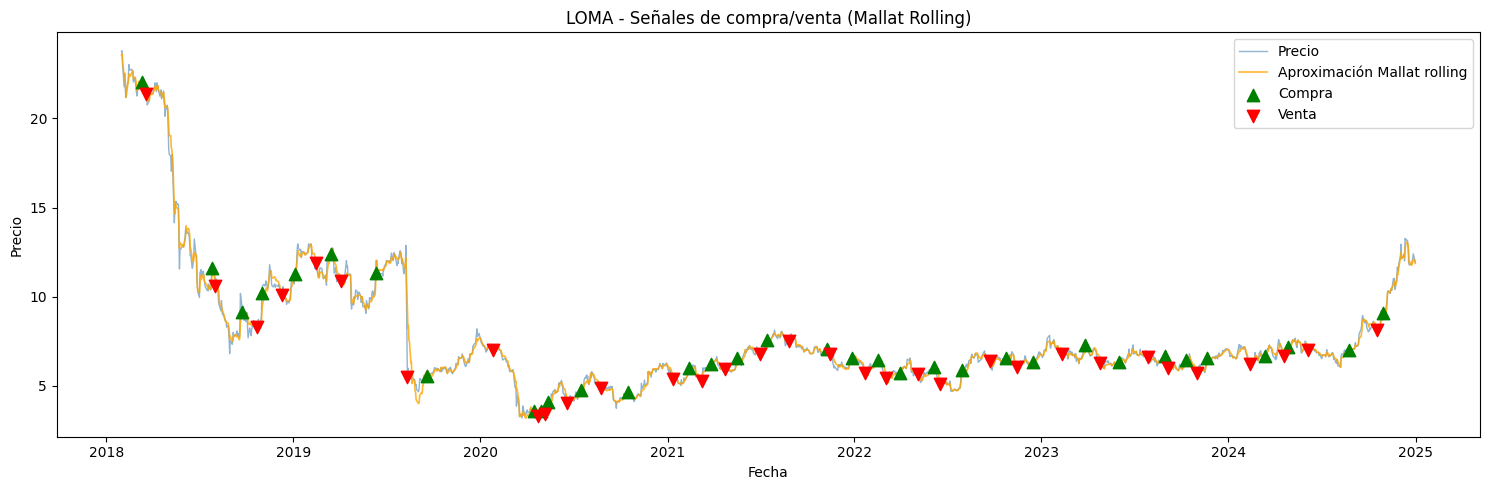

LOMA: 34 señales de compra, 33 señales de venta


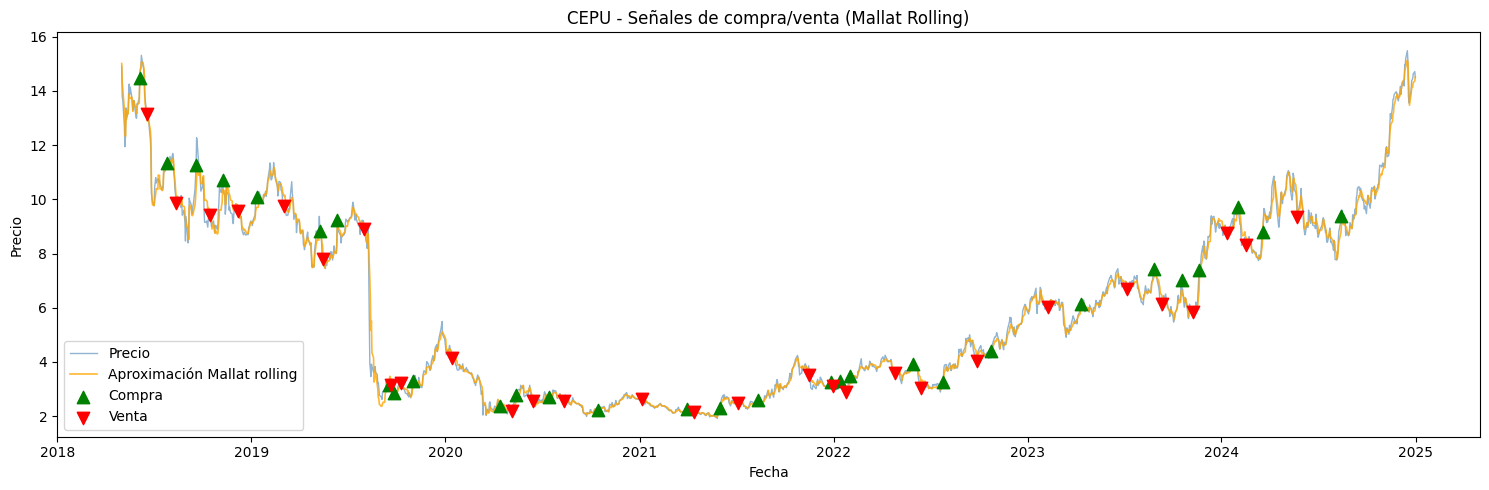

CEPU: 30 señales de compra, 29 señales de venta


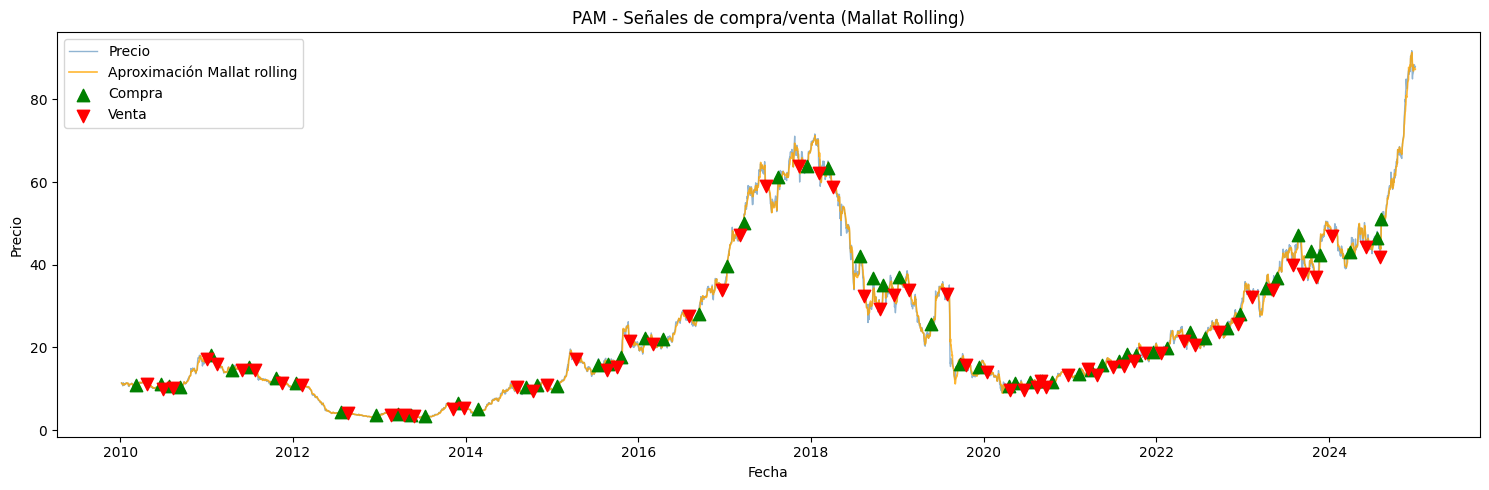

PAM: 63 señales de compra, 62 señales de venta


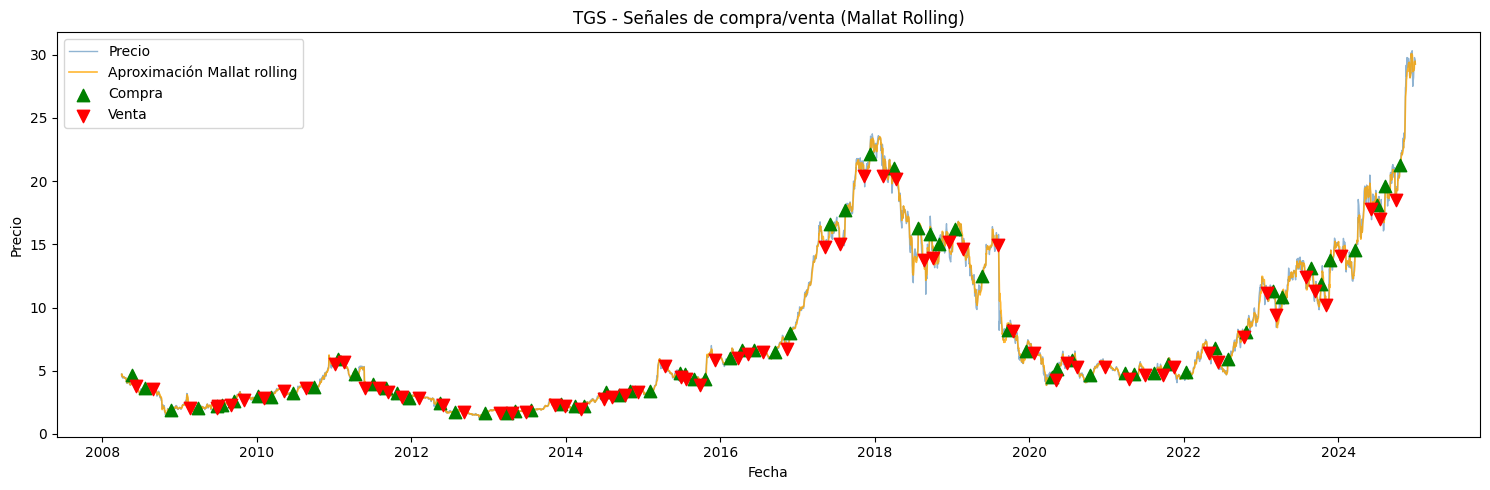

TGS: 71 señales de compra, 70 señales de venta


In [27]:
# Señales de compra/venta Mallat sobre el precio para TODOS los tickers

for ticker in tickers:
    resultado = resultados_estrategia[ticker]

    # Detectamos los cambios de posición: 
    # 0 -> 1 = señal de COMPRA (entra en régimen alcista)
    # 1 -> 0 = señal de VENTA (sale del régimen alcista)
    cambio_posicion = resultado['posicion'].diff()
    señales_compra = resultado.index[cambio_posicion == 1]
    señales_venta = resultado.index[cambio_posicion == -1]

    plt.figure(figsize=(15, 5))
    plt.plot(resultado.index, resultado['precio'], color='steelblue', alpha=0.6, label='Precio', linewidth=1)
    plt.plot(resultado.index, resultado['filtrado'], color='orange', alpha=0.8, label='Aproximación Mallat rolling', linewidth=1.2)

    plt.scatter(señales_compra, resultado.loc[señales_compra, 'precio'],
                marker='^', color='green', s=80, label='Compra', zorder=5)
    plt.scatter(señales_venta, resultado.loc[señales_venta, 'precio'],
                marker='v', color='red', s=80, label='Venta', zorder=5)

    plt.title(f'{ticker} - Señales de compra/venta (Mallat Rolling)')
    plt.xlabel('Fecha')
    plt.ylabel('Precio')
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f'{ticker}: {len(señales_compra)} señales de compra, {len(señales_venta)} señales de venta')

Resumamos todo lo que encontramos entre nuestras dos estrategias hasta ahora

In [62]:
# Resumen: Buy & Hold vs Estrategia Mallat para TODOS los tickers

resumen_estrategias = []

for ticker in tickers:
    resultado = resultados_estrategia[ticker]

    acumulado_bh = (1 + resultado['retorno_bh']).cumprod()
    acumulado_estrategia = (1 + resultado['retorno_estrategia']).cumprod()

    retorno_bh_x = acumulado_bh.iloc[-1]
    retorno_estrategia_x = acumulado_estrategia.iloc[-1]

    resumen_estrategias.append({
        'ticker': ticker,
        'retorno_buy_&_hold': f'{round(retorno_bh_x, 1)}x',
        'retorno_Mallat': f'{round(retorno_estrategia_x, 1)}x',
        'ganador': 'Buy & Hold' if retorno_bh_x > retorno_estrategia_x else 'Mallat',
        'diferencia': f'{round(retorno_estrategia_x - retorno_bh_x, 1)}x',
        'mejora_relativa': f'{round(retorno_estrategia_x / retorno_bh_x, 1)}x',
        'cantidad_operaciones': int(resultado['posicion'].diff().abs().sum())
    })

resumen_df = pd.DataFrame(resumen_estrategias).set_index('ticker')
resumen_df = resumen_df.sort_values('mejora_relativa', ascending=False)

resumen_df

,retorno_buy_&_hold,retorno_Mallat,ganador,diferencia,mejora_relativa,cantidad_operaciones
ticker,,,,,,
GGAL,9.4x,85.5x,Mallat,76.1x,9.1x,125
BMA,3.8x,18.2x,Mallat,14.3x,4.8x,145
YPF,1.0x,3.0x,Mallat,2.1x,3.1x,139
SUPV,1.1x,2.6x,Mallat,1.5x,2.3x,81
CEPU,0.9x,1.3x,Mallat,0.3x,1.4x,59
LOMA,0.5x,0.3x,Buy & Hold,-0.3x,0.5x,67
TGS,6.6x,3.3x,Buy & Hold,-3.4x,0.5x,141
PAM,7.9x,3.3x,Buy & Hold,-4.5x,0.4x,125


### Ejemplos practicos

#### Ejemplo 1: Ganancia
Supongamos que tenemos 2 personas con USD 1000 c/u:
- **Persona A** compra GGAL y utiliza la estrategia **Buy & Hold**.
- **Persona B** compra GGAL y utiliza la estrategia de **Señales por Mallat**.

In [23]:
capital_inicial_persona_a = 1000
capital_inicial_persona_b = 1000

ticker_ejemplo = 'GGAL'
resultado = resultados_estrategia[ticker_ejemplo]

acumulado_bh = (1 + resultado['retorno_bh']).cumprod()
acumulado_estrategia = (1 + resultado['retorno_estrategia']).cumprod()

retorno_bh_x = acumulado_bh.iloc[-1]
retorno_estrategia_x = acumulado_estrategia.iloc[-1]

capital_final_persona_a = capital_inicial_persona_a * retorno_bh_x
capital_final_persona_b = capital_inicial_persona_b * retorno_estrategia_x

print(f'Capital inicial de cada persona: USD {capital_inicial_persona_a:,.0f}')
print()
print(f'Persona A (Buy & Hold)      x{retorno_bh_x:.1f}   ->  USD {capital_final_persona_a:,.0f}')
print(f'Persona B (Estrategia Mallat) x{retorno_estrategia_x:.1f}  ->  USD {capital_final_persona_b:,.0f}')
print()
print(f'Diferencia entre ambas: USD {capital_final_persona_b - capital_final_persona_a:,.0f}')

Capital inicial de cada persona: USD 1,000

Persona A (Buy & Hold)      x9.4   ->  USD 9,414
Persona B (Estrategia Mallat) x85.5  ->  USD 85,524

Diferencia entre ambas: USD 76,110


Vemos que el retorno obtenido por la Persona B sobrepasa por mucho el retorno de la Persona A.
Es decir que muchas veces la estrategia Mallat es superior que la tradicional (Buy & Hold).

---

#### Ejemplo 2: Pérdida

In [24]:
capital_inicial_persona_a = 1000
capital_inicial_persona_b = 1000

ticker_ejemplo = 'LOMA'
resultado = resultados_estrategia[ticker_ejemplo]

acumulado_bh = (1 + resultado['retorno_bh']).cumprod()
acumulado_estrategia = (1 + resultado['retorno_estrategia']).cumprod()

retorno_bh_x = acumulado_bh.iloc[-1]
retorno_estrategia_x = acumulado_estrategia.iloc[-1]

capital_final_persona_a = capital_inicial_persona_a * retorno_bh_x
capital_final_persona_b = capital_inicial_persona_b * retorno_estrategia_x

print(f'Capital inicial de cada persona: USD {capital_inicial_persona_a:,.0f}')
print()
print(f'Persona A (Buy & Hold)      x{retorno_bh_x:.1f}   ->  USD {capital_final_persona_a:,.0f}')
print(f'Persona B (Estrategia Mallat) x{retorno_estrategia_x:.1f}  ->  USD {capital_final_persona_b:,.0f}')
print()
print(f'Diferencia entre ambas: USD {capital_final_persona_b - capital_final_persona_a:,.0f}')

Capital inicial de cada persona: USD 1,000

Persona A (Buy & Hold)      x0.5   ->  USD 521
Persona B (Estrategia Mallat) x0.3  ->  USD 261

Diferencia entre ambas: USD -260


Vemos que en este caso las dos estrategias pierden, pero al utilizar Mallat perdemos el doble.

Esto quiere decir que no siempre la estrategia Mallat Rolling es superior.

## Veamos que onda Pair Trading 

In [39]:
# ============================================
# Estrategia de "pair trading" usando la relación GGAL/BMA + señal Mallat
# ============================================

ticker_a = 'GGAL'
ticker_b = 'YPF'

precios_a = data[ticker_a].dropna()
precios_b = data[ticker_b].dropna()

# Alineamos ambas series por fecha (por si tienen distinta cantidad de datos)
fechas_comunes = precios_a.index.intersection(precios_b.index)
precios_a = precios_a[fechas_comunes]
precios_b = precios_b[fechas_comunes]

# La "relación" es la nueva serie a analizar
relacion = precios_a / precios_b

In [40]:
relacion_vals = relacion.values
fechas_relacion = relacion.index

filtrado = mallat_filtrado_rolling(relacion_vals, wavelet='db4', nivel=4, ventana_min=60)

mask = ~np.isnan(filtrado)
fechas_relacion, relacion_vals, filtrado = fechas_relacion[mask], relacion_vals[mask], filtrado[mask]

filtrado_s = pd.Series(filtrado, index=fechas_relacion)
momentum = filtrado_s.pct_change(20)

regimen = pd.Series(index=fechas_relacion, dtype=float)
regimen[momentum > 0.03] = 1    # relación en tendencia alcista -> A se aprecia relativo a B
regimen[momentum < -0.03] = -1  # relación en tendencia bajista -> B se aprecia relativo a A
regimen = regimen.ffill().fillna(0)

In [41]:
# Posición en cada pata del par, según el régimen de la relación
posicion_a = (regimen == 1).astype(int)   # long en A cuando la relación sube
posicion_b = (regimen == -1).astype(int)  # long en B cuando la relación baja

# Retornos individuales de cada acción, alineados a las mismas fechas
retornos_a = precios_a.pct_change().reindex(fechas_relacion)
retornos_b = precios_b.pct_change().reindex(fechas_relacion)

# Retorno de la estrategia par: long en A cuando corresponde, long en B cuando corresponde
# (shift(1): la señal de ayer determina la posición de hoy, igual que en tu estrategia individual)
retorno_par = posicion_a.shift(1) * retornos_a + posicion_b.shift(1) * retornos_b

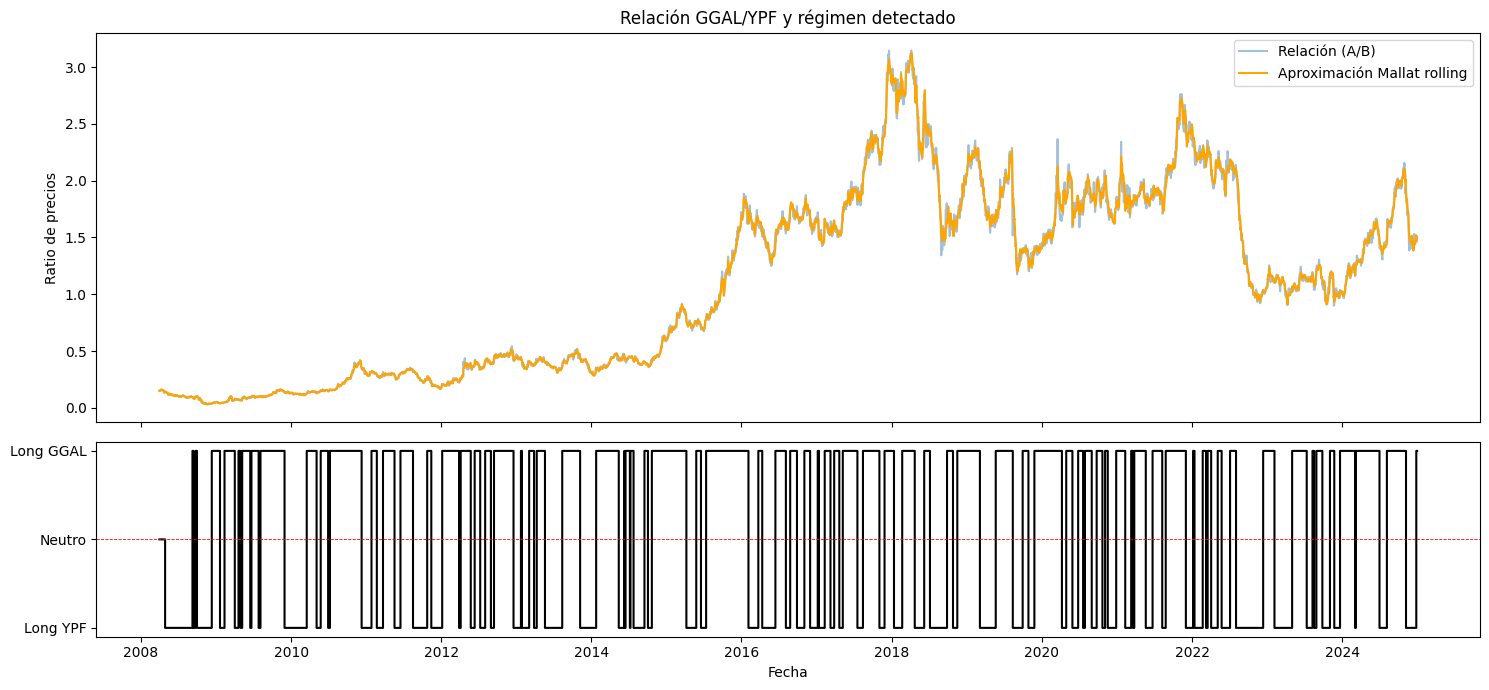

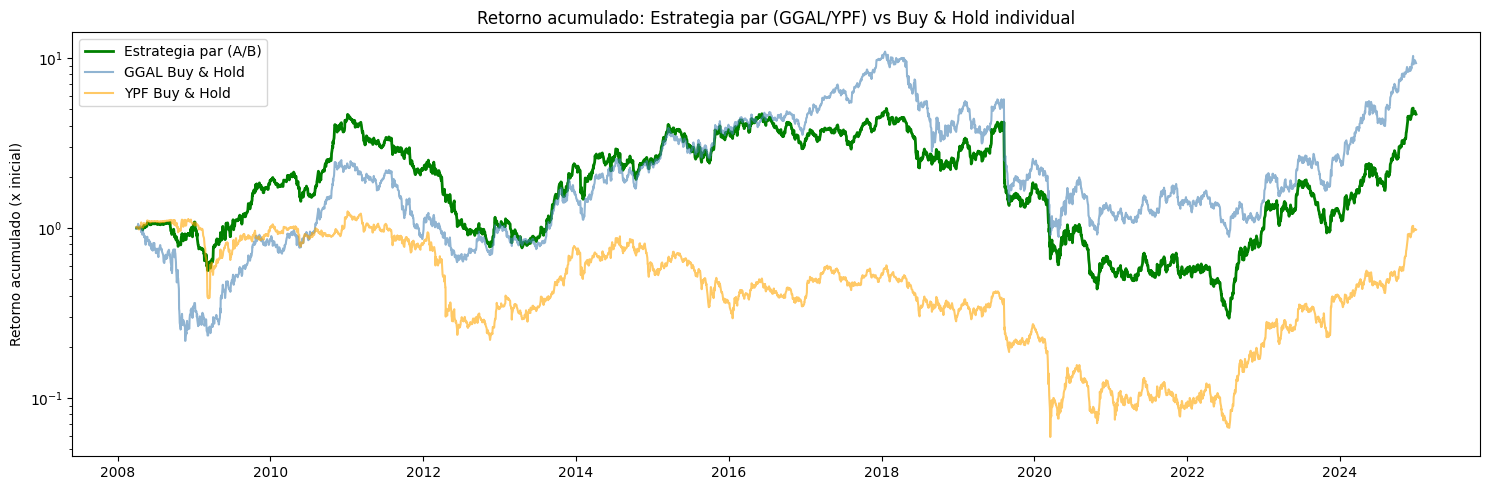

Retorno Estrategia Par: 4.67x
Retorno GGAL Buy & Hold: 9.32x
Retorno YPF Buy & Hold: 0.97x
Sharpe estrategia par: 0.45
Max drawdown estrategia par: -94.2%


In [42]:
# ============================================
# Visualización de resultados: estrategia de pair trading (relación A/B)
# ============================================

# Retorno acumulado de la estrategia par
acumulado_par = (1 + retorno_par).cumprod()

# Retorno acumulado de cada acción individual (buy & hold), para comparar
acumulado_a_bh = (1 + retornos_a).cumprod()
acumulado_b_bh = (1 + retornos_b).cumprod()

# ---- Gráfico 1: relación (precio A/B) + señal de régimen ----
fig, (ax_rel, ax_regimen) = plt.subplots(
    2, 1, figsize=(15, 7), sharex=True,
    gridspec_kw={'height_ratios': [2, 1]}
)

ax_rel.plot(fechas_relacion, relacion_vals, color='steelblue', alpha=0.5, label='Relación (A/B)')
ax_rel.plot(fechas_relacion, filtrado, color='orange', linewidth=1.5, label='Aproximación Mallat rolling')
ax_rel.set_title(f'Relación {ticker_a}/{ticker_b} y régimen detectado')
ax_rel.set_ylabel('Ratio de precios')
ax_rel.legend()

ax_regimen.step(fechas_relacion, regimen, where='post', color='black')
ax_regimen.axhline(y=0, color='red', linestyle='--', linewidth=0.6)
ax_regimen.set_yticks([-1, 0, 1])
ax_regimen.set_yticklabels([f'Long {ticker_b}', 'Neutro', f'Long {ticker_a}'])
ax_regimen.set_xlabel('Fecha')

plt.tight_layout()
plt.show()

# ---- Gráfico 2: retorno acumulado - estrategia par vs cada acción individual ----
plt.figure(figsize=(15, 5))
plt.plot(fechas_relacion, acumulado_par, color='green', linewidth=2, label='Estrategia par (A/B)')
plt.plot(fechas_relacion, acumulado_a_bh, color='steelblue', alpha=0.6, label=f'{ticker_a} Buy & Hold')
plt.plot(fechas_relacion, acumulado_b_bh, color='orange', alpha=0.6, label=f'{ticker_b} Buy & Hold')
plt.title(f'Retorno acumulado: Estrategia par ({ticker_a}/{ticker_b}) vs Buy & Hold individual')
plt.ylabel('Retorno acumulado (x inicial)')
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.show()

# ---- Métricas resumen ----
print(f'Retorno Estrategia Par: {acumulado_par.iloc[-1]:.2f}x')
print(f'Retorno {ticker_a} Buy & Hold: {acumulado_a_bh.iloc[-1]:.2f}x')
print(f'Retorno {ticker_b} Buy & Hold: {acumulado_b_bh.iloc[-1]:.2f}x')

sharpe_par = retorno_par.mean() / retorno_par.std() * np.sqrt(252)
print(f'Sharpe estrategia par: {sharpe_par:.2f}')

def max_drawdown(acumulado):
    pico = acumulado.cummax()
    return ((acumulado - pico) / pico).min()

print(f'Max drawdown estrategia par: {max_drawdown(acumulado_par):.1%}')